# 1. Fixed income and yield curve construction

In this project we will implement

- building yield curve from par yields for US and japan data with 4 different methods and comparison
- creating a rolling synthetic portfolio of bonds
- analysis and pricing of the bonds in portfolio
- risk and sensitivity measures of bonds 


## 1) Bonds, Coupons, Treasuries, and Par Yields

### 1.1 Fixed-coupon bond cashflows
A standard coupon bond is defined by:
- notional $N$ (principal. the money that you get back)
- annual coupon rate $c$ (the interest rate of the bond)
- maturity $T$ (the time that bond ends and you get back principal and interest)
- coupon frequency $f$ (the amount of payments per year)

Coupon payment each period is $\dfrac{c}{f}N$.

Payment times are
$t_i=\dfrac{i}{f}$ for $i=1,2,\dots,n$ &nbsp;&nbsp;&nbsp;&nbsp; where $n=fT$

Cashflows for each period $i$ is
$CF_i=\dfrac{c}{f}N$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $i=1,\dots,n-1$ 

final cash flow: $CF_n=\dfrac{c}{f}N+N$

---

### 1.2 Price from discount factors
For calculating price of a bond we need to discount all the cash flows to today value to compute the present value of the bond. for that we need to have a discount rate for every $t$ that a cash flow accurs. this comes from a continous function of time which is discount curve $D(t)$, the price is
$P=\sum_{i=1}^{n} CF_i\,D(t_i)$

---

### 1.3 Year fraction from dates
Given dates $d_0$ and $d_1$, a day-count year fraction is
$\tau(d_0,d_1)=\dfrac{\text{days}(d_0,d_1)}{365}$

---

### 1.4 Tenor mapping
Tenor labels map to maturities:
- $k$ M → $T=k/12$
- $k$ Y → $T=k$

Collect maturities into a numeric vector:
$\mathbf{T}=(T_1,T_2,\dots,T_m)$  
Observed market par yields:
$\mathbf{y}=(y_1,y_2,\dots,y_m)$ with $y_j=y(T_j)$

---

### 1.5 What “Treasury par yield” means
A par yield at maturity $T$ is the coupon rate $c(T)$ that makes a standard coupon bond price equal to par value:
$P(T,c(T))=N$
If we normalize $N=1$, then par means $P=1$.

For discounting, we use these yields but the problem is we have some of the standard maturities which may not be the same as other bonds. so that's why we have to make this yield curve from the treasury maturities to be able to discount any time to present.

you can download the data used in this notebook here [(treasury par yields from 1990 to 2026)][]

[(treasury par yields from 1990 to 2026)]: https://home.treasury.gov/resource-center/data-chart-center/interest-rates/daily-treasury-rate-archives

---

## Imports and plotting style and loading data


In [1]:
import math
import warnings
import copy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cycler import cycler

warnings.filterwarnings("ignore")


colors = ["#069AF3","#FE420F", "#00008B", "#008080", "#7BC8F6","#800080","#0072B2","#008000","#CC79A7", "#DC143C", "#04D8B2"]
plt.rcParams["axes.prop_cycle"] = cycler(color=colors)
plt.rcParams.update({
    "figure.figsize": (6, 3),
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 7,
})


df = pd.read_csv(r"..\data\par-yield-curve-rates-1990-2026.csv")

col_map = {"date": "Date","1 mo": "1M","2 mo": "2M","3 mo": "3M","4 mo": "4M","6 mo": "6M","1 yr": "1Y","2 yr": "2Y","3 yr": "3Y","5 yr": "5Y","7 yr": "7Y","10 yr": "10Y","20 yr": "20Y","30 yr": "30Y"}

df = df.rename(columns={k.lower(): v for k, v in col_map.items()})
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"], ).set_index("Date").sort_index()

df

,1M,2M,3M,4M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
Date,,,,,,,,,,,,,
1990-01-02,NaN,NaN,7.83,NaN,7.89,7.81,7.87,7.90,7.87,7.98,7.94,NaN,8.00
1990-01-03,NaN,NaN,7.89,NaN,7.94,7.85,7.94,7.96,7.92,8.04,7.99,NaN,8.04
1990-01-04,NaN,NaN,7.84,NaN,7.90,7.82,7.92,7.93,7.91,8.02,7.98,NaN,8.04
1990-01-05,NaN,NaN,7.79,NaN,7.85,7.79,7.90,7.94,7.92,8.03,7.99,NaN,8.06
1990-01-08,NaN,NaN,7.79,NaN,7.88,7.81,7.90,7.95,7.92,8.05,8.02,NaN,8.09
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-22,3.79,3.72,3.71,3.67,3.61,3.53,3.61,3.68,3.85,4.05,4.26,4.79,4.84
2026-01-23,3.78,3.72,3.70,3.67,3.61,3.53,3.60,3.67,3.84,4.03,4.24,4.78,4.82
2026-01-26,3.77,3.70,3.67,3.67,3.62,3.52,3.56,3.66,3.82,4.02,4.22,4.75,4.80



Data shape: (9024, 13)
Date range: 1990-01-02 to 2026-01-28


,count,mean,std,min,25%,50%,75%,max
1M,6124.0,1.669061,1.834318,0.00,0.08,0.98,2.700,6.02
2M,1819.0,2.731045,2.092637,0.00,0.14,2.43,4.635,5.61
3M,9020.0,2.793844,2.279473,0.00,0.23,2.74,5.010,8.26
4M,817.0,4.826524,0.600693,3.58,4.35,4.77,5.440,5.64
6M,9023.0,2.908257,2.296244,0.02,0.41,3.00,5.100,8.49
1Y,9023.0,3.004545,2.274365,0.04,0.56,3.12,5.025,8.64
2Y,9023.0,3.243374,2.267325,0.09,0.94,3.35,4.990,9.05
3Y,9023.0,3.422187,2.212582,0.10,1.37,3.55,5.050,9.11
5Y,9023.0,3.761102,2.107014,0.19,1.81,3.73,5.380,9.10
7Y,9023.0,4.037397,2.028457,0.36,2.22,3.93,5.600,9.12


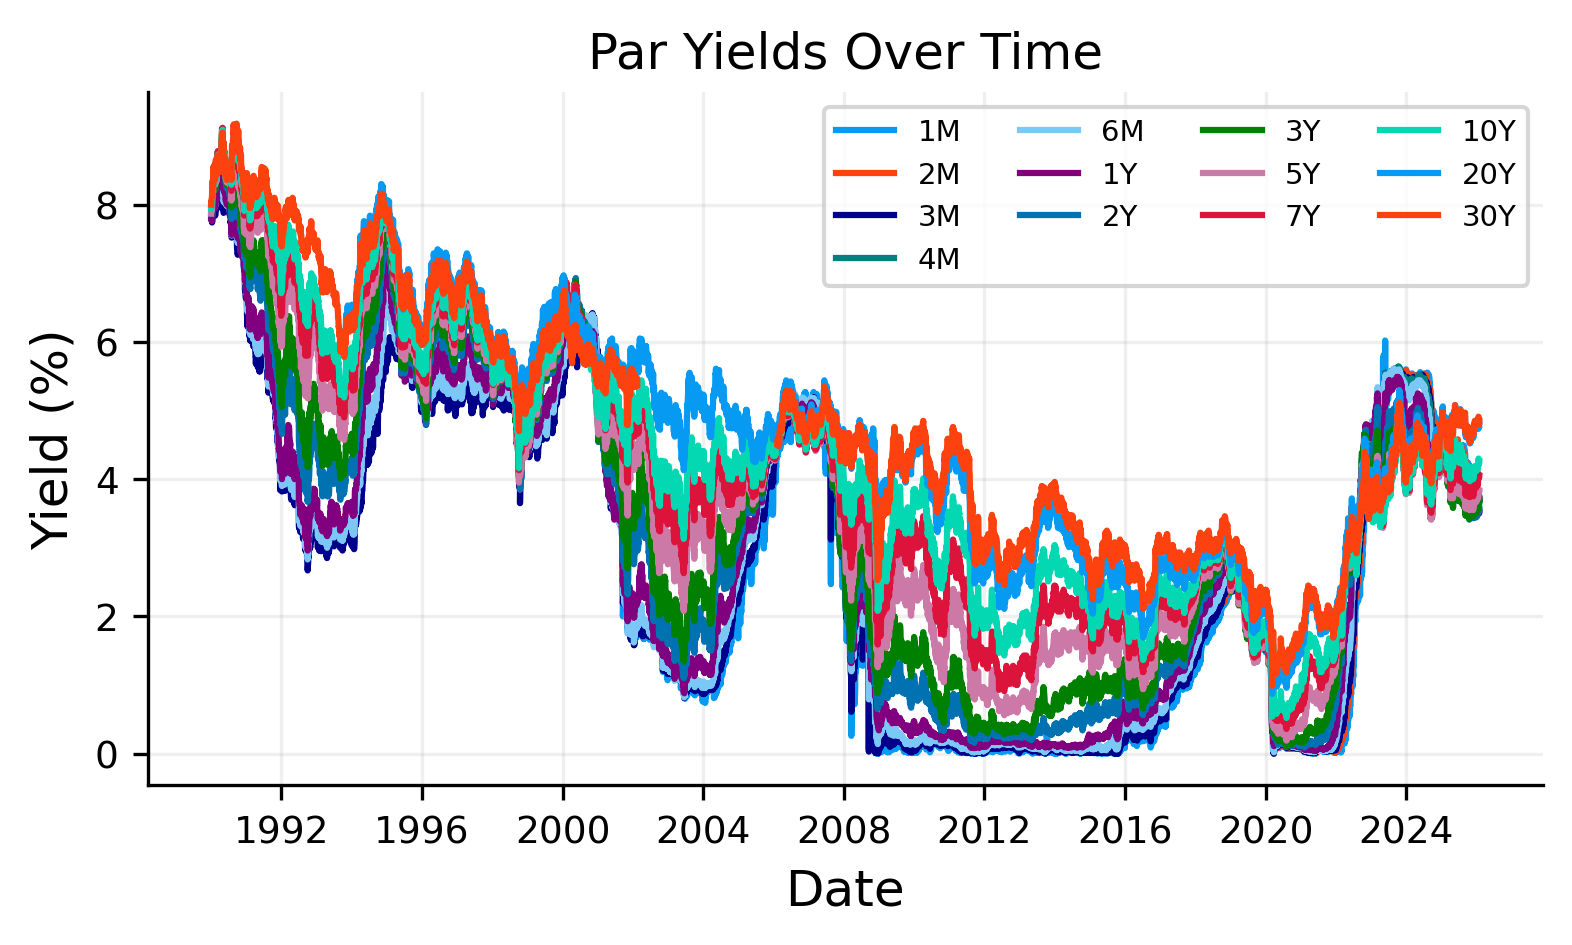

First available date per tenor:


,tenor,first_valid_date
2,3M,1990-01-02
4,6M,1990-01-02
5,1Y,1990-01-02
6,2Y,1990-01-02
7,3Y,1990-01-02
8,5Y,1990-01-02
9,7Y,1990-01-02
10,10Y,1990-01-02
12,30Y,1990-01-02
11,20Y,1993-10-01


In [2]:
tenor_cols = ["1M","2M","3M","4M","6M","1Y","2Y","3Y","5Y","7Y","10Y","20Y","30Y"]
for c in tenor_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

first_valid = df[tenor_cols].apply(lambda s: s.first_valid_index())
availability = pd.DataFrame({
    "tenor": tenor_cols,
    "first_valid_date": [first_valid[t] for t in tenor_cols],
})
availability["first_valid_date"] = pd.to_datetime(availability["first_valid_date"])
availability = availability.sort_values("first_valid_date")



print("\nData shape:", df.shape)
print("Date range:", df.index.min().date(), "to", df.index.max().date())
display(df[tenor_cols].describe().T)


plt.figure()
for c in df.columns:
    plt.plot(df.index, df[c], label=c)
plt.title("Par Yields Over Time")
plt.ylabel("Yield (%)")
plt.xlabel("Date")
plt.legend(ncol= 4)
plt.show()


print("First available date per tenor:")
display(availability)


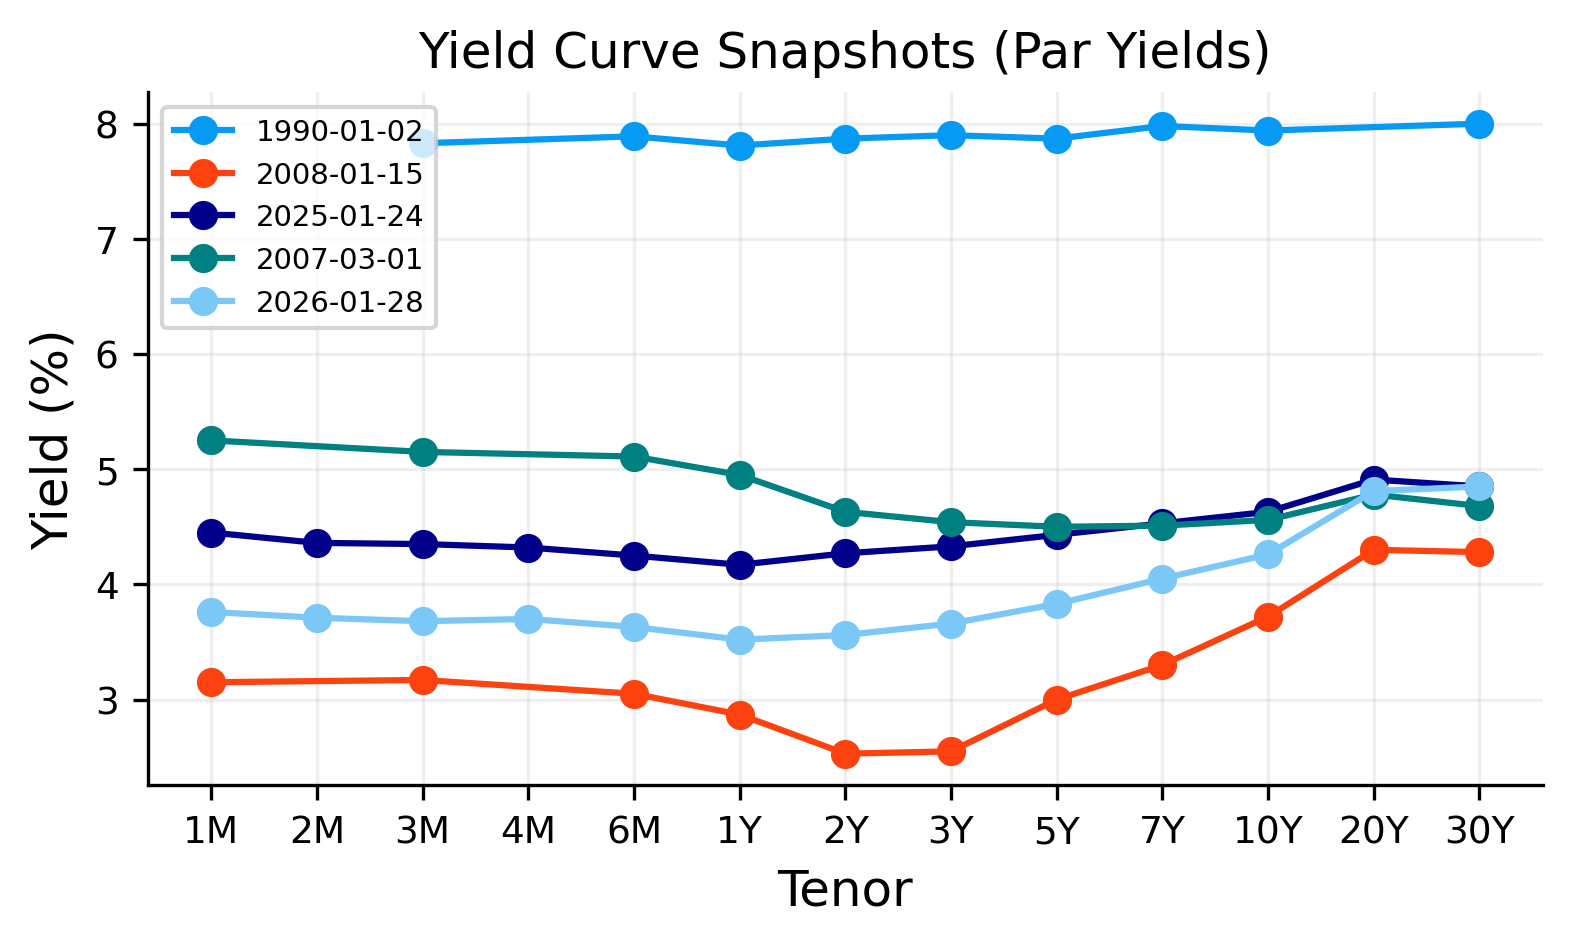

In [3]:
sample_dates = [
    df.index[0],
    df.index[len(df)//2],
    df.index[-252],
    df.index[df.index <= pd.Timestamp("2007-03-01")][-1],
    df.index[-1]
]

x = np.arange(len(tenor_cols))  

plt.figure()
for d in sample_dates:
    y = df.loc[d, tenor_cols].astype(float)
    mask = np.isfinite(y.values)
    plt.plot(x[mask], y.values[mask], marker="o", label=d.strftime("%Y-%m-%d"))

plt.title("Yield Curve Snapshots (Par Yields)")
plt.xticks(x, tenor_cols)
plt.ylabel("Yield (%)")
plt.xlabel("Tenor")
plt.legend()
plt.show()



## 2) Discount Factors, Zero Rates, and Forward Rates

### 2.1 Discount factor
$D(t)$ is the present value of receiving 1 unit of currency at time $t$. For example what does 1 dollar in 20 years worth now.

### 2.2 Zero rate (continuous compounding)

$z(t)$ is the constant rate that discounts a payment in $t$ to present. for example, if we want to know discount factor of 1 dollar in 20 years we need an annual rate to compute the present value. that's zero rate.

Define $z(t)$ by
$$
D(t)=e^{-z(t)t}
$$
$$
z(t)=-\dfrac{\ln D(t)}{t}
$$

### 3.3 Instantaneous forward rate
$f(t)$ is the slope of $z(t)$ which tells us how much the rate of return is very close to the time of maturity. it is used because zero rate is smooth and in instant time we need to have exact forward rate

$$
f(t)=-\dfrac{d}{dt}\ln D(t)
$$
$$
D(t)=\exp\left(-\int_0^t f(u)\,du\right)
$$

### 3.4 Discrete forward over an interval
For $t_1<t_2$, the continuously-compounded forward rate for the interval is
$$
F(t_1,t_2)=\dfrac{\ln D(t_1)-\ln D(t_2)}{t_2-t_1}
$$


---

## 3) Par Yield Implied by a Curve

This is used for building yield curve and validation to see if the predicted rate is close to real rate based on curve. We want to know what is the rate that makes the price of bond (PV of cashflows) equal to 1?

Given a curve $D(t)$, the par coupon rate for maturity $T$ and frequency $f$ solves

$1=\sum_{i=1}^{n}\dfrac{c}{f}D(t_i)+D(T)$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $t_i=i/f$, $n=fT$.


$1=\dfrac{c}{f}\sum_{i=1}^{n}D(t_i)+D(T)$


and finally we get to $c=f\,\dfrac{1-D(T)}{\sum_{i=1}^{n}D(t_i)}$



Short maturities (<1Y) often use money-market conventions because they are mostly single payment. Two common ones:
- continuous: $y=-\dfrac{\ln D(T)}{T}$
- simple: $y=\dfrac{1/D(T)-1}{T}$

---

## 4) Bootstrapping Discount Factors from Par Yields

Bootstrapping constructs $D(T)$ at market tenors from observed par yields. in this way we can have a function of time to discount a payment in any maturity based on the real yields that we have.

### 4.1 Short end (<1Y) convention
For $T<1$ we use the money market convention again. for calculating discount factor:

- continuous convention: $D(T)=e^{-y(T)T}$
- simple convention: $D(T)=\dfrac{1}{1+y(T)T}$

### 4.2 Bootstrapping for coupon tenors (T ≥ 1)
If $c=y(T)$ is the market par yield at maturity $T$ (used as coupon rate).
With frequency $f$ and cashflow times $t_i=i/f$:

Par condition (normalized notional 1):
$$
1=\sum_{i=1}^{n-1}\dfrac{c}{f}D(t_i)+\left(1+\dfrac{c}{f}\right)D(T)
$$

Solve for the new unknown $D(T)$:
$$D(T)=\dfrac{1-\sum_{i=1}^{n-1}\dfrac{c}{f}D(t_i)}{1+\dfrac{c}{f}}
$$

if we have the earlier coupons discount factor, we know everything on the right side of equation. so we can solve it and get to $D(T)$

it's called bootstrapping because we first compute the $D(T<1Y)$ with short end convention, then we use that to compute $D(1Y)$ and then use them for $D(2Y)$ until the last maturity (30Y)


## 5) Turning Bootstrapped Pillars into a Full Curve

After bootstrapping we have pillars $(T_j, D(T_j))$ or $(T_j, z(T_j))$.
Bootstrapping needs $D(t_i)$ at coupon dates, but you often only have DFs at pillar maturities.

Now we want to define continuous functions $D(t)$ and $z(t)$ for all $t$.

### 5.1 Method A: Log-linear discount factors

A robust choice is log-linear interpolation:
for any $t$ that is between pillars $T_a<t<T_b$, we have

$$\ln D(t)=\ln D(T_a)+\dfrac{t-T_a}{T_b-T_a}\left(\ln D(T_b)-\ln D(T_a)\right)
$$

So Discount Factor is:
$$D(t)=\exp\left(\ln D(t)\right)
$$

and zero rate is:
$$z(t)=-\dfrac{\ln D(t)}{t}$$



Base date: 2026-01-28
Tenors used: ['1M', '2M', '3M', '4M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
First 5 pillar DFs: [0.99687157 0.99383574 0.99084219 0.98774241 0.98201372 0.96571989
 0.93185753 0.89680276 0.82670445 0.75353422 0.65216175 0.37090153
 0.22566195]


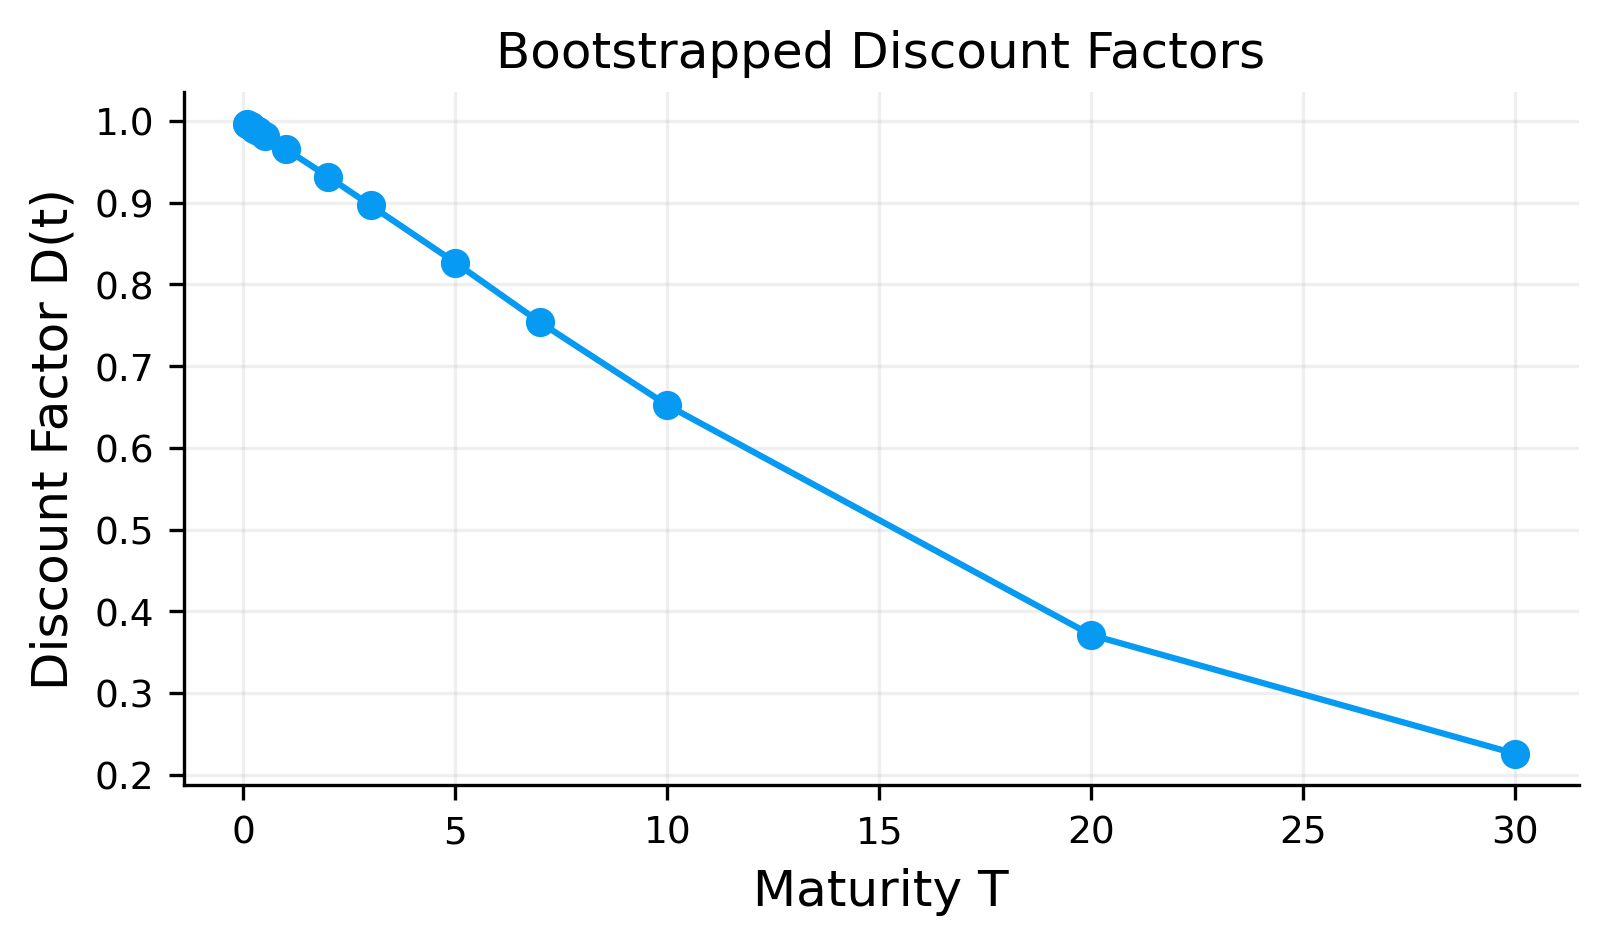

In [ ]:
df_dec = df.copy()
df_dec[tenor_cols] = df_dec[tenor_cols] / 100.0

short_end_convention = "continuous"
f = 2
min_d = 1e-12


def labels_to_T(labels):
    T = []
    for lab in labels:
        labu = lab.upper().strip()
        if labu.endswith("M"):
            T.append(int(labu[:-1]) / 12.0)
        else:
            T.append(float(int(labu[:-1])))
    return np.array(T, dtype=float)


def get_par_from_row(row):
    y = row[tenor_cols].astype(float)
    mask = np.isfinite(y.values)
    labels = [tenor_cols[i] for i in range(len(tenor_cols)) if mask[i]]
    if len(labels) == 0:
        return None

    par = y.values[mask].astype(float)
    T = labels_to_T(labels)

    i = np.argsort(T)
    T = T[i]
    par = par[i]
    labels = [labels[i] for i in i]

    return T, par, labels


def get_par_for_date(date):
    row = df_dec.loc[date]
    return get_par_from_row(row)


def short_end_df(Ti, ri):
    if short_end_convention == "continuous":
        return math.exp(-ri * Ti)
    return 1.0 / (1.0 + ri * Ti)


def price_error_loglinear(d_T, Ti, t_prev, d_prev, times_interp, c, pv_known):
    d_T = max(float(d_T), min_d)
    pv_interp = 0.0
    if len(times_interp) > 0:
        w = (times_interp - t_prev) / (Ti - t_prev)
        log_d = (1 - w) * np.log(d_prev) + w * np.log(d_T)
        d_interp = np.exp(log_d)
        pv_interp = np.sum((c / f) * d_interp)
    return pv_known + pv_interp + d_T - 1.0


def solve_df_long_end(Ti, ri, d_map):
    c = float(ri)
    n = int(round(Ti * f))
    times = np.array([k / f for k in range(1, n + 1)], dtype=float)


    known_T = np.array(sorted(d_map.keys()), dtype=float)
    known_D = np.array([d_map[t] for t in known_T], dtype=float)
    known_D = np.clip(known_D, min_d, None)


    t_prev = known_T[-1]
    d_prev = known_D[-1]

    times_known = times[times <= t_prev + 1e-12]
    times_interp = times[times > t_prev + 1e-12]

    pv_known = 0.0
    if len(times_known) > 0:
        log_known_D = np.log(known_D)
        log_df_known = np.interp(times_known, known_T, log_known_D)
        d_known = np.exp(log_df_known)
        pv_known = np.sum((c / f) * d_known)

    lo = min_d
    hi = d_prev
    f_lo = price_error_loglinear(lo, Ti, t_prev, d_prev, times_interp, c, pv_known)
    f_hi = price_error_loglinear(hi, Ti, t_prev, d_prev, times_interp, c, pv_known)

    if f_lo * f_hi > 0:
    
        log_known_D = np.log(known_D)
        log_df_cpn = np.interp(
            times[:-1],
            known_T,
            log_known_D,
            left=log_known_D[0],
            right=log_known_D[-1],
        )
        d_cpn = np.exp(log_df_cpn)
        pv_coupons = np.sum((c / f) * d_cpn)
        d_T = (1.0 - pv_coupons) / (1.0 + c / f)
    else:
        for _ in range(100):
            mid = 0.5 * (lo + hi)
            f_mid = price_error_loglinear(mid, Ti, t_prev, d_prev, times_interp, c, pv_known)
            if f_lo * f_mid <= 0:
                hi = mid
                f_hi = f_mid
            else:
                lo = mid
                f_lo = f_mid
            if abs(hi - lo) < 1e-12:
                break
        d_T = 0.5 * (lo + hi)

    return d_T


def bootstrap_from_inputs(T, par, labels, date=None):
    d_map = {}

    for Ti, ri in zip(T, par, strict=True):
        if Ti < 1.0:
            d_T = short_end_df(Ti, ri)
            d_map[Ti] = max(float(d_T), min_d)
            continue

        d_T = solve_df_long_end(Ti, ri, d_map)
        if (not np.isfinite(d_T)) or (d_T <= 0):
            d_T = min_d
        d_map[Ti] = max(float(d_T), min_d)

    dfs = np.array([d_map[t] for t in T], dtype=float)

    return {
        "date": date,
        "T": T,
        "par": par,
        "labels": labels,
        "dfs": dfs,
    }


def bootstrap_pillars(date):
    result = get_par_for_date(date)
    if result is None:
        return None

    T, par, labels = result
    return bootstrap_from_inputs(T, par, labels, date=date)


# we bootstrap discount factors at the last available date for now
base_date = df_dec.index[-1]
pillars = bootstrap_pillars(base_date)

T = pillars["T"]
par = pillars["par"]
labels = pillars["labels"]
dfs = pillars["dfs"]

print("Base date:", base_date.date())
print("Tenors used:", labels)
print("First 5 pillar DFs:", dfs)

plt.figure()
plt.plot(T, dfs, marker="o")
plt.title("Bootstrapped Discount Factors")
plt.xlabel("Maturity T")
plt.ylabel("Discount Factor D(t)")
plt.show()


## 6) Turning Bootstrapped Pillars into a Full Curve

After bootstrapping we have pillars $(T_j, D(T_j))$ or $(T_j, z(T_j))$.
Now we want to define continuous functions $D(t)$ and $z(t)$ for all $t$.

### 6.1 Method A: Log-linear discount factors
Interpolate $\ln D(t)$ linearly between pillars (just like for the T we had. we do the same thing between them):

$\ln D(t)=\text{linear interp of } \{\ln D(T_j)\}$



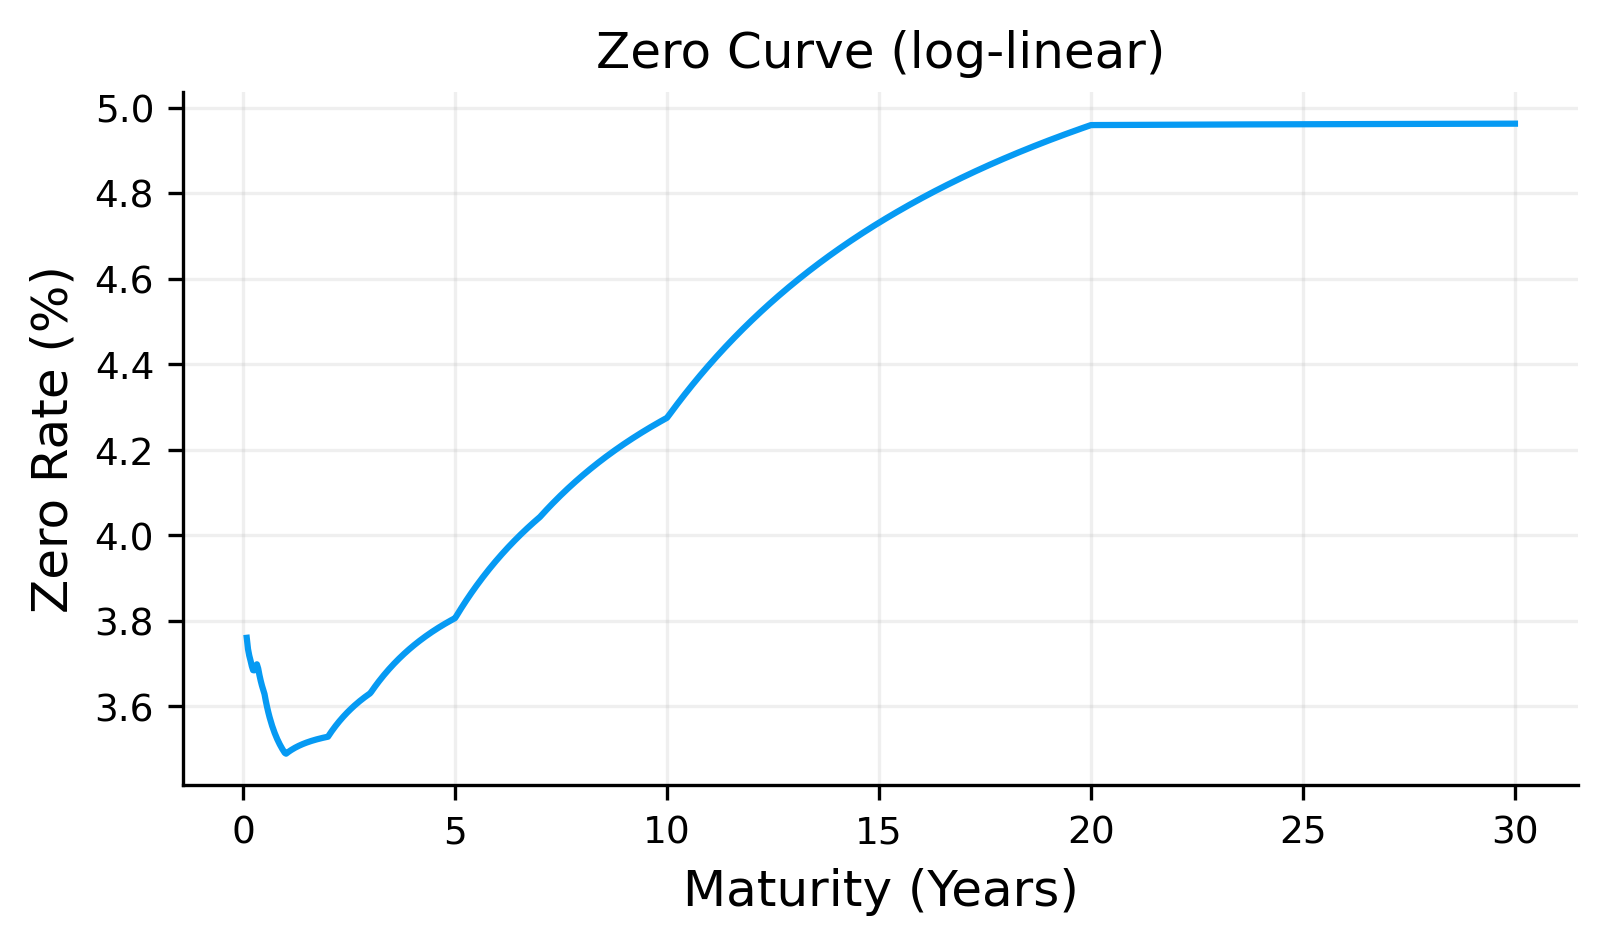

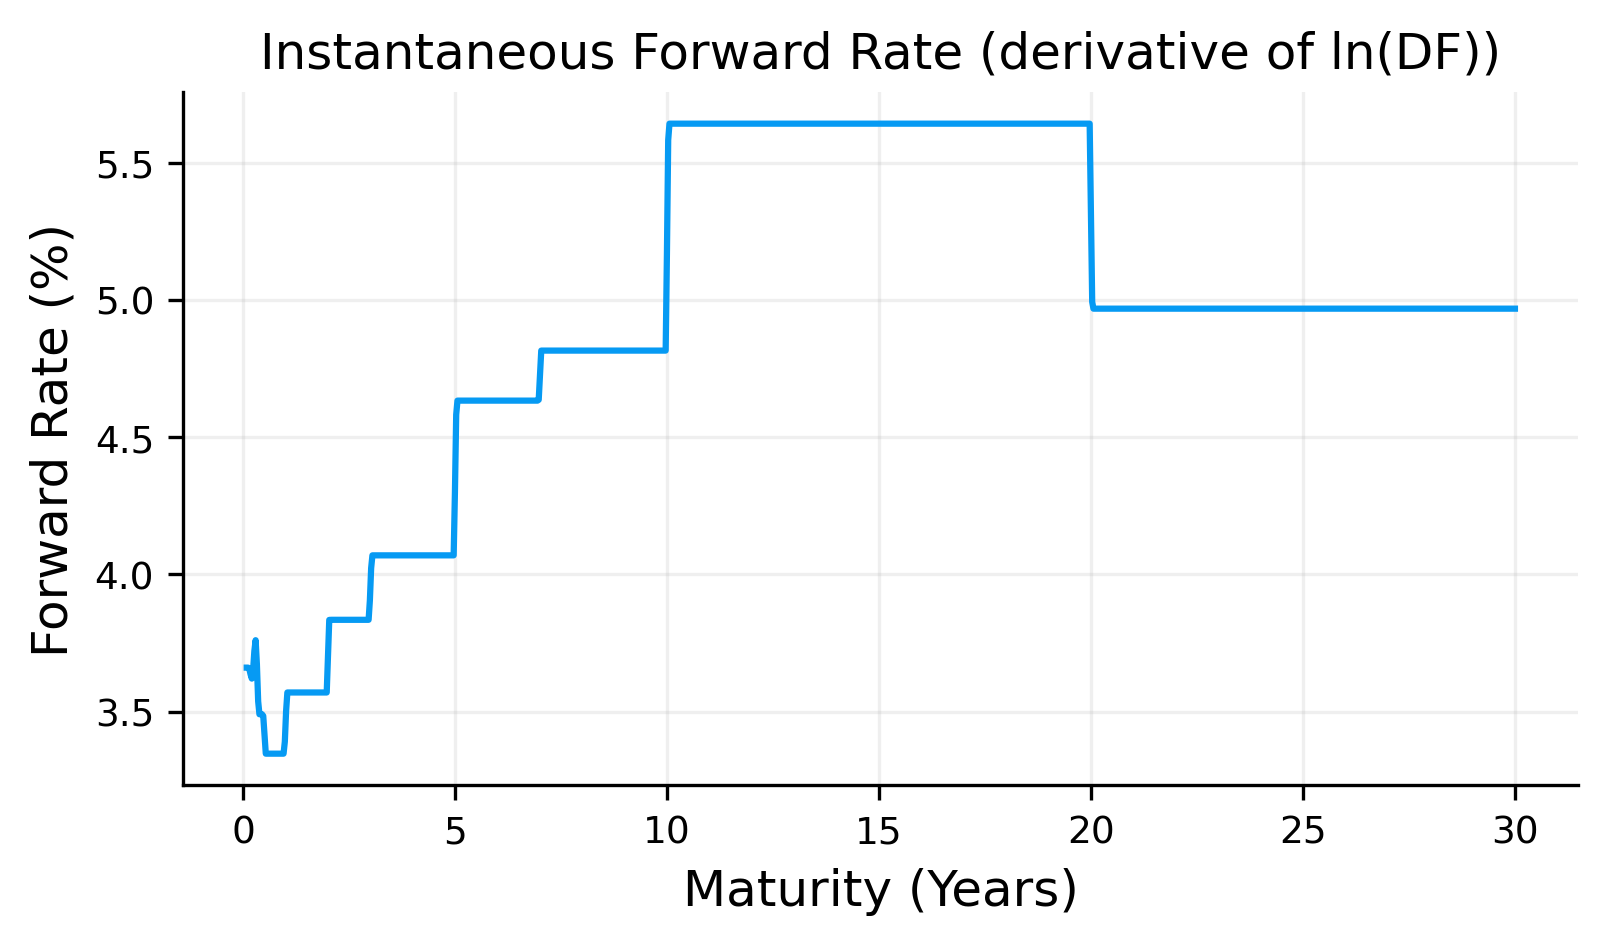

In [5]:
def loglinear_curve(T, dfs):
    loglinear_log_dfs = np.log(dfs)

    loglinear_grid = np.linspace(max(1 / 12, T.min()), 30.0, 1000)
    loglinear_log_df_grid = np.interp(
        loglinear_grid,
        T,
        loglinear_log_dfs,
        left=loglinear_log_dfs[0],
        right=loglinear_log_dfs[-1],
    )
    loglinear_df_grid = np.exp(loglinear_log_df_grid)

    # zero rate
    loglinear_z_grid = -np.log(loglinear_df_grid) / loglinear_grid

    # instantaneous forward rate
    loglinear_fwd_grid = -np.gradient(np.log(loglinear_df_grid), loglinear_grid)

    def loglinear_df_func(t):
        t = np.array(t, dtype=float)
        log_df = np.interp(
            t,
            T,
            loglinear_log_dfs,
            left=loglinear_log_dfs[0],
            right=loglinear_log_dfs[-1],
        )
        return np.exp(log_df)

    return {
        "name": "Log-linear DF",
        "grid": loglinear_grid,
        "df_grid": loglinear_df_grid,
        "z_grid": loglinear_z_grid,
        "fwd_grid": loglinear_fwd_grid,
        "df_func": loglinear_df_func,
        "log_dfs": loglinear_log_dfs,
    }


loglinear_curve_data = loglinear_curve(T, dfs)
loglinear_grid = loglinear_curve_data["grid"]
loglinear_df_grid = loglinear_curve_data["df_grid"]
loglinear_z_grid = loglinear_curve_data["z_grid"]
loglinear_fwd_grid = loglinear_curve_data["fwd_grid"]

if "curves" not in globals():
    curves = {}
curves["loglinear"] = loglinear_curve_data


plt.figure()
plt.plot(loglinear_grid, loglinear_z_grid * 100.0)
plt.title("Zero Curve (log-linear)")
plt.xlabel("Maturity (Years)")
plt.ylabel("Zero Rate (%)")
plt.show()

plt.figure()
plt.plot(loglinear_grid, loglinear_fwd_grid * 100.0)
plt.title("Instantaneous Forward Rate (derivative of ln(DF))")
plt.xlabel("Maturity (Years)")
plt.ylabel("Forward Rate (%)")
plt.show()


## 7) Curve Models Using Zero-Rate Smoothing

Instead of interpolating $D$, we can interpolate $z$ and recover $D(t)=e^{-z(t)t}$.

### 7.1 PCHIP on zero rates (Piecewise Cubic Hermite Interpolating Polynomial)
Given nodes $x_j=T_j$ and $y_j=z(T_j)$, PCHIP builds a piecewise cubic polynomial on each interval:

$$
p_j(t)=a_j(t-x_j)^3+b_j(t-x_j)^2+c_j(t-x_j)+d_j  \quad t\in[x_j,x_{j+1}]
$$

Constraints include:
- $p_j(x_j)=y_j$ and $p_j(x_{j+1})=y_{j+1}$
- first derivatives are chosen by shape-preserving slope rules to reduce overshoot

we define
$$z(t)=p_j(t)$$

then
$$D(t)=e^{-z(t)t}$$



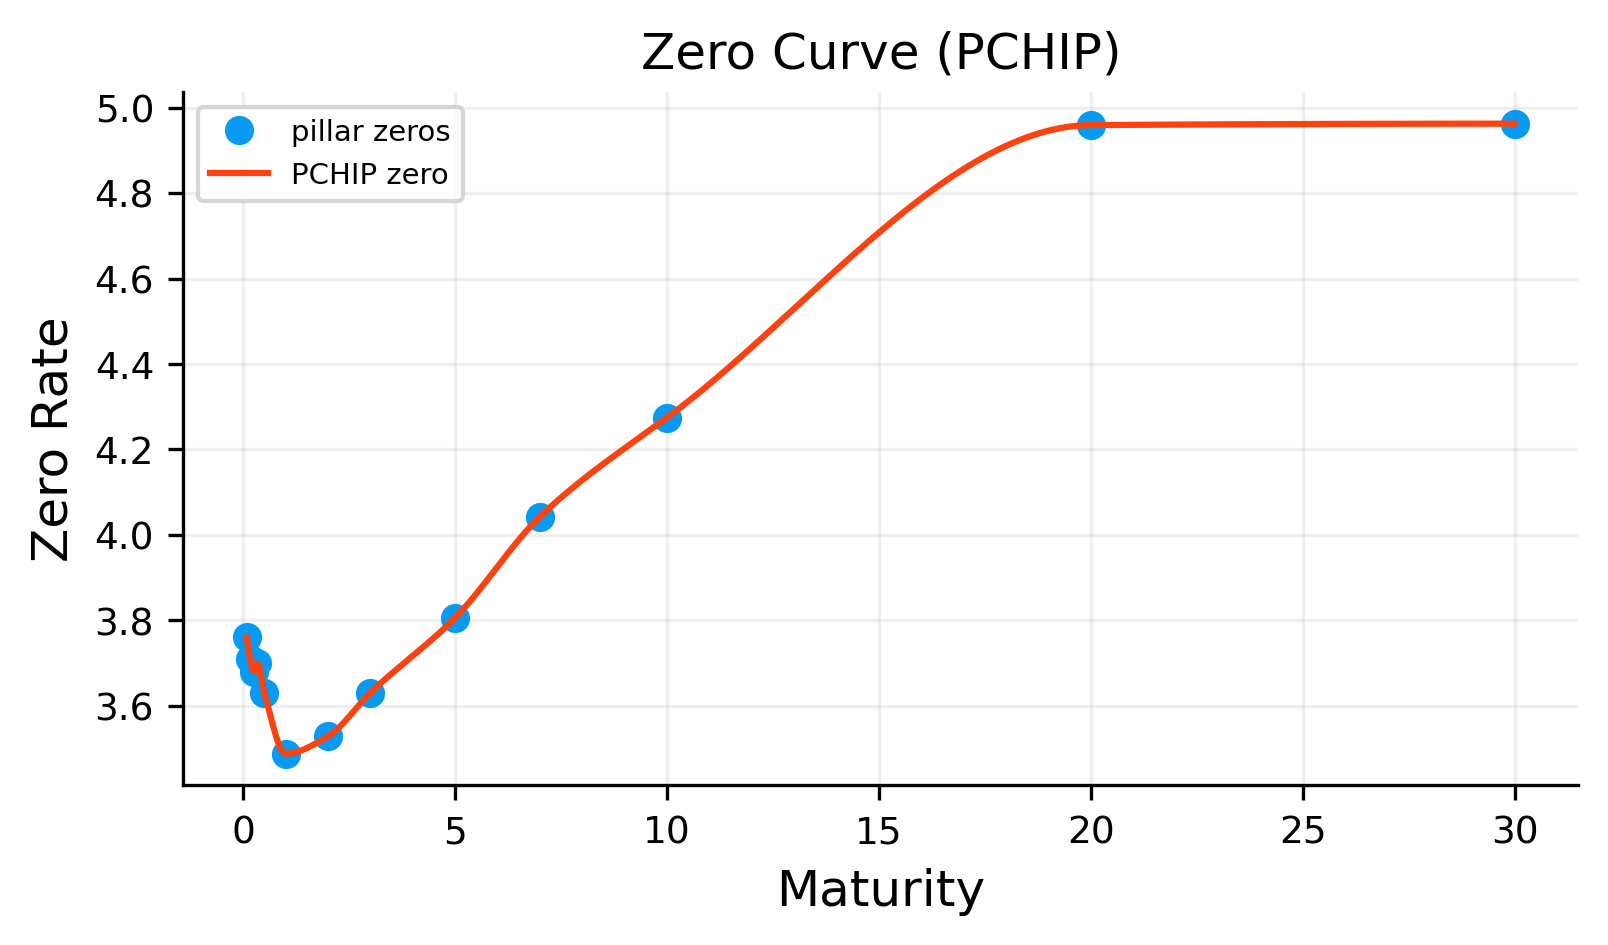

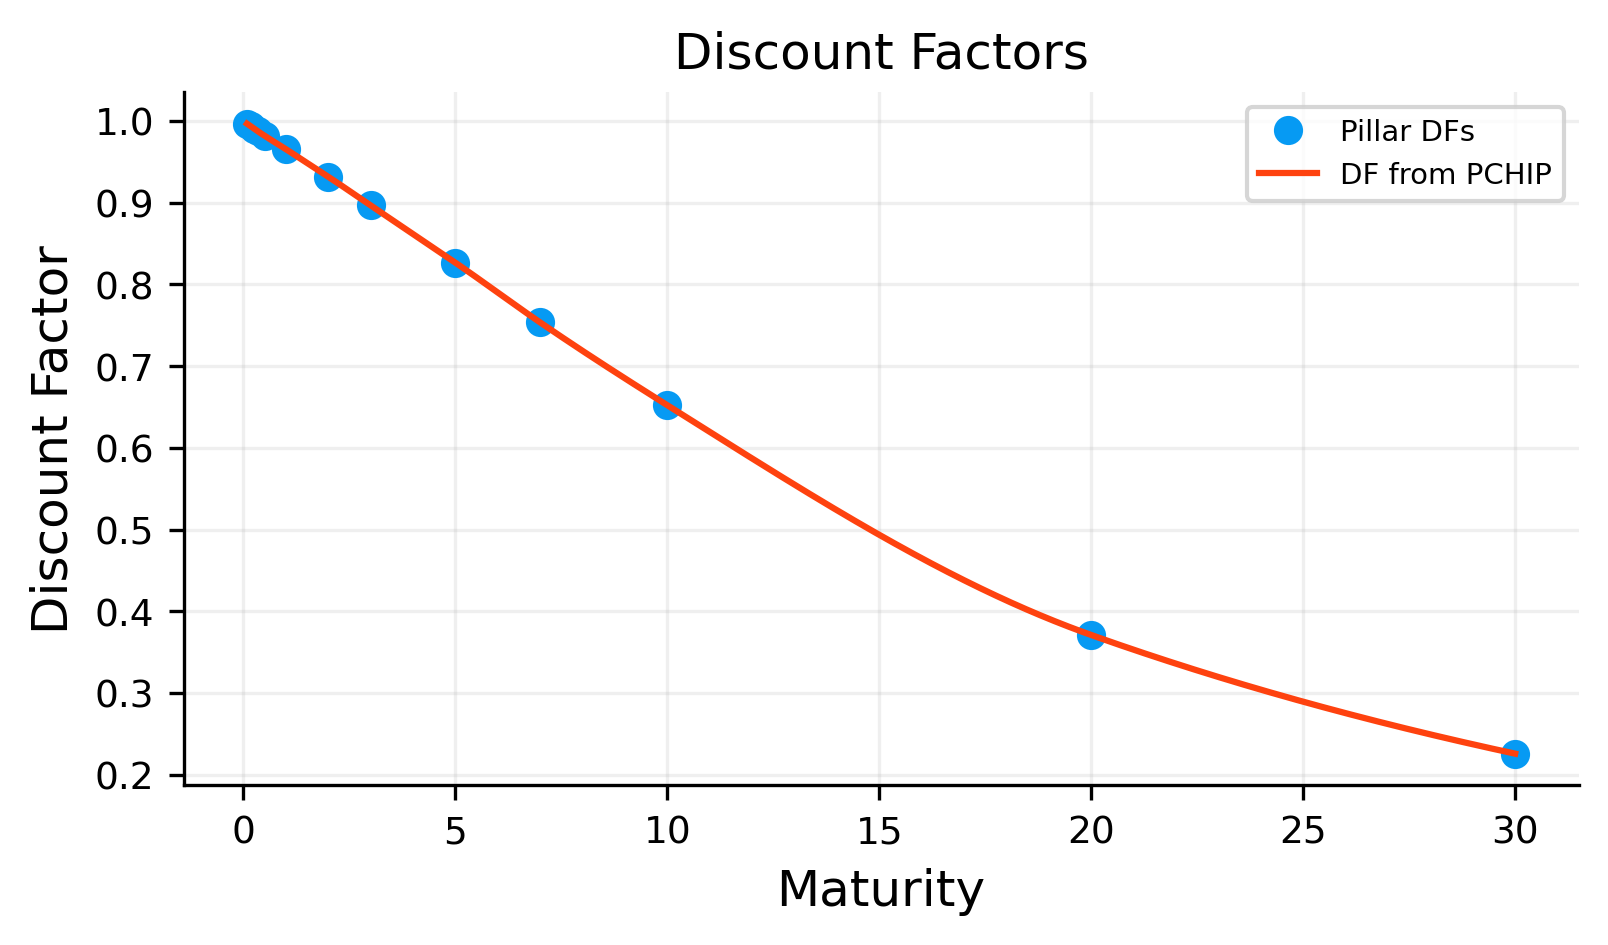

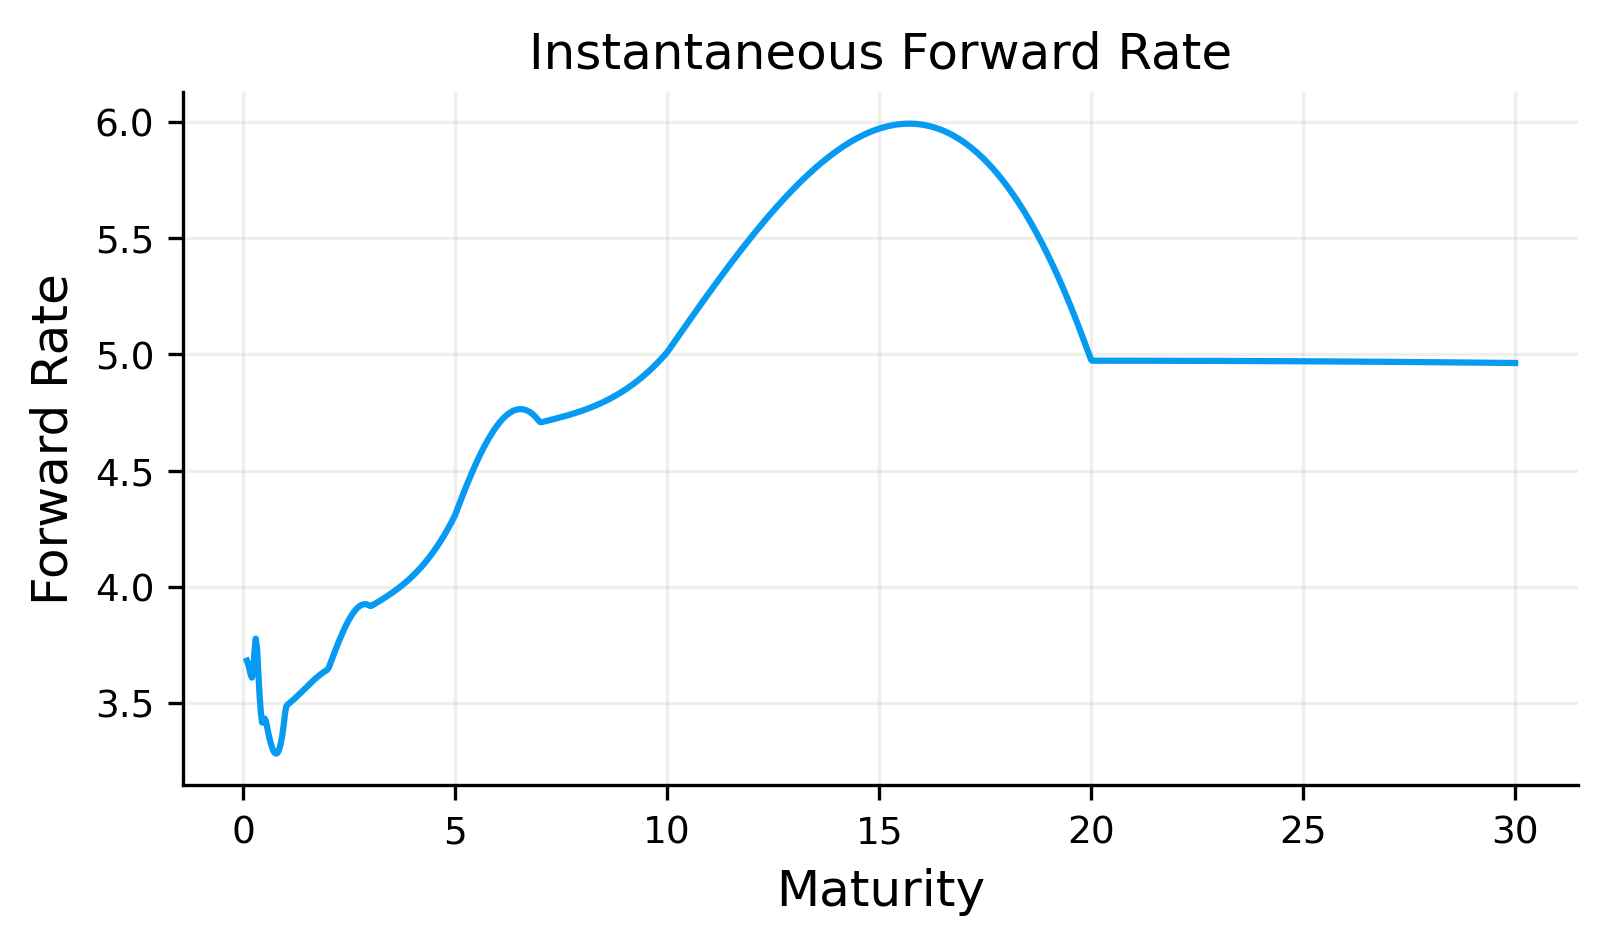

In [6]:
from scipy.interpolate import PchipInterpolator


def pchip_curve(T, dfs):
    pchip_zeros = -np.log(np.clip(dfs, min_d, None)) / T

    pchip_z = PchipInterpolator(T, pchip_zeros, extrapolate=True)
    pchip_grid = np.linspace(max(1 / 12, T.min()), 30.0, 1000)
    pchip_z_grid = pchip_z(pchip_grid)
    pchip_df_grid = np.exp(-pchip_z_grid * pchip_grid)

    pchip_fwd_grid = -np.gradient(
        np.log(np.clip(pchip_df_grid, min_d, None)), pchip_grid
    )

    def pchip_df_func(t):
        t = np.array(t, dtype=float)
        z = pchip_z(t)
        return np.exp(-z * t)

    return {
        "name": "PCHIP zero",
        "grid": pchip_grid,
        "df_grid": pchip_df_grid,
        "z_grid": pchip_z_grid,
        "fwd_grid": pchip_fwd_grid,
        "df_func": pchip_df_func,
        "pillar_zeros": pchip_zeros,
    }


pchip_curve_data = pchip_curve(T, dfs)
curves["pchip"] = pchip_curve_data


plt.figure()
plt.plot(T, pchip_curve_data["pillar_zeros"] * 100.0, "o", label="pillar zeros")
plt.plot(pchip_curve_data["grid"], pchip_curve_data["z_grid"] * 100.0, "-", label="PCHIP zero")
plt.title("Zero Curve (PCHIP)")
plt.xlabel("Maturity")
plt.ylabel("Zero Rate")
plt.legend()
plt.show()

plt.figure()
plt.plot(T, dfs, "o", label="Pillar DFs")
plt.plot(pchip_curve_data["grid"], pchip_curve_data["df_grid"], "-", label="DF from PCHIP")
plt.title("Discount Factors")
plt.xlabel("Maturity")
plt.ylabel("Discount Factor")
plt.legend()
plt.show()

plt.figure()
plt.plot(pchip_curve_data["grid"], pchip_curve_data["fwd_grid"] * 100.0)
plt.title("Instantaneous Forward Rate")
plt.xlabel("Maturity")
plt.ylabel("Forward Rate")
plt.show()


## 8) Nelson–Siegel–Svensson (NSS) yield curve

we represent the continuous-compounded zero rate curve $z(t)$ with a small number of parameters, then derive discount factors, par yields and forwards

### 8.1 NSS zero-rate function

For maturity $t>0$, the NSS zero rate is:

$$
z(t)=\beta_0 +\beta_1\left(\frac{1-e^{-t/\tau_1}}{t/\tau_1}\right) +\beta_2\left(\frac{1-e^{-t/\tau_1}}{t/\tau_1}-e^{-t/\tau_1}\right) +\beta_3\left(\frac{1-e^{-t/\tau_2}}{t/\tau_2}-e^{-t/\tau_2}\right)
$$

Parameters:

- $\beta_0$ = long-run “level”

- $\beta_1$ = “slope” (short-end effect)

- $\beta_2$ = medium-term “curvature” (first hump)

- $\beta_3$ = additional curvature (second hump)

- $\tau_1,\tau_2>0$ control where humps occur

In [7]:
def nss_zero(t, b0,b1,b2,b3,tau1,tau2):
    t = np.array(t, dtype=float)
    x1 = t / tau1
    x2 = t / tau2
    L1 = (1.0 - np.exp(-x1)) / x1
    C1 = L1 - np.exp(-x1)
    C2 = (1.0 - np.exp(-x2)) / x2 - np.exp(-x2)
    return b0 + b1*L1 + b2*C1 + b3*C2


### 8.2 Par yield implied by NSS

For a coupon bond with maturity $T$ and coupon frequency $f$, coupon rate $c(T)$ is the rate that makes the bond price equal to par (normalize notional to 1):

$$
1=\sum_{i=1}^{n}\frac{c(T)}{f}D(t_i)+D(T)
$$

Solve for $c(T)$:

$$
c(T)=f\cdot\frac{1-D(T)}{\sum_{i=1}^{n}D(t_i)}
$$


For short maturities (money-market style), a common mapping is:

continuous: $y(T)=-\ln D(T)/T$

simple: $y(T)=(1/D(T)-1)/T$

but first we have to have $D(t)$

In [8]:
def par_from_d(df_func, T_list, f=2):
    T_arr = np.asarray(T_list, dtype=float)
    out = np.full_like(T_arr, np.nan, dtype=float)

    step = 1.0 / float(f)

    for k, Tk in enumerate(T_arr):
        if not np.isfinite(Tk) or Tk <= 0:
            continue

        D_T = float(np.asarray(df_func([Tk],), dtype=float)[0])
        D_T = max(D_T, min_d)

        if Tk < 1.0:
            if short_end_convention == "simple":
                out[k] = (1.0 / D_T - 1.0) / Tk
            else:
                out[k] = -np.log(D_T) / Tk
            continue

        n_full = int(np.floor(Tk * f + 1e-12))
        times = np.arange(step, n_full * step + 1e-12, step)
        if len(times) == 0 or abs(times[-1] - Tk) > 1e-10:
            times = np.append(times, Tk)

        accr = np.diff(np.concatenate([[0.0], times]))
        dfs = np.asarray(df_func(times), dtype=float)
        dfs = np.clip(dfs, min_d, None)

        denom = float(np.sum(accr * dfs))
        out[k] = (1.0 - dfs[-1]) / denom if denom > 0 else np.nan

    return out


### 8.3 Discount factor and forward from NSS

Once we have $z(t)$, using continuous compounding:

$D(t)=e^{-z(t)t}$

and the instantaneous forward rate is:

$f(t)=-\frac{d}{dt}\ln D(t)$

With NSS you often compute $f(t)$ numerically on a grid:
$$f(t_i)\approx -\frac{\ln D(t_{i+1})-\ln D(t_{i-1})}{t_{i+1}-t_{i-1}}
$$

---

### 8.4 Calibrating NSS to market par yields

Given observed par yields $y^{mkt}(T_j)$ at tenors $T_j$, we choose parameters
$\theta=(\beta_0,\beta_1,\beta_2,\beta_3,\tau_1,\tau_2)$ to minimize a least-squares objective:

$$\min_{\theta}\sum_{j}\left(c^{model}(T_j;\theta)-y^{mkt}(T_j)\right)^2
$$

Optionally add regularization to discourage extreme shapes:
$\lambda\sum_j (z''(t_j))^2$ or bounds on parameters.

**L-BFGS**: Limited memory BFGS is a second order optimization method (a Quasi-Newton method) that uses the last m values and gradients for approximation of inverse Hessian and has power in handling high dimentions or huge datasets without having second derivative.

final MSE: 3.5093289069366877e-07
theta = [b0,b1,b2,b3,tau1,tau2] = [ 0.053115 -0.014698 -0.031572 -0.007968  1.500251  5.000021]


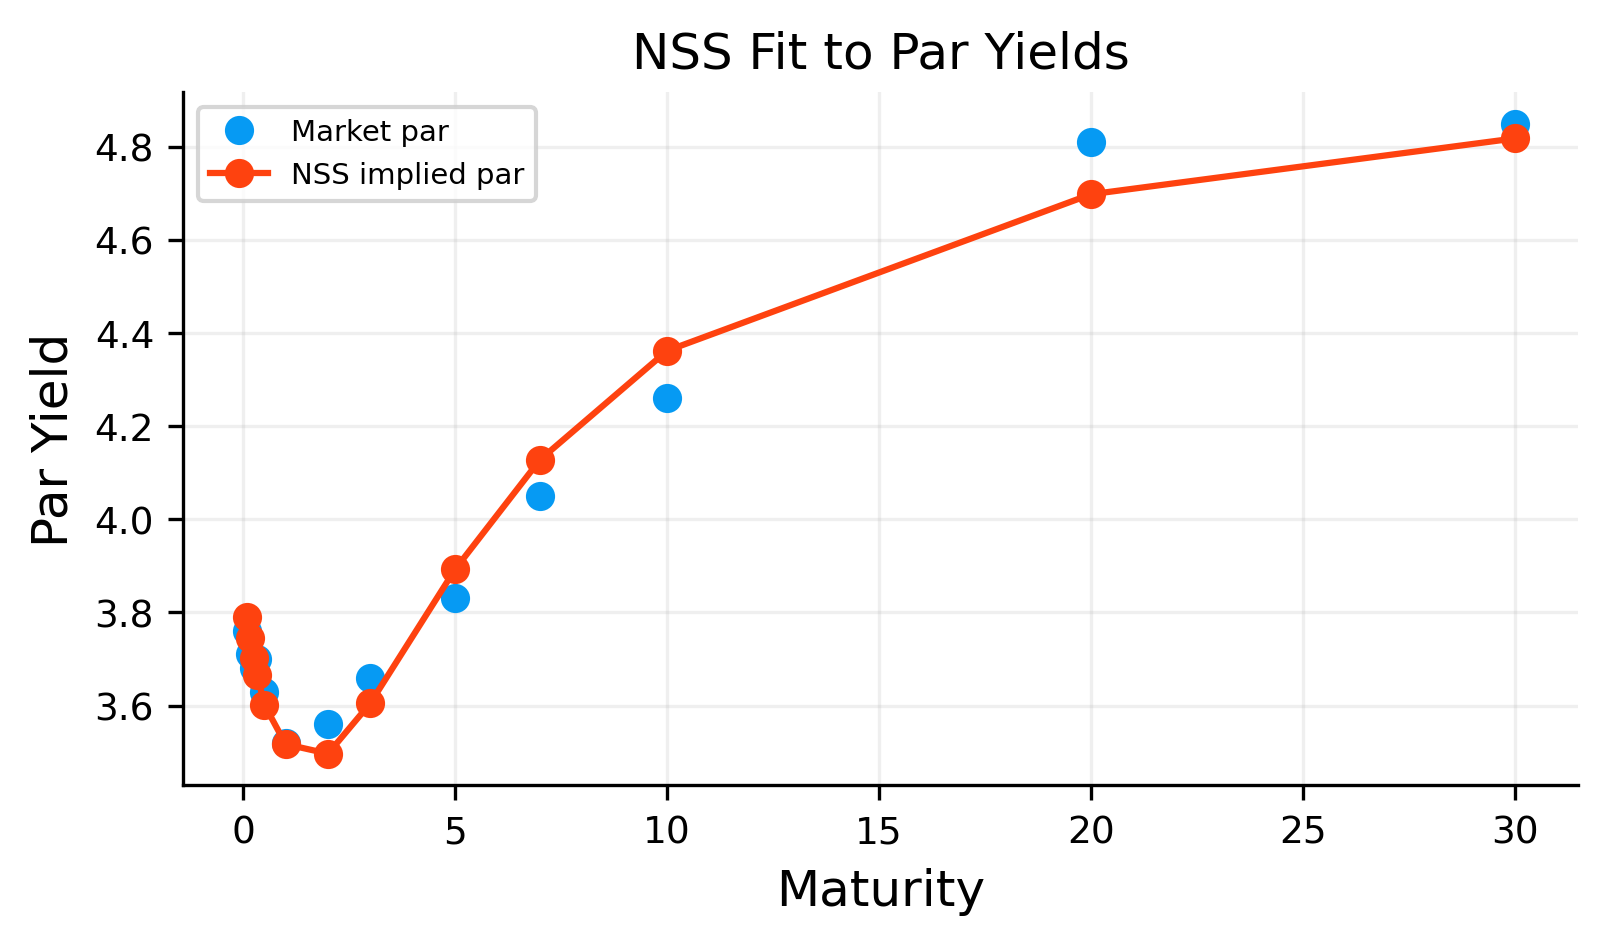

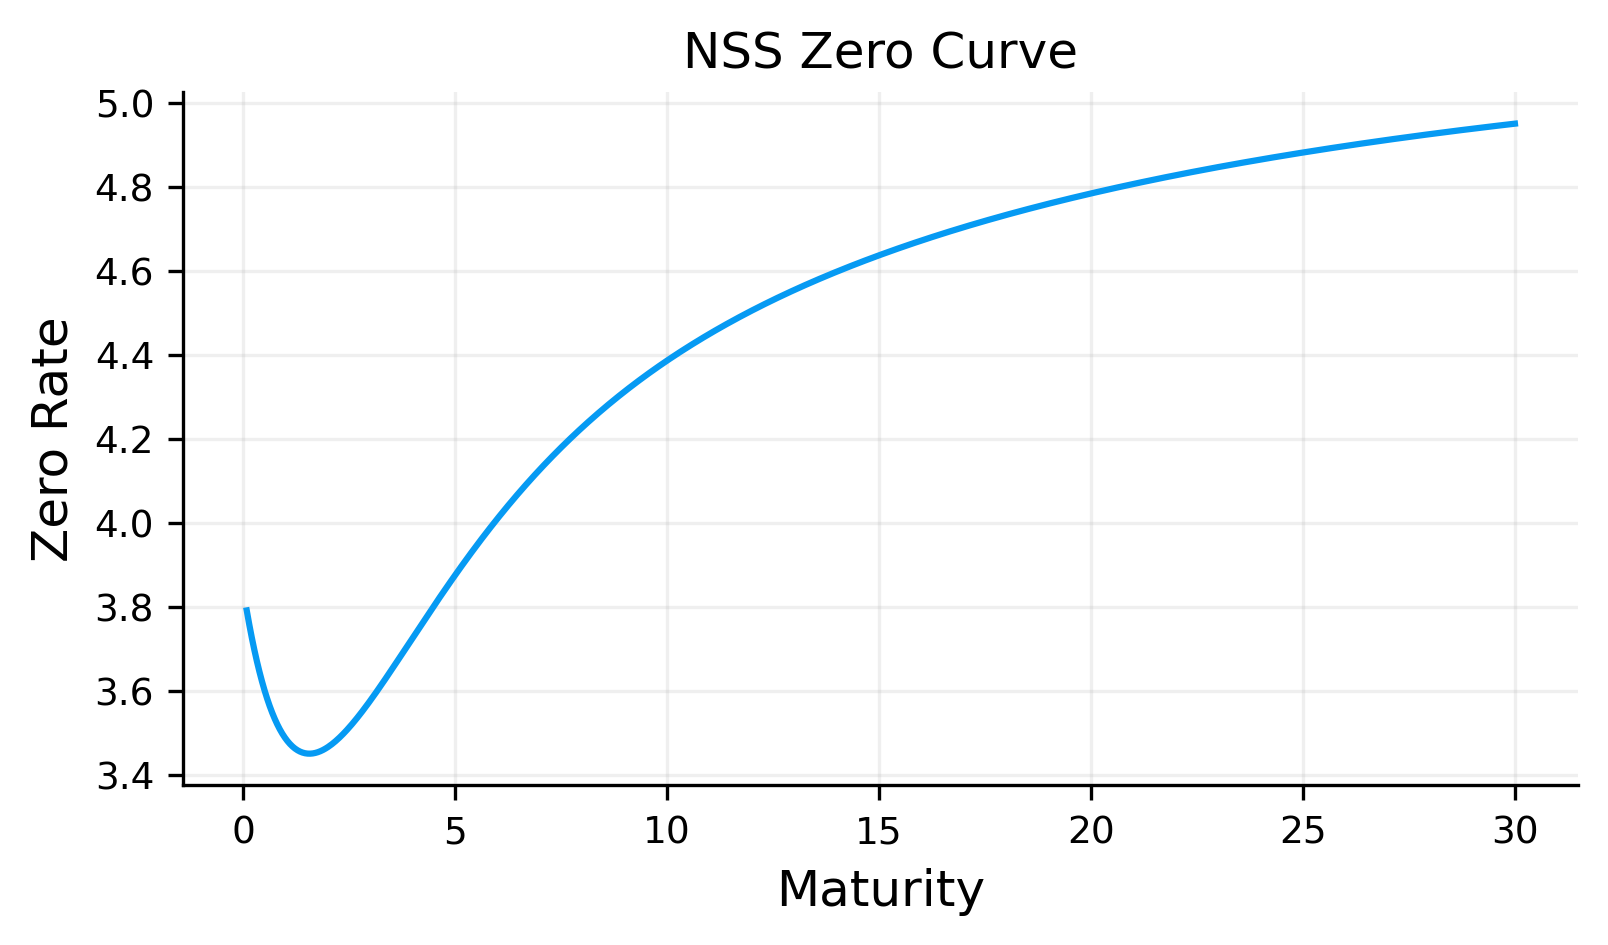

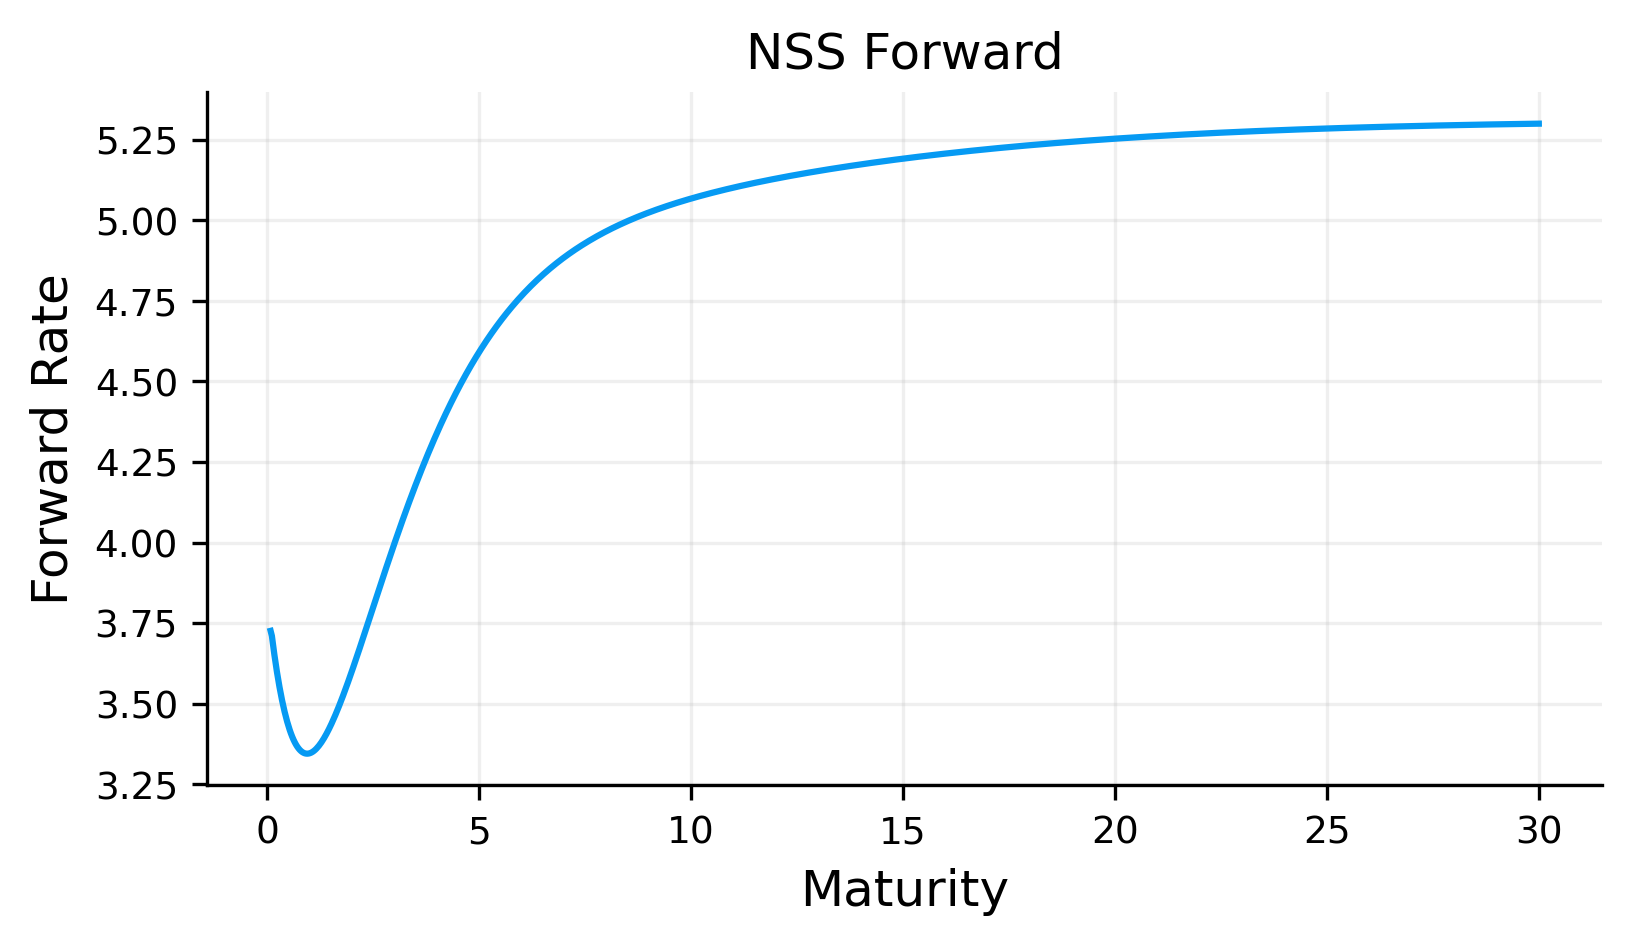

In [9]:
from scipy.optimize import minimize


def nss_curve(T, par):
    def obj(theta):
        b0, b1, b2, b3, tau1, tau2 = theta
        z = nss_zero(T, b0, b1, b2, b3, tau1, tau2)
        dfs = np.exp(-z * T)

        # we use log-linear DF interpolation on pillars for keeping it positive
        log_dfs = np.log(np.clip(dfs, min_d, None))

        def df_func(t):
            t = np.array(t, dtype=float)
            log_df = np.interp(t, T, log_dfs, left=log_dfs[0], right=log_dfs[-1])
            return np.exp(log_df)

        par_model = par_from_d(df_func, T)
        err = par_model - par
        return float(np.mean(err**2))

    # initializing with a first guess. for long run level we need something like the long-run yield level. that's why we use long term yields as guess
    b0_0 = float(np.nanmedian(par[-3:])) if len(par) >= 3 else float(np.nanmedian(par))
    x0 = np.array([b0_0, -0.02, 0.02, 0.01, 1.5, 5.0], dtype=float)


    pred = minimize(obj, x0, method="L-BFGS-B")
    theta = pred.x

    nss_grid = np.linspace(max(1 / 12, T.min()), 30.0, 1000)
    nss_z_grid = nss_zero(nss_grid, *theta)
    nss_df_grid = np.exp(-nss_z_grid * nss_grid)

    nss_fwd_grid = -np.gradient(
        np.log(np.clip(nss_df_grid, min_d, None)), nss_grid
    )

    def nss_df_func(t):
        t = np.array(t, dtype=float)
        return np.exp(-nss_zero(t, *theta) * t)

    curve = {
        "name": "NSS",
        "grid": nss_grid,
        "df_grid": nss_df_grid,
        "z_grid": nss_z_grid,
        "fwd_grid": nss_fwd_grid,
        "df_func": nss_df_func,
        "theta": theta,
    }


    z_p = nss_zero(T, *theta)
    d_p = np.exp(-z_p * T)
    log_d_p = np.log(np.clip(d_p, min_d, None))
    def df_func_p(tt):
        return np.exp(
            np.interp(np.array(tt, float), T, log_d_p, left=log_d_p[0], right=log_d_p[-1])
        )
    par_fit = par_from_d(df_func_p, T)

    return curve, par_fit, pred


nss_curve_data, par_fit, pred = nss_curve(T, par)
theta = nss_curve_data["theta"]

if "curves" not in globals():
    curves = {}
curves["nss"] = nss_curve_data

print("final MSE:", pred.fun)
print("theta = [b0,b1,b2,b3,tau1,tau2] =", np.round(theta, 6))

plt.figure()
plt.plot(T, par * 100.0, "o", label="Market par")
plt.plot(T, par_fit * 100.0, "-o", label="NSS implied par")
plt.title("NSS Fit to Par Yields")
plt.xlabel("Maturity")
plt.ylabel("Par Yield")
plt.legend()
plt.show()

plt.figure()
plt.plot(nss_curve_data["grid"], nss_curve_data["z_grid"] * 100.0)
plt.title("NSS Zero Curve")
plt.xlabel("Maturity")
plt.ylabel("Zero Rate")
plt.show()

plt.figure()
plt.plot(nss_curve_data["grid"], nss_curve_data["fwd_grid"] * 100.0)
plt.title("NSS Forward")
plt.xlabel("Maturity")
plt.ylabel("Forward Rate")
plt.show()


## 9) QP curve: smooth discount factors under exact par-bond fit

Another approach for building a yield curve that:

- matches par-bond pricing equations exactly (like bootstrapping) or near-exactly (like NSS),

- is smooth,

- will result in a positive and increasing DF curve.

can come from a Quadratic Program (QP) if the variables are discount factors on a grid and constraints are linear.

### 9.1 Variables

We Pick a grid of cashflow times (like semiannual up to 30Y):
$t_1,t_2,\dots,t_M$

we want to get to 
$$
\mathbf{d} = (D(t_1),\dots,D(t_M))
$$

### 9.2 constraints

For a maturity $T$ (present on the grid), par yield $c$ and frequency $f$:

$$
1=\sum_{i=1}^{n}\frac{c}{f}D(t_i)+D(T)
$$

This is linear in $D(\cdot)$, so it becomes one row of:
$A\mathbf{d}=\mathbf{1}$

Positivity: $D(t_k)\ge D_{min}$

Monotone decreasing: $D(t_{k+1})\le D(t_k)$

These are linear inequalities, so the problem stays convex and QP-solvable.

In [10]:
import cvxpy as cp


def qp_build_t_grid(T_obs, f):
    T_max = float(np.max(T_obs))
    n_grid = int(round(T_max * f))
    t_grid = np.unique(
        np.concatenate(
            [
                np.array([i / f for i in range(1, n_grid + 1)], dtype=float),
                T_obs,
            ]
        )
    )
    t_grid = np.array(sorted(t_grid), dtype=float)
    grid_index = {float(np.round(t, 10)): i for i, t in enumerate(t_grid)}
    return t_grid, grid_index


def qp_build_constraints(t_grid, grid_index, T_obs, par_mkt, f, min_d):
    d = cp.Variable(len(t_grid))

    constraints = []
    constraints += [d >= min_d]
    constraints += [d[1:] <= d[:-1]]

    for Tk, yk in zip(T_obs, par_mkt, strict=True):
        if Tk < 1.0:
            key = float(np.round(Tk, 10))
            if key in grid_index:
                i = grid_index[key]
                df_target = float(np.exp(-yk * Tk))
                constraints += [d[i] == df_target]

    for Tk, ck in zip(T_obs, par_mkt, strict=True):
        if Tk < 1.0:
            continue
        keyT = float(np.round(Tk, 10))
        if keyT not in grid_index:
            continue
        iT = grid_index[keyT]
        n = int(round(Tk * f))

        coupon_idx = []
        for j in range(1, n + 1):
            key = float(np.round(j / f, 10))
            coupon_idx.append(grid_index[key])

        constraints += [cp.sum((ck / f) * d[coupon_idx]) + d[iT] == 1.0]

    return d, constraints





### 9.3 Smoothness objective (quadratic)

A simple convex smoothness penalty is the squared second difference of Discount Factors:

$\min_{\mathbf{d}} \ |\Delta^2\mathbf{d}|_2^2$

where $\Delta^2 d_k = d_{k+2}-2d_{k+1}+d_k$. (Discrete version)

This makes the optimizer prefer sequences of discount factors that have small curvature everywhere, which results a smooth DF curve with fewer oscillations and jumps.

we can also add a mild “keep close to a prior curve” penalty:
$\epsilon|\mathbf{d}-\mathbf{d}^{prior}|_2^2$ 

Total objective:
$\min_{\mathbf{d}} \ \lambda|\Delta^2\mathbf{d}|_2^2 + \epsilon|\mathbf{d}-\mathbf{d}^{prior}|_2^2$

### 9.4 zero and forward curves

Once we have $D(t)$ on a grid:

$z(t_k)=-\ln D(t_k)/t_k$

$f(t_k)\approx -\dfrac{\ln D(t_{k+1})-\ln D(t_k)}{t_{k+1}-t_k}$

status: optimal ,  value: 1.2368745747617473


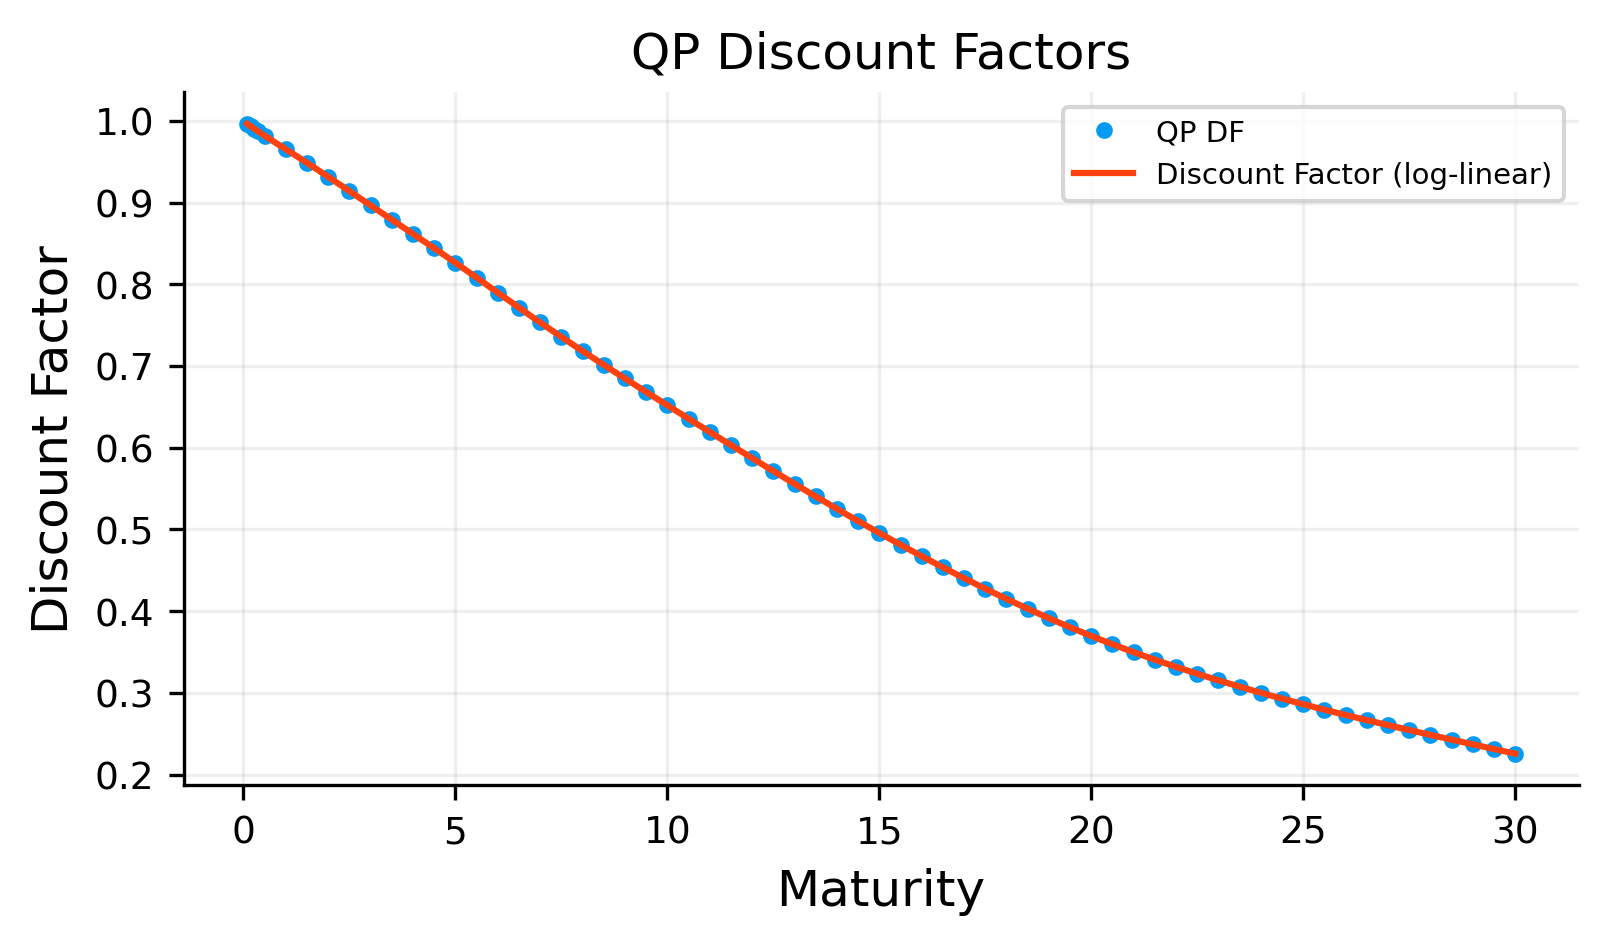

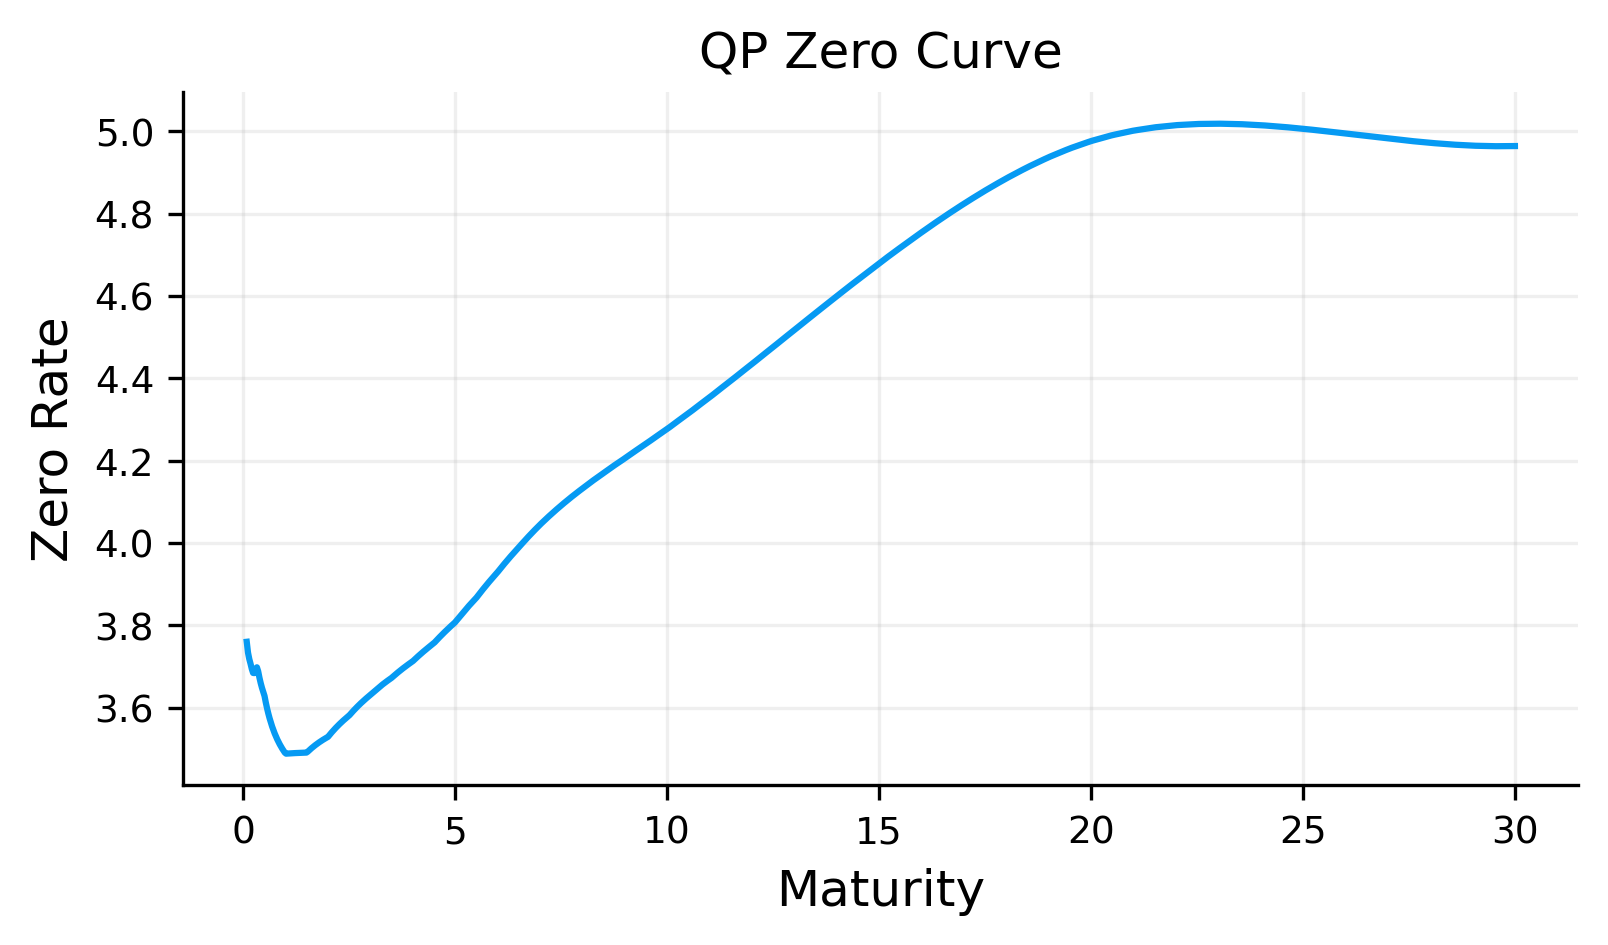

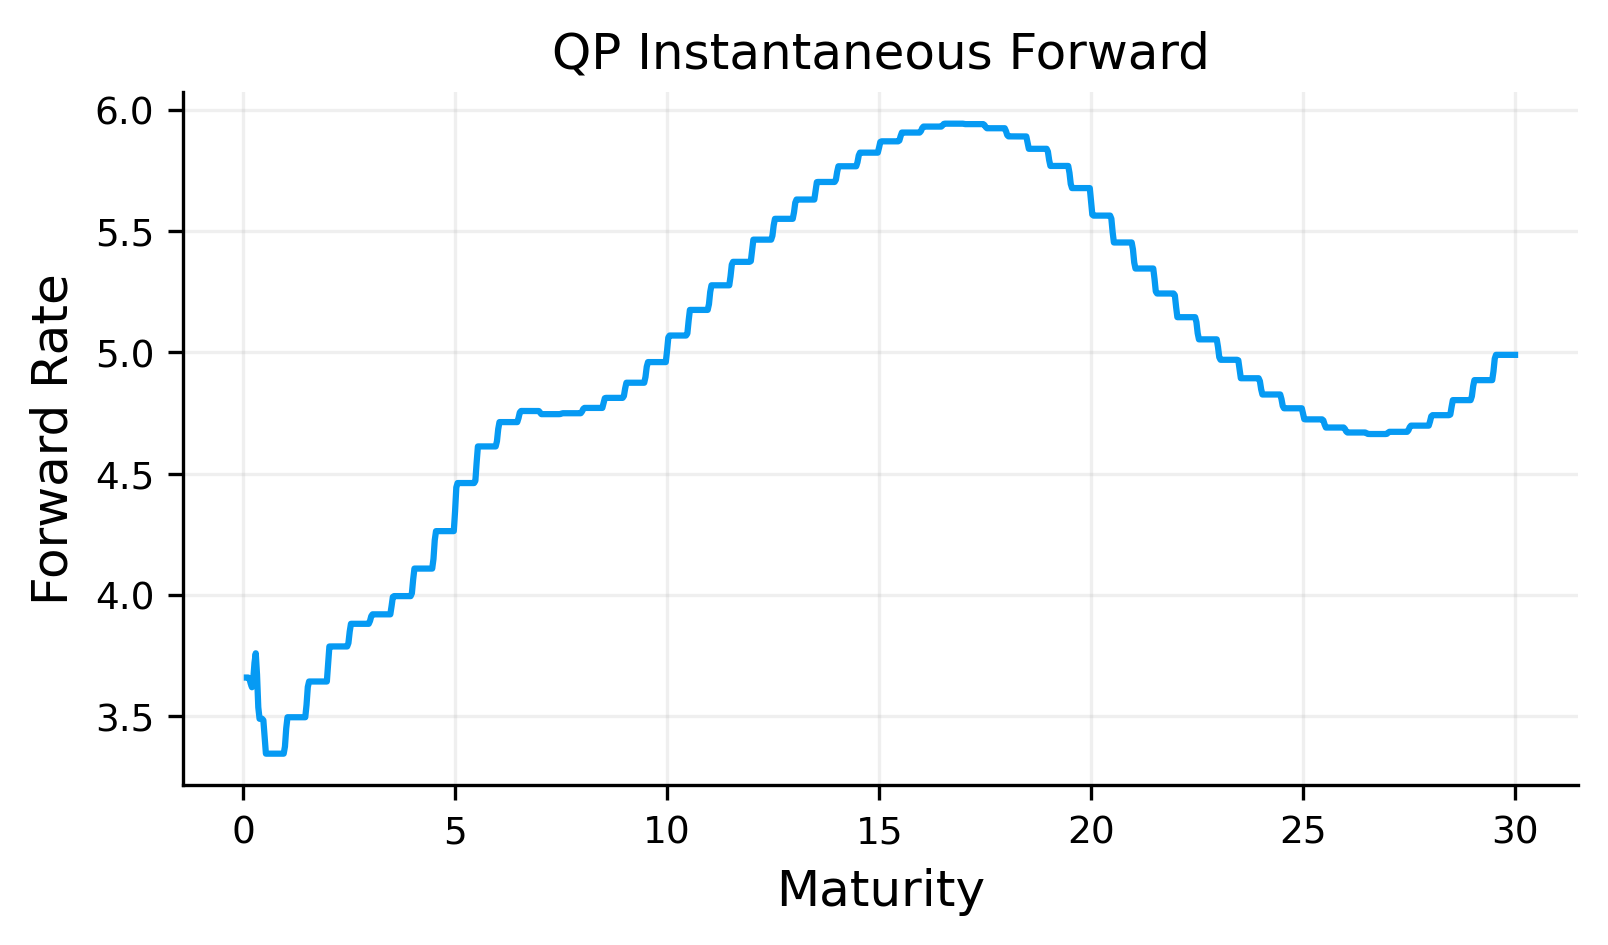

In [11]:
def qp_solve(t_grid, d, constraints, par_mkt, f, min_d):
    lam = 1e4
    eps = 1e-4
    prior_rate = (
        float(np.nanmedian(par_mkt[-3:])) if len(par_mkt) >= 3 else float(np.nanmedian(par_mkt))
    )
    d_prior = np.exp(-prior_rate * t_grid)

    d2 = d[2:] - 2 * d[1:-1] + d[:-2]
    obj = cp.Minimize(lam * cp.sum_squares(d2) + eps * cp.sum_squares(d - d_prior))

    problem = cp.Problem(obj, constraints)
    problem.solve(solver=cp.OSQP)

    d_sol = np.array(d.value).astype(float)
    d_sol = np.clip(d_sol, min_d, None)

    return d_sol, problem.status, problem.value


def qp_build_curve(t_grid, d_sol):
    qp_grid = np.linspace(max(1 / 12, t_grid.min()), 30.0, 1000)
    qp_log_d = np.log(d_sol)
    qp_log_df_grid = np.interp(qp_grid, t_grid, qp_log_d, left=qp_log_d[0], right=qp_log_d[-1])

    qp_df_grid = np.exp(qp_log_df_grid)
    qp_z_grid = -np.log(qp_df_grid) / np.maximum(qp_grid, 1e-8)
    qp_fwd_grid = -np.gradient(np.log(qp_df_grid), qp_grid)

    def qp_df_func(t):
        t = np.array(t, dtype=float)
        log_df = np.interp(t, t_grid, qp_log_d, left=qp_log_d[0], right=qp_log_d[-1])
        return np.exp(log_df)

    curve = {
        "name": "QP DF",
        "grid": qp_grid,
        "df_grid": qp_df_grid,
        "z_grid": qp_z_grid,
        "fwd_grid": qp_fwd_grid,
        "df_func": qp_df_func,
    }

    return curve


def qp_curve(labels, par_mkt, f=2, min_d=1e-10):
    T_obs = []
    for lab in labels:
        labu = lab.upper().strip()
        T_obs.append(int(labu[:-1]) / 12.0 if labu.endswith("M") else float(int(labu[:-1])))
    T_obs = np.array(T_obs, dtype=float)

    idx = np.argsort(T_obs)
    T_obs = T_obs[idx]
    par_mkt = par_mkt[idx]
    labels = [labels[i] for i in idx]

    t_grid, grid_index = qp_build_t_grid(T_obs, f)
    d, constraints = qp_build_constraints(t_grid, grid_index, T_obs, par_mkt, f, min_d)
    d_sol, status, value = qp_solve(t_grid, d, constraints, par_mkt, f, min_d)

    curve = qp_build_curve(t_grid, d_sol)

    state = {
        "t_grid": t_grid,
        "d_sol": d_sol,
        "constraints": constraints,
        "status": status,
        "value": value,
    }

    return curve, state


qp_curve_data, qp_state = qp_curve(labels, par)

curves["qp"] = qp_curve_data

print("status:", qp_state["status"], ",  value:", qp_state["value"])


plt.figure()
plt.plot(qp_state["t_grid"], qp_state["d_sol"], "o", markersize=3, label="QP DF")
plt.plot(qp_curve_data["grid"], qp_curve_data["df_grid"], "-", label="Discount Factor (log-linear)")
plt.title("QP Discount Factors")
plt.xlabel("Maturity")
plt.ylabel("Discount Factor")
plt.legend()
plt.show()

plt.figure()
plt.plot(qp_curve_data["grid"], qp_curve_data["z_grid"] * 100.0)
plt.title("QP Zero Curve")
plt.xlabel("Maturity")
plt.ylabel("Zero Rate")
plt.show()

plt.figure()
plt.plot(qp_curve_data["grid"], qp_curve_data["fwd_grid"] * 100.0)
plt.title("QP Instantaneous Forward")
plt.xlabel("Maturity")
plt.ylabel("Forward Rate")
plt.show()



# 10. Curve fit comparison and RMSE to observed par yields
We compute curve-implied par yields $\hat y(T_j)$ and compare to market $y(T_j)$:
$RMSE=\sqrt{\dfrac{1}{m}\sum_{j=1}^m (\hat y(T_j)-y(T_j))^2}$

for showing the performance, we use some of the tenors as in sample data for our models and some of them as out of sample to see the accuracy of predicting them.


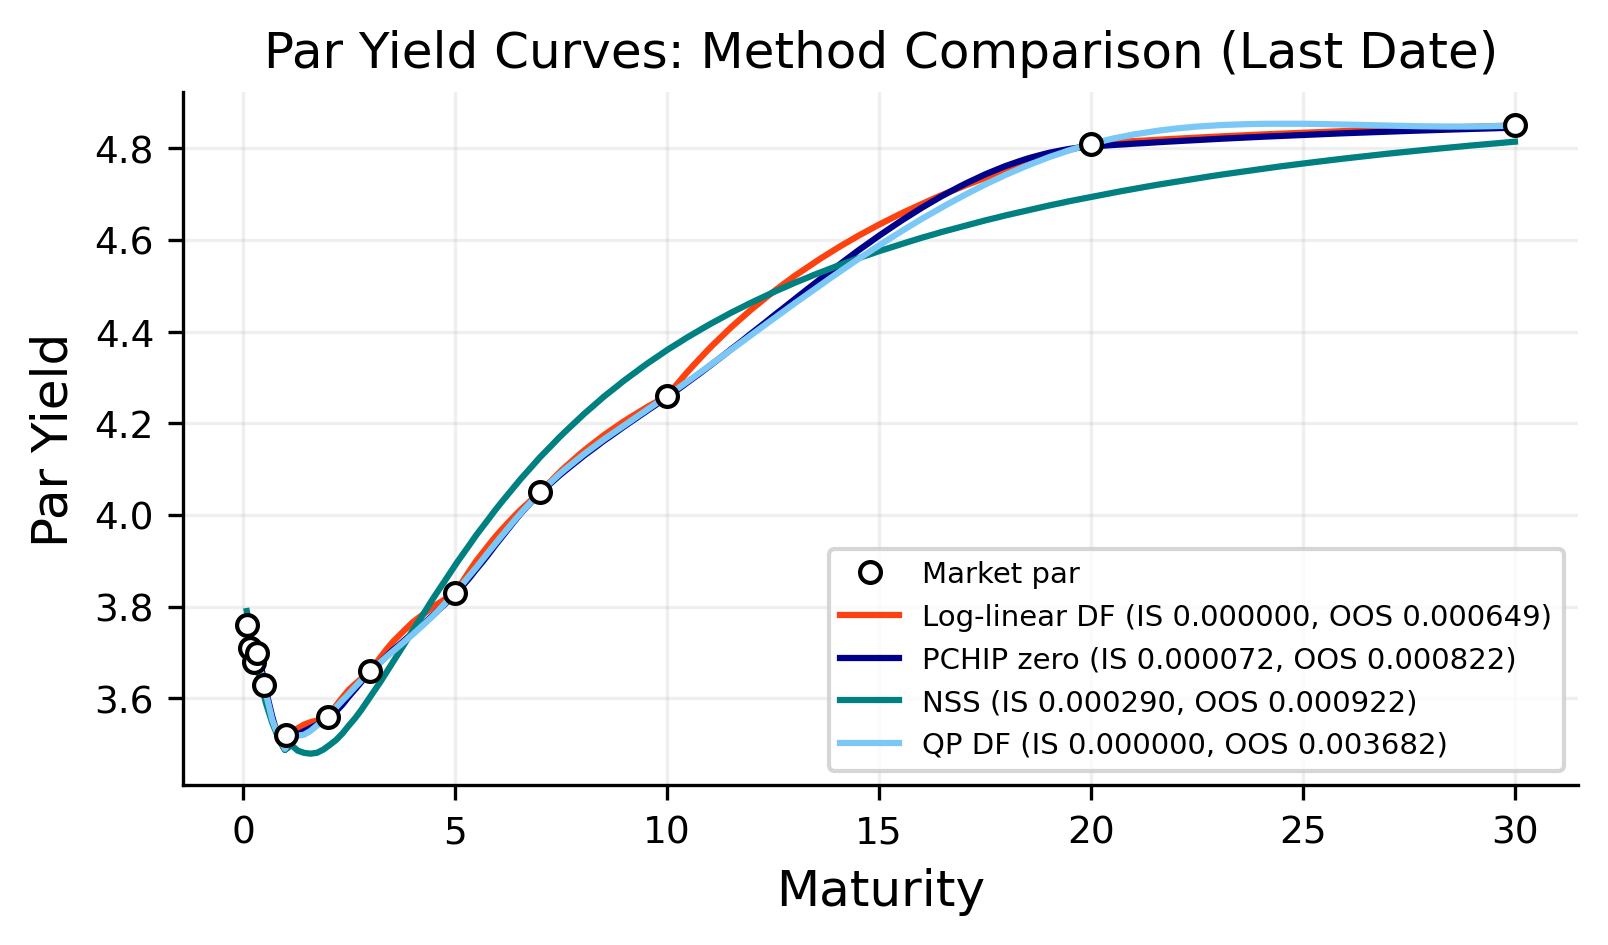

Primary curve selected for everything below: loglinear (Log-linear DF)


,name,rmse,rmse_oos,n_obs,n_obs_oos,n_dates,n_dates_oos
method,,,,,,,
loglinear,Log-linear DF,9.937239e-14,0.000649,900,400,100,100
pchip,PCHIP zero,7.233596e-05,0.000822,900,400,100,100
nss,NSS,2.895659e-04,0.000922,900,400,100,100
qp,QP DF,1.782548e-07,0.003682,900,400,100,100


In [12]:
def build_curves_for_date(date):
    pillars_full = bootstrap_pillars(date)
    if pillars_full is None:
        return None

    T_full = pillars_full["T"]
    par_full = pillars_full["par"]
    labels_full = pillars_full["labels"]

    holdouts = ["6M", "2Y", "7Y", "20Y"]
    holdout_idx = [labels_full.index(h) for h in holdouts if h in labels_full]

    holdout_idx = sorted(set([i for i in holdout_idx if 0 < i < len(labels_full) - 1]))
    min_train = 4
    if len(T_full) - len(holdout_idx) < min_train:
        holdout_idx = []

    if len(holdout_idx) > 0:
        mask_train = np.ones(len(T_full), dtype=bool)
        mask_train[holdout_idx] = False
        T_tr = T_full[mask_train]
        par_tr = par_full[mask_train]
        labels_tr = [labels_full[i] for i in range(len(labels_full)) if mask_train[i]]
        pillars = bootstrap_from_inputs(T_tr, par_tr, labels_tr, date=date)
        T_te = T_full[~mask_train]
        par_te = par_full[~mask_train]
        labels_te = [labels_full[i] for i in range(len(labels_full)) if not mask_train[i]]
    else:
        pillars = pillars_full
        T_te = np.array([], dtype=float)
        par_te = np.array([], dtype=float)
        labels_te = []

    pillars["T_test"] = T_te
    pillars["par_test"] = par_te
    pillars["labels_test"] = labels_te

    T_d = pillars["T"]
    par_d = pillars["par"]
    labels_d = pillars["labels"]
    dfs_d = pillars["dfs"]
    curves_d = {}
    errors = []

    try:
        curves_d["loglinear"] = loglinear_curve(T_d, dfs_d)
    except Exception as e:
        errors.append({"date": date, "method": "loglinear", "error": str(e)})
    try:
        curves_d["pchip"] = pchip_curve(T_d, dfs_d)
    except Exception as e:
        errors.append({"date": date, "method": "pchip", "error": str(e)})
    try:
        curves_d["nss"] = nss_curve(T_d, par_d)[0]
    except Exception as e:
        errors.append({"date": date, "method": "nss", "error": str(e)})
    try:
        curves_d["qp"] = qp_curve(labels_d, par_d)[0]
    except Exception as e:
        errors.append({"date": date, "method": "qp", "error": str(e)})

    return pillars, curves_d, errors

curve_order = ["loglinear", "pchip", "nss", "qp"]

rmse_sse = {k: 0.0 for k in curve_order}
rmse_count = {k: 0 for k in curve_order}
rmse_dates = {k: 0 for k in curve_order}
rmse_sse_oos = {k: 0.0 for k in curve_order}
rmse_count_oos = {k: 0 for k in curve_order}
rmse_dates_oos = {k: 0 for k in curve_order}

failed = []
for date in df_dec.index[-100:]:
    out = build_curves_for_date(date)
    if out is None:
        continue

    pillars_d, curves_d, errors = out
    failed.extend(errors)
    T_tr = pillars_d["T"]
    par_tr = pillars_d["par"]
    T_te = pillars_d["T_test"]
    par_te = pillars_d["par_test"]

    for k in curve_order:
        if k not in curves_d:
            continue
        try:
            c = curves_d[k]

            par_fit_tr = par_from_d(c["df_func"], T_tr)
            err_tr = par_fit_tr - par_tr
            rmse_sse[k] += float(np.sum(err_tr**2))
            rmse_count[k] += int(len(err_tr))
            rmse_dates[k] += 1

            if len(T_te) > 0:
                par_fit_te = par_from_d(c["df_func"], T_te)
                err_te = par_fit_te - par_te
                rmse_sse_oos[k] += float(np.sum(err_te**2))
                rmse_count_oos[k] += int(len(err_te))
                rmse_dates_oos[k] += 1

        except Exception as e:
            failed.append({"date": date, "method": k, "error": str(e)})

rmse_rows = []
for k in curve_order:
    if rmse_count[k] == 0:
        continue

    rmse_in = math.sqrt(rmse_sse[k] / rmse_count[k])
    rmse_out = (math.sqrt(rmse_sse_oos[k] / rmse_count_oos[k])
        if rmse_count_oos[k] > 0
        else float("nan"))

    name_val = curves[k]["name"] if ("curves" in globals() and k in curves) else k

    rmse_rows.append({"method": k, "name": name_val, "rmse": rmse_in, "rmse_oos": rmse_out,
            "n_obs": rmse_count[k], "n_obs_oos": rmse_count_oos[k], "n_dates": rmse_dates[k],
             "n_dates_oos": rmse_dates_oos[k],})

rmse_df = pd.DataFrame(rmse_rows).set_index("method")

if len(failed) > 0:
    print(f"Failed date-method pairs: {len(failed)}")
    display(pd.DataFrame(failed).head())

plot_grid = np.linspace(max(1 / 12, T.min()), T.max(), 200)
plt.figure()
plt.plot(T, par * 100.0, "o", markersize=5, markeredgecolor="black", markerfacecolor="white", label="Market par", zorder=5)

for k in curve_order:
    c = curves[k]
    par_grid = par_from_d(c["df_func"], plot_grid)
    rmse_in = rmse_df.loc[k, "rmse"] if k in rmse_df.index else float("nan")
    rmse_out = rmse_df.loc[k, "rmse_oos"] if k in rmse_df.index else float("nan")
    plt.plot(plot_grid, par_grid * 100.0, label=f"{c['name']} (IS {rmse_in:.6f}, OOS {rmse_out:.6f})")

plt.title("Par Yield Curves: Method Comparison (Last Date)")
plt.xlabel("Maturity")
plt.ylabel("Par Yield")
plt.legend()
plt.show()

rmse_rank = rmse_df.copy()
if rmse_rank["rmse_oos"].notna().any():
    rmse_rank = rmse_rank.sort_values(["rmse_oos", "rmse"])
else:
    rmse_rank = rmse_rank.sort_values(["rmse"])

primary_curve_method = rmse_rank.index[0]
primary_curve_name = rmse_rank.iloc[0]["name"]

print(f"Primary curve selected for everything below: {primary_curve_method} ({primary_curve_name})")
display(rmse_rank)

## 11) Synthetic Bond Issuance (Issued at Par)

because we don't have official data for this part, We simulate a monthly issuance program using par yields to create a rolling book of bonds so we can analyze our models and implement the next topics.
Each month, we pretend the Treasury issues new par bonds at a few maturities (like 2Y, 5Y, 10Y, 30Y).
The coupon of each new bond is set to that month’s par yield at that maturity (from the dataset).
Because coupon = par yield at issuance, each new bond starts at price approximately equal to 1 (par).

### Details of the bond
- for each month $t_0$ we create a new bond with maturity $T$ and frequency $f$
- $f$ = semiannual
- $T = {2Y, 5Y, 10Y, 30Y}$
- coupon: $c_d(T)=y_d(T)$ (the market par yield at that date and maturity)
- notional $N=1$

Basically we buy bonds with 4 different maturities every month and keep it and get interest every month until maturity of those bonds. so we have 4 books for 4 different bonds (maturities). and our portfolio is based on these four books.

So each month the outgoing cashflow is buying the bonds and ingoing is all the interest and maybe principal of all the bonds that we have bought.



In [13]:
issue_maturities = [2, 5, 10, 30]
issue_labels = {2: "2Y", 5: "5Y", 10: "10Y", 30: "30Y"}

bucket_floor = {2: 1.5, 5: 3.5, 10: 7.5, 30: 20.0}
risk_bucket_bounds = {
    2: (0.0, 3.5),
    5: (3.5, 7.5),
    10: (7.5, 20.0),
    30: (20.0, 30.0),
}

target_weights = {2: 0.25, 5: 0.25, 10: 0.25, 30: 0.25}
rebalance_band = 0.05
initial_nav = 100.0
trade_cost_bp = 1.0
cash_tenor_label = "1M"

duration_target = 5.0
duration_band = 0.30

month_end_curve = df_dec[tenor_cols].resample("ME").last()
issue_dates = month_end_curve.index


def yearfrac(t0, t1):
    return (t1 - t0).days / 365.0


def bond_cashflows(c, T, f=2):
    times = np.arange(1 / f, T + 1e-9, 1 / f)
    cfs = np.full_like(times, c / f, dtype=float)
    cfs[-1] += 1.0
    return times, cfs


def make_synthetic_bond(issue_date, maturity_years, coupon, units=0.0, f=2):
    times, cfs = bond_cashflows(coupon, maturity_years, f=f)
    payment_dates = pd.to_datetime(
        [issue_date + pd.DateOffset(months=int(round(12 * t))) for t in times]
    )
    return {
        "issue_date": pd.Timestamp(issue_date),
        "original_maturity": float(maturity_years),
        "coupon": float(coupon),
        "times": times.astype(float),
        "cfs": cfs.astype(float),
        "payment_dates": payment_dates,
        "units": float(units),
        "freq": int(f),
    }


def remaining_maturity(bond, valuation_date):
    if bond is None:
        return 0.0
    delta = yearfrac(bond["issue_date"], valuation_date)
    return float(max(bond["times"][-1] - delta, 0.0))


def get_current_par_yield(date, maturity):
    label = issue_labels[maturity]
    y = float(month_end_curve.loc[date, label])
    if not np.isfinite(y):
        raise ValueError(f"Missing par yield for {label} on {date}")
    return y

def curve_date_for(d):
    if d in df_dec.index:
        return d
    idx = df_dec.index.searchsorted(d, side="right") - 1
    if idx < 0:
        return None
    return df_dec.index[idx]

def get_cash_rate(date, label=cash_tenor_label):
    curve_date = curve_date_for(date)
    if curve_date is None:
        return 0.0
    r = float(df_dec.loc[curve_date, label]) if label in df_dec.columns else np.nan
    if not np.isfinite(r):
        for fallback in ["3M", "6M", "1Y"]:
            if fallback in df_dec.columns:
                r = float(df_dec.loc[curve_date, fallback])
                if np.isfinite(r):
                    break
    return float(r) if np.isfinite(r) else 0.0


def grow_cash(cash, start_date, end_date):
    dt = yearfrac(start_date, end_date)
    r = get_cash_rate(start_date)
    return float(cash * math.exp(r * dt))

max_rebalance_gap_days = 45


def split_contiguous_blocks(dates, max_gap_days=max_rebalance_gap_days):
    dates = pd.DatetimeIndex(sorted(pd.to_datetime(dates).unique()))
    if len(dates) == 0:
        return []

    blocks = []
    start = 0
    for i in range(1, len(dates)):
        if (dates[i] - dates[i - 1]).days > max_gap_days:
            blocks.append(dates[start:i])
            start = i
    blocks.append(dates[start:len(dates)])
    return [pd.DatetimeIndex(b) for b in blocks if len(b) > 0]


def choose_backtest_block(dates, max_gap_days=max_rebalance_gap_days, min_len=60):
    blocks = split_contiguous_blocks(dates, max_gap_days=max_gap_days)
    if len(blocks) == 0:
        return pd.DatetimeIndex([])

    blocks = [b for b in blocks if len(b) >= min_len]
    if len(blocks) == 0:
        return pd.DatetimeIndex([])

    return max(blocks, key=len)


def gap_safe_frame(obj, max_gap_days=max_rebalance_gap_days):
    out = obj.copy()

    if len(out.index) == 0:
        return out

    gap_mask = out.index.to_series().diff().dt.days.gt(max_gap_days)
    gap_dates = gap_mask[gap_mask].index

    if isinstance(out, pd.Series):
        out = out.astype(float)
        out.loc[gap_dates] = np.nan
    else:
        out = out.astype(float)
        out.loc[gap_dates, :] = np.nan

    return out

## 12) Pricing an Issued Bond at a Later Date

If issue date be $t_0$ and valuation date be $t$.
Elapsed time is the amount of time that has been passed from the bond issued at $t_0$ in valuation time $t$:
$\Delta=\tau(t_0,t)$

reminder: $\tau(t_0,t_1)=\dfrac{\text{days}(t_0,t_1)}{365}$

Original scheduled payment times from issue are $t_i=i/f$.
we only price the bonds that $t_i>\Delta$ because these are the cashflows that have accured up until time $t$ and the remaining time to payment from valuation date for each cashflow is:
$\tau_i(t)=t_i-\Delta$

Price using the curve at valuation date $t$:
$P_t=\sum_{i:t_i>\Delta} CF_i\,D_t(\tau_i(t))$

For a book of issues $\mathcal{B}_t$ with weights $w_b$ (we don't have weights here):
$PV_t=\sum_{b\in \mathcal{B}_t} w_b\,P_t(b)$

In [14]:
def price_bond(df_func, times, cfs, delta):
    mask = times > delta + 1e-12
    if not np.any(mask):
        return 0.0
    t_rem = times[mask] - delta
    cf_rem = cfs[mask]
    return float(np.sum(cf_rem * df_func(t_rem)))


def remaining_cashflow_arrays(bond, valuation_date):
    if bond is None or bond.get("units", 0.0) <= 0:
        return np.array([], dtype=float), np.array([], dtype=float)
    delta = yearfrac(bond["issue_date"], valuation_date)
    mask = bond["times"] > delta + 1e-12
    if not np.any(mask):
        return np.array([], dtype=float), np.array([], dtype=float)
    t_rem = bond["times"][mask] - delta
    cf_rem = bond["cfs"][mask] * bond["units"]
    return t_rem, cf_rem


def bond_position_value(bond, valuation_date, df_func):
    if bond is None or bond.get("units", 0.0) <= 0:
        return 0.0
    delta = yearfrac(bond["issue_date"], valuation_date)
    return float(bond["units"] * price_bond(df_func, bond["times"], bond["cfs"], delta))


def position_values_by_bucket(positions, valuation_date, df_func):
    return {
        T: bond_position_value(positions.get(T), valuation_date, df_func)
        for T in issue_maturities
    }


def bond_cashflows_between(bond, start_date, end_date):
    if bond is None or bond.get("units", 0.0) <= 0:
        return 0.0, 0.0, 0.0

    pay_mask = (bond["payment_dates"] > start_date) & (bond["payment_dates"] <= end_date)
    if not np.any(pay_mask):
        return 0.0, 0.0, 0.0

    gross = float(np.sum(bond["cfs"][pay_mask] * bond["units"]))
    n_pay = int(np.sum(pay_mask))
    coupon = float(n_pay * (bond["coupon"] / bond["freq"]) * bond["units"])
    principal = gross - coupon
    return gross, coupon, principal


def clone_positions(positions):
    return copy.deepcopy(positions)


def shifted_df_func(df_func, shift_func):
    def _f(t):
        t = np.array(t, dtype=float)
        return df_func(t) * np.exp(-shift_func(t) * t)
    return _f


def bucket_bump_func(key, bump_bp=1.0):
    lo, hi = risk_bucket_bounds[key]
    bump = bump_bp / 10000.0

    def shift(t):
        t = np.array(t, dtype=float)
        out = np.zeros_like(t, dtype=float)
        out[(t >= lo) & (t <= hi + 1e-12)] = bump
        return out

    return shift


def curve_date_for(d):
    if d in df_dec.index:
        return d
    idx = df_dec.index.searchsorted(d, side="right") - 1
    if idx < 0:
        return None
    return df_dec.index[idx]


curves_cache = {}


def get_curves_for(date):
    if date in curves_cache:
        return curves_cache[date]
    out = build_curves_for_date(date)
    if out is None:
        curves_cache[date] = None
        return None
    _, curves_d, _ = out
    curves_cache[date] = curves_d
    return curves_d


def get_primary_curve_for(date):
    curves_d = get_curves_for(date)
    if curves_d is None or primary_curve_method not in curves_d:
        return None
    return curves_d[primary_curve_method]


def price_from_ytm(y, times, cfs, f=2):
    return float(np.sum(cfs / np.power(1.0 + y / f, f * times)))


def solve_bond_ytm(price, times, cfs, f=2):
    if price <= 0 or len(times) == 0:
        return np.nan

    lo, hi = -0.05, 0.50

    def err(y):
        return price_from_ytm(y, times, cfs, f=f) - price

    e_lo = err(lo)
    e_hi = err(hi)
    while e_lo * e_hi > 0 and hi < 5.0:
        hi *= 2.0
        e_hi = err(hi)

    if e_lo * e_hi > 0:
        return np.nan

    for _ in range(80):
        mid = 0.5 * (lo + hi)
        e_mid = err(mid)
        if abs(e_mid) < 1e-12:
            return mid
        if e_lo * e_mid <= 0:
            hi = mid
            e_hi = e_mid
        else:
            lo = mid
            e_lo = e_mid
    return 0.5 * (lo + hi)


def bond_modified_duration(bond, valuation_date, df_func, bump_bp=1.0):
    t_rem, cf_rem = remaining_cashflow_arrays(bond, valuation_date)
    if len(t_rem) == 0:
        return 0.0

    price = bond_position_value(bond, valuation_date, df_func)
    price_per_unit = price / max(bond["units"], 1e-12)
    ytm = solve_bond_ytm(price_per_unit, t_rem, cf_rem / max(bond["units"], 1e-12), f=bond["freq"])
    if not np.isfinite(ytm):
        return np.nan

    dy = bump_bp / 10000.0
    p_up = price_from_ytm(ytm + dy, t_rem, cf_rem / max(bond["units"], 1e-12), f=bond["freq"])
    p_dn = price_from_ytm(ytm - dy, t_rem, cf_rem / max(bond["units"], 1e-12), f=bond["freq"])
    return float((p_dn - p_up) / (2.0 * price_per_unit * dy))


def portfolio_parallel_risk(positions, cash, valuation_date, df_func, bump_bp=1.0):
    dy = bump_bp / 10000.0
    base_bucket = position_values_by_bucket(positions, valuation_date, df_func)
    base = cash + sum(base_bucket.values())
    if base <= 0:
        return {"pv01": np.nan, "effective_duration": np.nan, "convexity": np.nan}

    shift_up = shifted_df_func(df_func, lambda t: np.full_like(np.array(t, dtype=float), dy))
    shift_dn = shifted_df_func(df_func, lambda t: np.full_like(np.array(t, dtype=float), -dy))

    pv_up = cash + sum(position_values_by_bucket(positions, valuation_date, shift_up).values())
    pv_dn = cash + sum(position_values_by_bucket(positions, valuation_date, shift_dn).values())

    pv01 = (pv_dn - pv_up) / 2.0
    effective_duration = (pv_dn - pv_up) / (2.0 * base * dy)
    convexity = (pv_up + pv_dn - 2.0 * base) / (base * dy ** 2)

    return {
        "pv01": float(pv01),
        "effective_duration": float(effective_duration),
        "convexity": float(convexity),
    }


def portfolio_modified_duration(positions, cash, valuation_date, df_func, bump_bp=1.0):
    bucket_values = position_values_by_bucket(positions, valuation_date, df_func)
    total_nav = cash + sum(bucket_values.values())
    if total_nav <= 0:
        return np.nan

    out = 0.0
    for T in issue_maturities:
        value = bucket_values[T]
        if value <= 0:
            continue
        dur_i = bond_modified_duration(positions.get(T), valuation_date, df_func, bump_bp=bump_bp)
        if np.isfinite(dur_i):
            out += (value / total_nav) * dur_i
    return float(out)


def portfolio_key_rate_risk(positions, cash, valuation_date, df_func, bump_bp=1.0):
    base_bucket = position_values_by_bucket(positions, valuation_date, df_func)
    base = cash + sum(base_bucket.values())
    if base <= 0:
        return pd.DataFrame(columns=["key", "krd", "key_rate_pv01"])

    rows = []
    dy = bump_bp / 10000.0
    for key in issue_maturities:
        shift_up = shifted_df_func(df_func, bucket_bump_func(key, bump_bp=+bump_bp))
        shift_dn = shifted_df_func(df_func, bucket_bump_func(key, bump_bp=-bump_bp))

        pv_up = cash + sum(position_values_by_bucket(positions, valuation_date, shift_up).values())
        pv_dn = cash + sum(position_values_by_bucket(positions, valuation_date, shift_dn).values())

        key_rate_pv01 = (pv_dn - pv_up) / 2.0
        krd = (pv_dn - pv_up) / (2.0 * base * dy)

        rows.append({
            "key": key,
            "krd": float(krd),
            "key_rate_pv01": float(key_rate_pv01),
        })

    return pd.DataFrame(rows)


def apply_trade(positions, cash, date, df_func, maturity, target_value_delta, trade_rows, reason):
    tc = trade_cost_bp / 10000.0

    if maturity not in positions or positions[maturity] is None:
        coupon = get_current_par_yield(date, maturity)
        positions[maturity] = make_synthetic_bond(date, maturity, coupon, units=0.0, f=f)

    bond = positions[maturity]

    if bond["units"] > 0:
        price = bond_position_value(bond, date, df_func) / bond["units"]
    else:
        price = 1.0

    if price <= 0:
        return cash

    if target_value_delta < -1e-12:
        sell_value = min(-target_value_delta, bond_position_value(bond, date, df_func))
        sell_units = sell_value / price
        cost = sell_value * tc
        bond["units"] -= sell_units
        cash += sell_value - cost
        trade_rows.append({
            "date": date,
            "maturity": maturity,
            "side": "sell",
            "notional": sell_value,
            "price": price,
            "units": sell_units,
            "cost": cost,
            "reason": reason,
        })
        if bond["units"] <= 1e-12:
            positions.pop(maturity, None)

    elif target_value_delta > 1e-12:
        buy_value = min(target_value_delta, cash / (1.0 + tc))
        buy_units = buy_value / price
        cost = buy_value * tc
        bond["units"] += buy_units
        cash -= buy_value + cost
        trade_rows.append({
            "date": date,
            "maturity": maturity,
            "side": "buy",
            "notional": buy_value,
            "price": price,
            "units": buy_units,
            "cost": cost,
            "reason": reason,
        })

    return cash


def roll_bucket_positions(positions, cash, date, df_func):
    trade_rows = []
    tc = trade_cost_bp / 10000.0

    for T in issue_maturities:
        bond = positions.get(T)
        if bond is None:
            continue

        rem = remaining_maturity(bond, date)
        value = bond_position_value(bond, date, df_func)

        if rem <= 1e-10:
            positions.pop(T, None)
            continue

        if rem < bucket_floor[T]:
            cost = value * tc
            cash += value - cost
            trade_rows.append({
                "date": date,
                "maturity": T,
                "side": "sell",
                "notional": value,
                "price": value / max(bond["units"], 1e-12),
                "units": bond["units"],
                "cost": cost,
                "reason": "roll",
            })
            positions.pop(T, None)

    return positions, cash, trade_rows


def rebalance_to_targets(positions, cash, date, df_func, target_weights, reason="rebalance"):
    trade_rows = []

    bucket_values = position_values_by_bucket(positions, date, df_func)
    nav = cash + sum(bucket_values.values())
    if nav <= 0:
        return positions, cash, trade_rows

    current_weights = {
        T: bucket_values[T] / nav
        for T in issue_maturities
    }
    need_rebalance = any(abs(current_weights[T] - target_weights[T]) > rebalance_band for T in issue_maturities)
    missing_bucket = any((T not in positions) or (bucket_values[T] <= 1e-12) for T in issue_maturities)

    if not need_rebalance and not missing_bucket:
        return positions, cash, trade_rows

    target_values = {T: nav * target_weights[T] for T in issue_maturities}
    deltas = {T: target_values[T] - bucket_values[T] for T in issue_maturities}

    for T in issue_maturities:
        if deltas[T] < -1e-12:
            cash = apply_trade(positions, cash, date, df_func, T, deltas[T], trade_rows, reason)

    bucket_values = position_values_by_bucket(positions, date, df_func)
    nav = cash + sum(bucket_values.values())
    target_values = {T: nav * target_weights[T] for T in issue_maturities}
    deltas = {T: target_values[T] - bucket_values[T] for T in issue_maturities}

    for T in issue_maturities:
        if deltas[T] > 1e-12:
            cash = apply_trade(positions, cash, date, df_func, T, deltas[T], trade_rows, reason)

    return positions, cash, trade_rows


def apply_duration_overlay(positions, cash, date, df_func, target_duration, duration_band):
    if target_duration is None:
        return positions, cash, [], np.nan

    eff_dur = portfolio_parallel_risk(positions, cash, date, df_func)["effective_duration"]
    if not np.isfinite(eff_dur) or abs(eff_dur - target_duration) <= duration_band:
        return positions, cash, [], eff_dur

    trade_rows = []
    nav = cash + sum(position_values_by_bucket(positions, date, df_func).values())

    if eff_dur > target_duration:
        sell_T, buy_T = 30, 2
    else:
        sell_T, buy_T = 2, 30

    if sell_T not in positions:
        return positions, cash, trade_rows, eff_dur

    sell_value_now = bond_position_value(positions.get(sell_T), date, df_func)
    if sell_value_now <= 0:
        return positions, cash, trade_rows, eff_dur

    if buy_T not in positions:
        coupon = get_current_par_yield(date, buy_T)
        positions[buy_T] = make_synthetic_bond(date, buy_T, coupon, units=0.0, f=f)

    dur_sell = bond_modified_duration(positions[sell_T], date, df_func)
    dur_buy = bond_modified_duration(positions[buy_T], date, df_func)

    if not np.isfinite(dur_sell) or not np.isfinite(dur_buy) or abs(dur_buy - dur_sell) < 1e-8:
        return positions, cash, trade_rows, eff_dur

    trade_value = abs(nav * (target_duration - eff_dur) / (dur_buy - dur_sell))
    trade_value = min(trade_value, sell_value_now)

    cash = apply_trade(positions, cash, date, df_func, sell_T, -trade_value, trade_rows, "duration_overlay")
    cash = apply_trade(positions, cash, date, df_func, buy_T, +trade_value, trade_rows, "duration_overlay")

    new_eff_dur = portfolio_parallel_risk(positions, cash, date, df_func)["effective_duration"]
    return positions, cash, trade_rows, new_eff_dur

In [15]:
def run_ladder_strategy(strategy_name, target_weights, duration_target=None, duration_band=None):
    all_valid_dates = []
    for d in issue_dates:
        curve_date = curve_date_for(d)
        if curve_date is None:
            continue

        curve = get_primary_curve_for(curve_date)
        needed_cols = [issue_labels[T] for T in issue_maturities] + [cash_tenor_label]

        if curve is not None and month_end_curve.loc[d, needed_cols].notna().all():
            all_valid_dates.append(d)

    all_valid_dates = pd.DatetimeIndex(sorted(pd.to_datetime(all_valid_dates).unique()))
    valid_dates = choose_backtest_block(all_valid_dates, max_gap_days=max_rebalance_gap_days, min_len=60)

    if len(valid_dates) == 0:
        raise ValueError("No contiguous valid block available for the chosen primary curve.")

    print(
        f"{strategy_name}: using contiguous block "
        f"{valid_dates[0].date()} -> {valid_dates[-1].date()} "
        f"({len(valid_dates)} dates)"
    )

    start_date = valid_dates[0]
    positions = {}
    cash = float(initial_nav)

    for T in issue_maturities:
        coupon = get_current_par_yield(start_date, T)
        units = initial_nav * target_weights[T]
        positions[T] = make_synthetic_bond(start_date, T, coupon, units=units, f=f)
        cash -= units

    rows = []
    bucket_rows = []
    trade_rows = []
    carry_rows = []
    snapshots = {}

    start_curve = get_primary_curve_for(curve_date_for(start_date))
    df_start = start_curve["df_func"]
    start_bucket_values = position_values_by_bucket(positions, start_date, df_start)
    start_nav = cash + sum(start_bucket_values.values())

    rows.append({
        "date": start_date,
        "strategy": strategy_name,
        "nav": start_nav,
        "cash": cash,
        "ret": np.nan,
        "coupon_income": 0.0,
        "principal_income": 0.0,
        "cash_carry": 0.0,
        "curve_move_pnl": 0.0,
        "carry_roll_pnl": 0.0,
        "turnover": 0.0,
    })
    for T in issue_maturities:
        bucket_rows.append({
            "date": start_date,
            "strategy": strategy_name,
            "maturity": T,
            "pv": start_bucket_values[T],
            "weight": start_bucket_values[T] / start_nav if start_nav > 0 else np.nan,
        })

    snapshots[start_date] = {"positions": clone_positions(positions), "cash": float(cash)}

    for i in range(1, len(valid_dates)):
        prev_date = valid_dates[i - 1]
        date = valid_dates[i]
        gap_days = (date - prev_date).days
        if gap_days > max_rebalance_gap_days:
            raise RuntimeError(
                f"Gap of {gap_days} days detected between {prev_date.date()} and {date.date()} "
                f"in {strategy_name}. The backtest should not cross structural gaps.")

        prev_curve = get_primary_curve_for(curve_date_for(prev_date))
        current_curve = get_primary_curve_for(curve_date_for(date))
        if prev_curve is None or current_curve is None:
            continue

        df_prev = prev_curve["df_func"]
        df_now = current_curve["df_func"]

        positions_start = clone_positions(positions)
        cash_start = float(cash)
        nav_start = cash_start + sum(position_values_by_bucket(positions_start, prev_date, df_prev).values())

        cash = grow_cash(cash, prev_date, date)
        cash_carry = cash - cash_start

        coupon_income = 0.0
        principal_income = 0.0
        for T in list(positions.keys()):
            gross, coupon, principal = bond_cashflows_between(positions[T], prev_date, date)
            cash += gross
            coupon_income += coupon
            principal_income += principal

        same_curve_positions = sum(position_values_by_bucket(positions_start, date, df_prev).values())
        same_curve_nav = cash_start + cash_carry + coupon_income + principal_income + same_curve_positions

        actual_positions_pretrade = sum(position_values_by_bucket(positions, date, df_now).values())
        actual_nav_pretrade = cash + actual_positions_pretrade

        carry_roll_pnl = same_curve_nav - nav_start
        curve_move_pnl = actual_nav_pretrade - same_curve_nav

        positions, cash, roll_trades = roll_bucket_positions(positions, cash, date, df_now)
        period_trades = list(roll_trades)

        positions, cash, rebalance_trades = rebalance_to_targets(
            positions, cash, date, df_now, target_weights, reason="rebalance"
        )
        period_trades.extend(rebalance_trades)

        if duration_target is not None:
            positions, cash, overlay_trades, _ = apply_duration_overlay(
                positions, cash, date, df_now, duration_target, duration_band
            )
            period_trades.extend(overlay_trades)

        bucket_values = position_values_by_bucket(positions, date, df_now)
        end_nav = cash + sum(bucket_values.values())
        turnover = (
            sum(tr["notional"] for tr in period_trades) / nav_start
            if nav_start > 0 else np.nan
        )

        rows.append({
            "date": date,
            "strategy": strategy_name,
            "nav": end_nav,
            "cash": cash,
            "ret": (end_nav / nav_start - 1.0) if nav_start > 0 else np.nan,
            "coupon_income": coupon_income,
            "principal_income": principal_income,
            "cash_carry": cash_carry,
            "curve_move_pnl": curve_move_pnl,
            "carry_roll_pnl": carry_roll_pnl,
            "turnover": turnover,
        })

        for T in issue_maturities:
            bucket_rows.append({
                "date": date,
                "strategy": strategy_name,
                "maturity": T,
                "pv": bucket_values[T],
                "weight": bucket_values[T] / end_nav if end_nav > 0 else np.nan,
            })

        for tr in period_trades:
            tr["strategy"] = strategy_name
            trade_rows.append(tr)

        coupon_carry_pnl = coupon_income + cash_carry
        roll_pnl = carry_roll_pnl - coupon_carry_pnl
        nav_denom = nav_start if nav_start > 0 else np.nan

        carry_rows.append({
            "date": date,
            "strategy": strategy_name,
            "coupon_carry_pnl": coupon_carry_pnl,
            "roll_pnl": roll_pnl,
            "curve_move_pnl": curve_move_pnl,
            "coupon_carry_ret": coupon_carry_pnl / nav_denom if nav_start > 0 else np.nan,
            "roll_ret": roll_pnl / nav_denom if nav_start > 0 else np.nan,
            "curve_move_ret": curve_move_pnl / nav_denom if nav_start > 0 else np.nan,
            "explained_ret": (coupon_carry_pnl + roll_pnl + curve_move_pnl) / nav_denom if nav_start > 0 else np.nan,
        })

        snapshots[date] = {"positions": clone_positions(positions), "cash": float(cash)}

    strategy_df = pd.DataFrame(rows).set_index("date").sort_index()
    bucket_df = pd.DataFrame(bucket_rows).sort_values(["date", "maturity"])
    trade_df = pd.DataFrame(trade_rows)
    carry_df = pd.DataFrame(carry_rows).set_index("date").sort_index()

    return strategy_df, bucket_df, trade_df, carry_df, snapshots


baseline_ladder: using contiguous block 2006-02-28 -> 2026-01-31 (240 dates)
Primary curve used below: loglinear
Baseline strategy summary:


,final_nav,annualized_return,annualized_vol,max_drawdown
baseline_ladder,182.258234,0.030596,0.060663,-0.202618


Last strategy rows:


,strategy,nav,cash,ret,coupon_income,principal_income,cash_carry,curve_move_pnl,carry_roll_pnl,turnover
date,,,,,,,,,,
2025-09-30,baseline_ladder,181.029793,0.976337,0.010649,0.976337,0.0,0.000000,1.281771,0.625769,0.000000
2025-10-31,baseline_ladder,182.247677,0.979826,0.006728,0.000000,0.0,0.003489,0.571964,0.645920,0.000000
2025-11-30,baseline_ladder,183.474937,0.000000,0.006734,0.971292,0.0,0.003275,0.614216,0.622355,0.510882
2025-12-31,baseline_ladder,182.234761,0.000000,-0.006759,0.000000,0.0,0.000000,-1.875835,0.635659,0.000000
2026-01-31,baseline_ladder,182.258234,0.000000,0.000129,0.000000,0.0,0.000000,-0.635826,0.659299,0.000000


Recent trades:


,date,maturity,side,notional,price,units,cost,reason,strategy
261,2025-01-31,10,buy,1.124060,1.018643,1.103488,0.000112,rebalance,baseline_ladder
262,2025-01-31,30,buy,2.496421,0.722192,3.456726,0.000250,rebalance,baseline_ladder
263,2025-08-31,2,sell,43.511321,1.010234,43.070519,0.004351,roll,baseline_ladder
264,2025-08-31,2,buy,44.792990,1.000000,44.792990,0.004479,rebalance,baseline_ladder
265,2025-08-31,5,buy,0.555761,1.042242,0.533236,0.000056,rebalance,baseline_ladder
266,2025-08-31,10,buy,0.273409,1.052914,0.259669,0.000027,rebalance,baseline_ladder
267,2025-08-31,30,buy,2.324158,0.712101,3.263806,0.000232,rebalance,baseline_ladder
268,2025-11-30,5,sell,44.375081,1.032518,42.977517,0.004438,roll,baseline_ladder
269,2025-11-30,30,sell,1.205887,0.748473,1.611131,0.000121,rebalance,baseline_ladder
270,2025-11-30,2,buy,0.634953,1.009867,0.628749,0.000063,rebalance,baseline_ladder


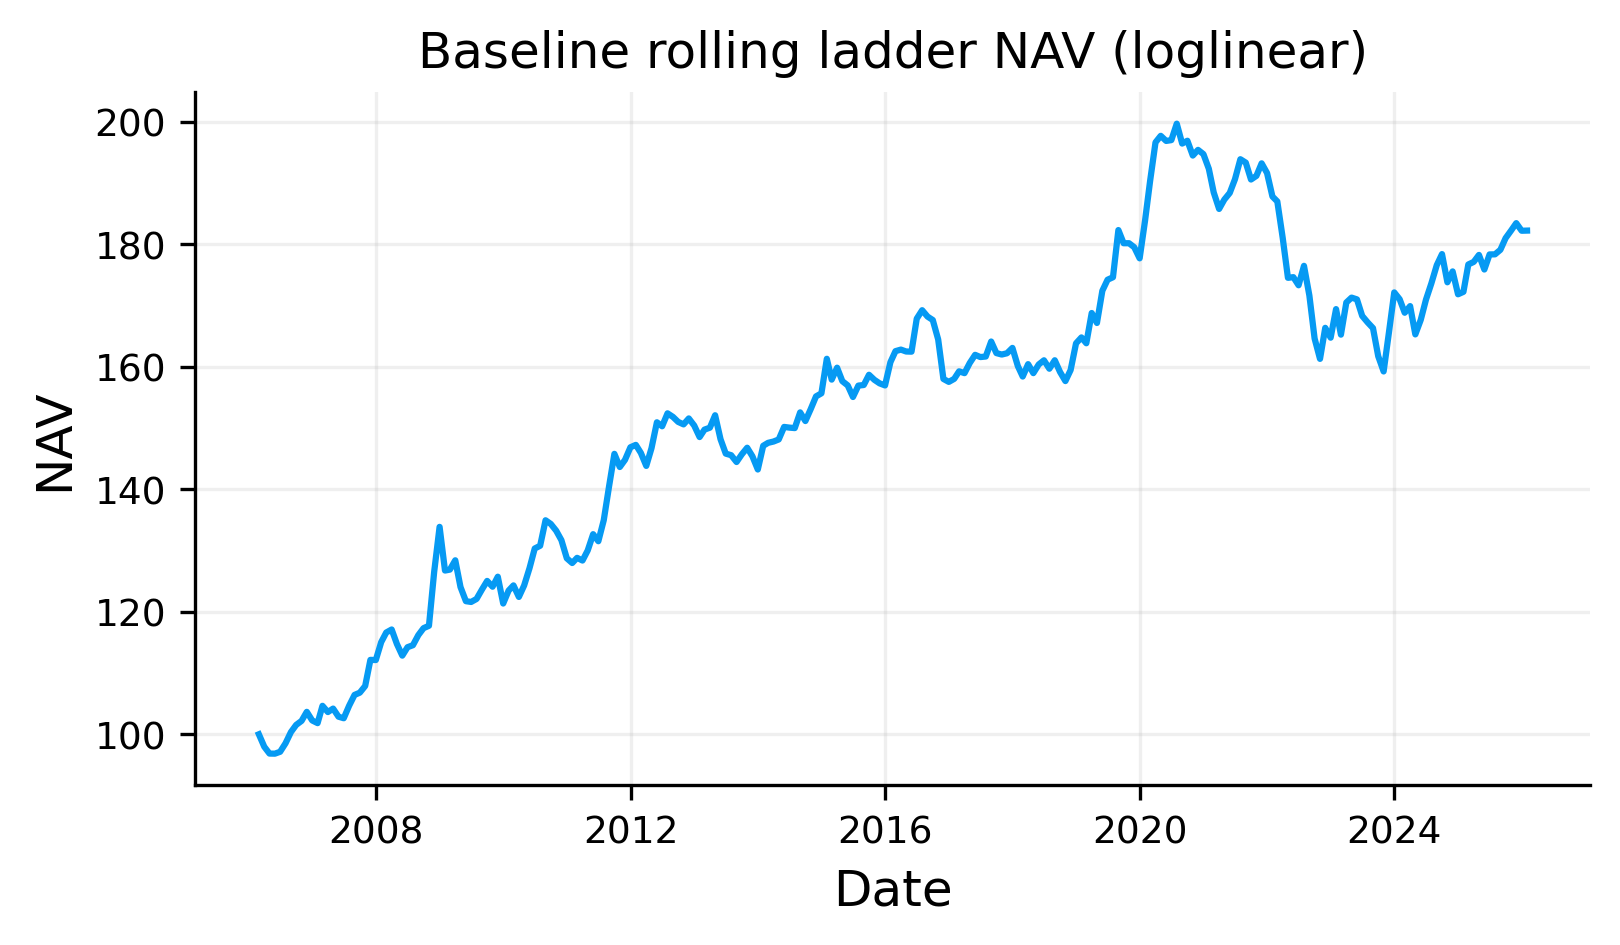

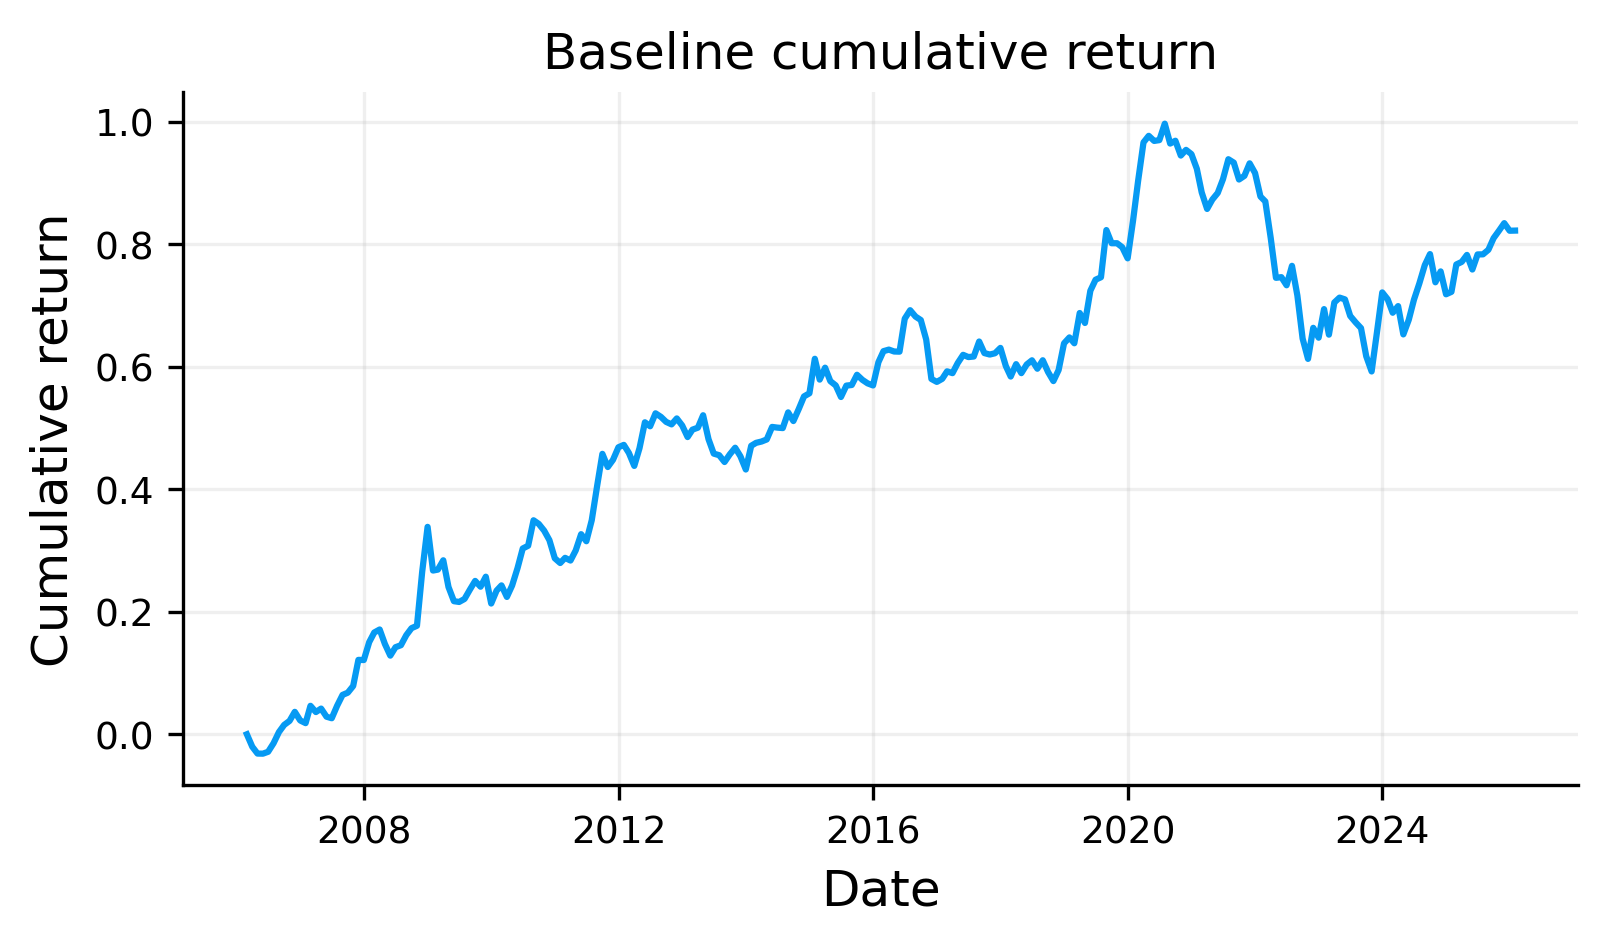

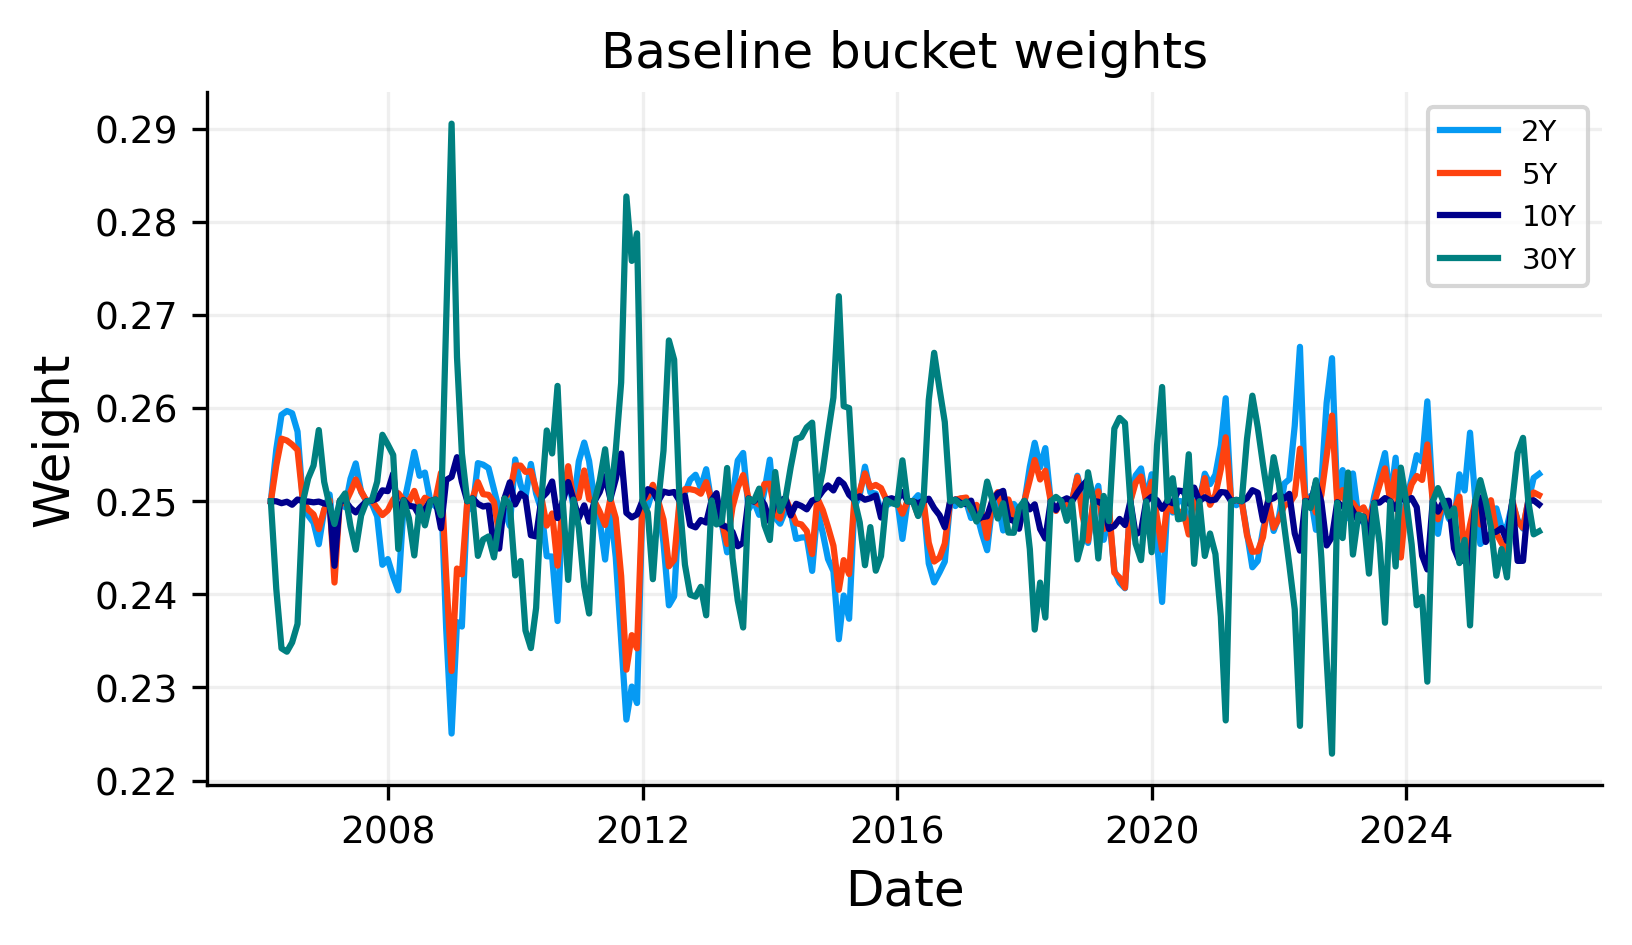

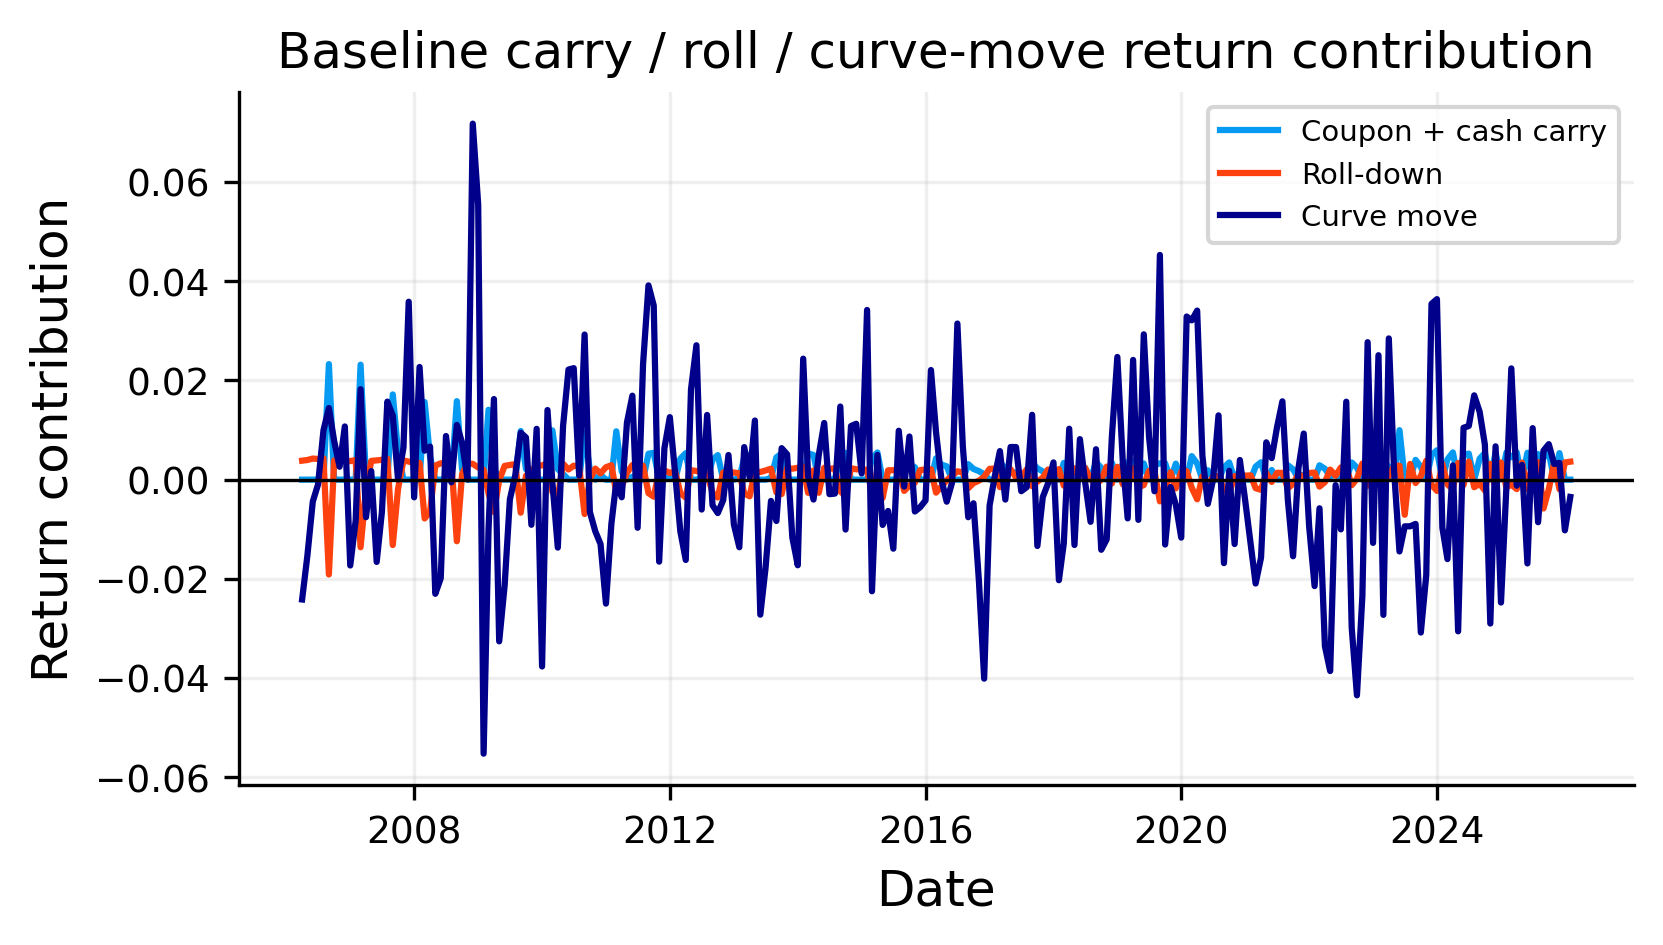

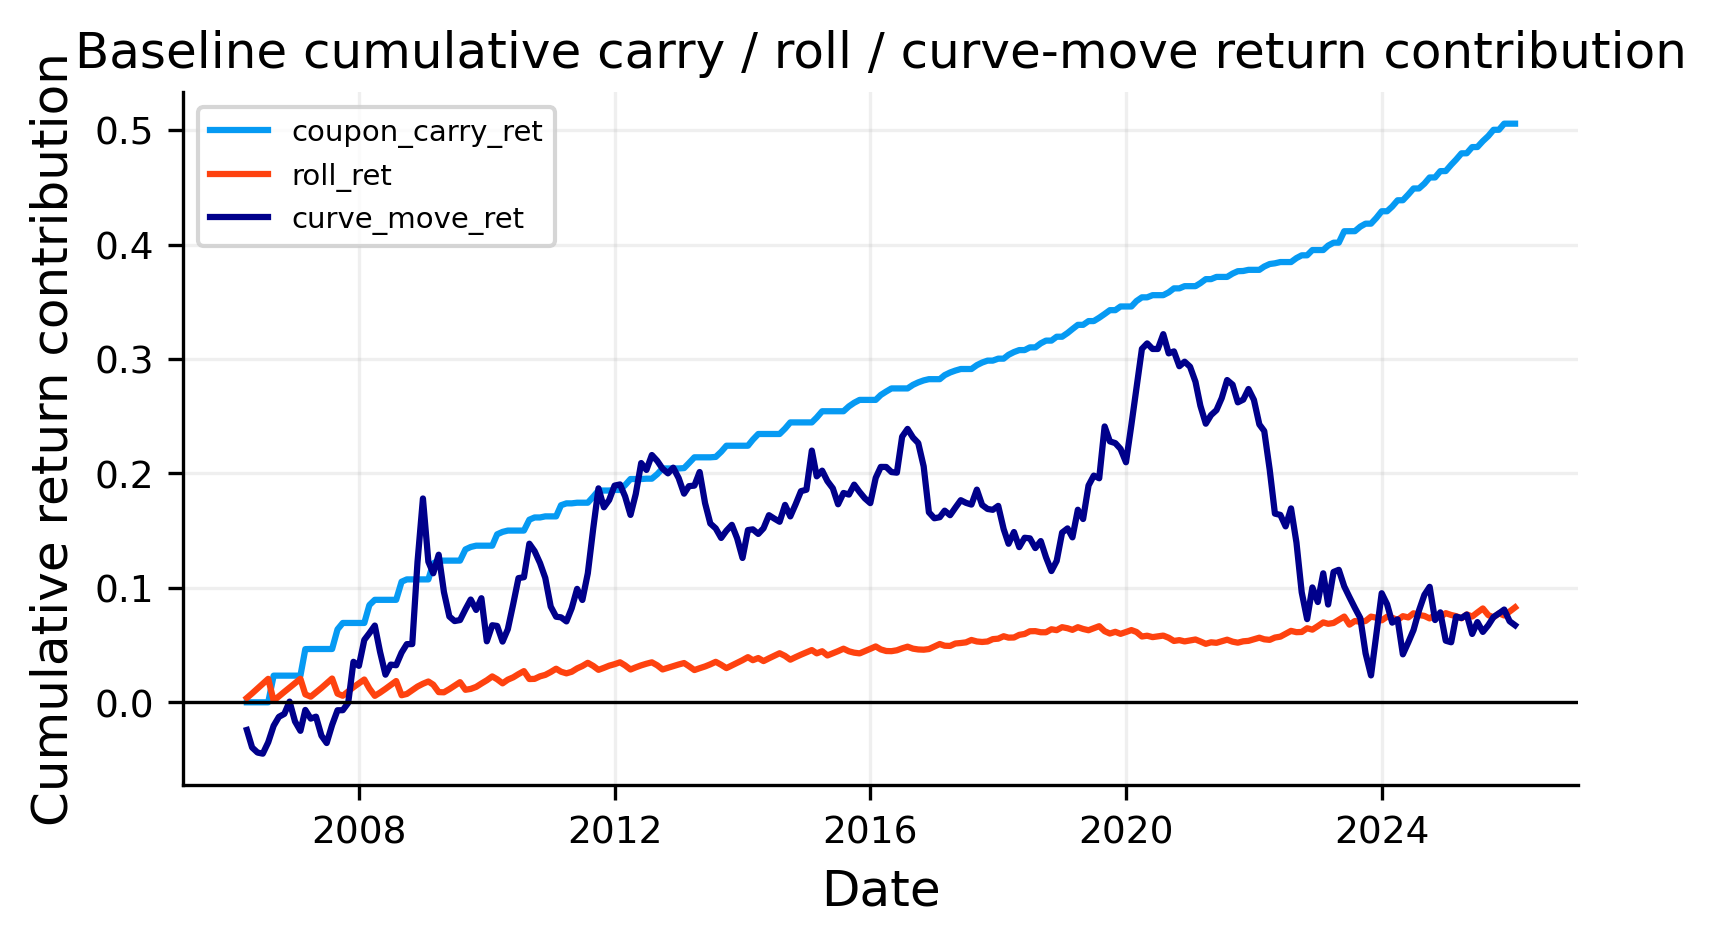

In [16]:
def strategy_summary_table(strategy_df):
    rets = strategy_df["ret"].dropna()
    if len(rets) == 0:
        return pd.DataFrame()

    wealth = (1.0 + rets).cumprod()
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1.0

    ann_return = wealth.iloc[-1] ** (12.0 / len(rets)) - 1.0
    ann_vol = rets.std(ddof=1) * np.sqrt(12.0) if len(rets) > 1 else np.nan
    max_dd = drawdown.min()

    return pd.DataFrame([{
        "final_nav": strategy_df["nav"].iloc[-1],
        "annualized_return": ann_return,
        "annualized_vol": ann_vol,
        "max_drawdown": max_dd,
    }], index=[strategy_df["strategy"].iloc[0]])


baseline_df, baseline_bucket_df, baseline_trades_df, baseline_carry_df, baseline_snapshots = run_ladder_strategy(
    strategy_name="baseline_ladder",
    target_weights=target_weights,
    duration_target=None,
    duration_band=None,
)

print(f"Primary curve used below: {primary_curve_method}")
print("Baseline strategy summary:")
display(strategy_summary_table(baseline_df))

print("Last strategy rows:")
display(baseline_df.tail())

print("Recent trades:")
display(baseline_trades_df.tail(12))

baseline_weights = baseline_bucket_df.pivot(index="date", columns="maturity", values="weight").sort_index()
baseline_weights_plot = gap_safe_frame(baseline_weights)

baseline_nav_plot = gap_safe_frame(baseline_df[["nav"]])
baseline_cumret = (1.0 + baseline_df["ret"].fillna(0.0)).cumprod() - 1.0
baseline_cumret_plot = gap_safe_frame(baseline_cumret)

baseline_carry_ret_plot = gap_safe_frame(
    baseline_carry_df[["coupon_carry_ret", "roll_ret", "curve_move_ret"]]
)

baseline_carry_cum = baseline_carry_df[["coupon_carry_ret", "roll_ret", "curve_move_ret"]].fillna(0.0).cumsum()
baseline_carry_cum_plot = gap_safe_frame(baseline_carry_cum)

plt.figure()
plt.plot(baseline_nav_plot.index, baseline_nav_plot["nav"])
plt.title(f"Baseline rolling ladder NAV ({primary_curve_method})")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.show()

plt.figure()
plt.plot(baseline_cumret_plot.index, baseline_cumret_plot.values)
plt.title("Baseline cumulative return")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.show()

plt.figure()
for T in issue_maturities:
    plt.plot(baseline_weights_plot.index, baseline_weights_plot[T], label=f"{T}Y")
plt.title("Baseline bucket weights")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.legend()
plt.show()

plt.figure()
plt.plot(baseline_carry_ret_plot.index, baseline_carry_ret_plot["coupon_carry_ret"], label="Coupon + cash carry")
plt.plot(baseline_carry_ret_plot.index, baseline_carry_ret_plot["roll_ret"], label="Roll-down")
plt.plot(baseline_carry_ret_plot.index, baseline_carry_ret_plot["curve_move_ret"], label="Curve move")
plt.axhline(0.0, color="black", linewidth=0.8)
plt.title("Baseline carry / roll / curve-move return contribution")
plt.xlabel("Date")
plt.ylabel("Return contribution")
plt.legend()
plt.show()

plt.figure()
for col in baseline_carry_cum_plot.columns:
    plt.plot(baseline_carry_cum_plot.index, baseline_carry_cum_plot[col], label=col)
plt.axhline(0.0, color="black", linewidth=0.8)
plt.title("Baseline cumulative carry / roll / curve-move return contribution")
plt.xlabel("Date")
plt.ylabel("Cumulative return contribution")
plt.legend()
plt.show()

## 13) Risk and sensitivity measures of bonds

### 13.1 PV01/ DV01
for measuring the risk of these bonds, we can use the sensitivity of the **price of bond** to a little change in interest rates.

PV01 is the change in PV of the bond when the curve bumps by 1 basis point.
DV01 is the value in dollar unit of that which is kind of the same concept

$$\dfrac{dP}{dy}=-\sum_{i=1}^n CF_i,t_i,D(t_i)$$

For approximation, we take $\Delta=0.0001$ (1 basis point move), Parallel-shifted discount factor will be:

$$D^{up}(t)=\exp(-(z(t)+\Delta)t)$$

PV01 will be:

$$PV01=P_0-P_{up}$$






### 13.2 Convexity

convexity is basically the sensitivity of **PV01** to a little change in curve. and it's the second order partial derivative of price from yield

$$\dfrac{d^2P}{dy^2}=\sum_{i=1}^n CF_i,t_i^2,D(t_i)$$

Using central differences with shift size $\Delta$:

$$Conv=\dfrac{P_{down}+P_{up}-2P_0}{P_0\Delta^2}$$

where
$P_{up}$ uses $+\Delta$ and $P_{down}$ uses $-\Delta$.

---

### 13.3 Key Rate Duration (KRD)

the problem is that we assume that yields parallel shift. but they can twist. if 2Y goes up it doesn't mean 10Y will go up exactly the same amount. (Duration is a normalized version of PV01)

So we choose key tenors $k_1<k_2<\dots<k_m$. as our key rates and measure the sensitivity of them while the other tenors in the curve stay the same.

Tent / triangular bump shape

Define localized bump functions $b_j(t)$ such that $b_j(K_j)=1$ and $b_j(t)=0$ outside a neighborhood.

A triangular bump with edges $L_j<R_j$:

$b_j(t)=0$ for $t\le L_j$

$b_j(t)=\dfrac{t-L_j}{K_j-L_j}$ for $L_j<t\le K_j$  

$b_j(t)=\dfrac{R_j-t}{R_j-K_j}$ for $K_j<t\le R_j$  

$b_j(t)=0$ for $t>R_j$


Bumped zero curve (only around key $k_j$):

$$z^{(j)}(t)=z(t)+\Delta b_j(t)$$

So bumped discount factors:


$$D^{(j)}(t)=\exp(-(z(t)+\Delta b_j(t))t)$$

Price under the key bump:

$$P^{(j)}(\Delta)=\sum_{i=1}^n CF_i,D(t_i),e^{-\Delta,b_j(t_i),t_i}$$

KRD definition (finite-difference)

$$KRD_j=\dfrac{P_0-P^{(j)}}{P_0\Delta}$$


---


Baseline risk summary:


,pv01,modified_duration,effective_duration,convexity
date,,,,
2025-09-30,0.121968,6.638165,6.737480,85.036803
2025-10-31,0.121810,6.584971,6.683788,84.566819
2025-11-30,0.126783,6.813048,6.910113,84.814958
2025-12-31,0.123132,6.660231,6.756776,82.182537
2026-01-31,0.121644,6.573155,6.674283,81.160590


Baseline KRD on the last date:


,key,krd,key_rate_pv01
956,2,0.543016,0.009897
957,5,1.402075,0.025554
958,10,2.136849,0.038946
959,30,2.592342,0.047248


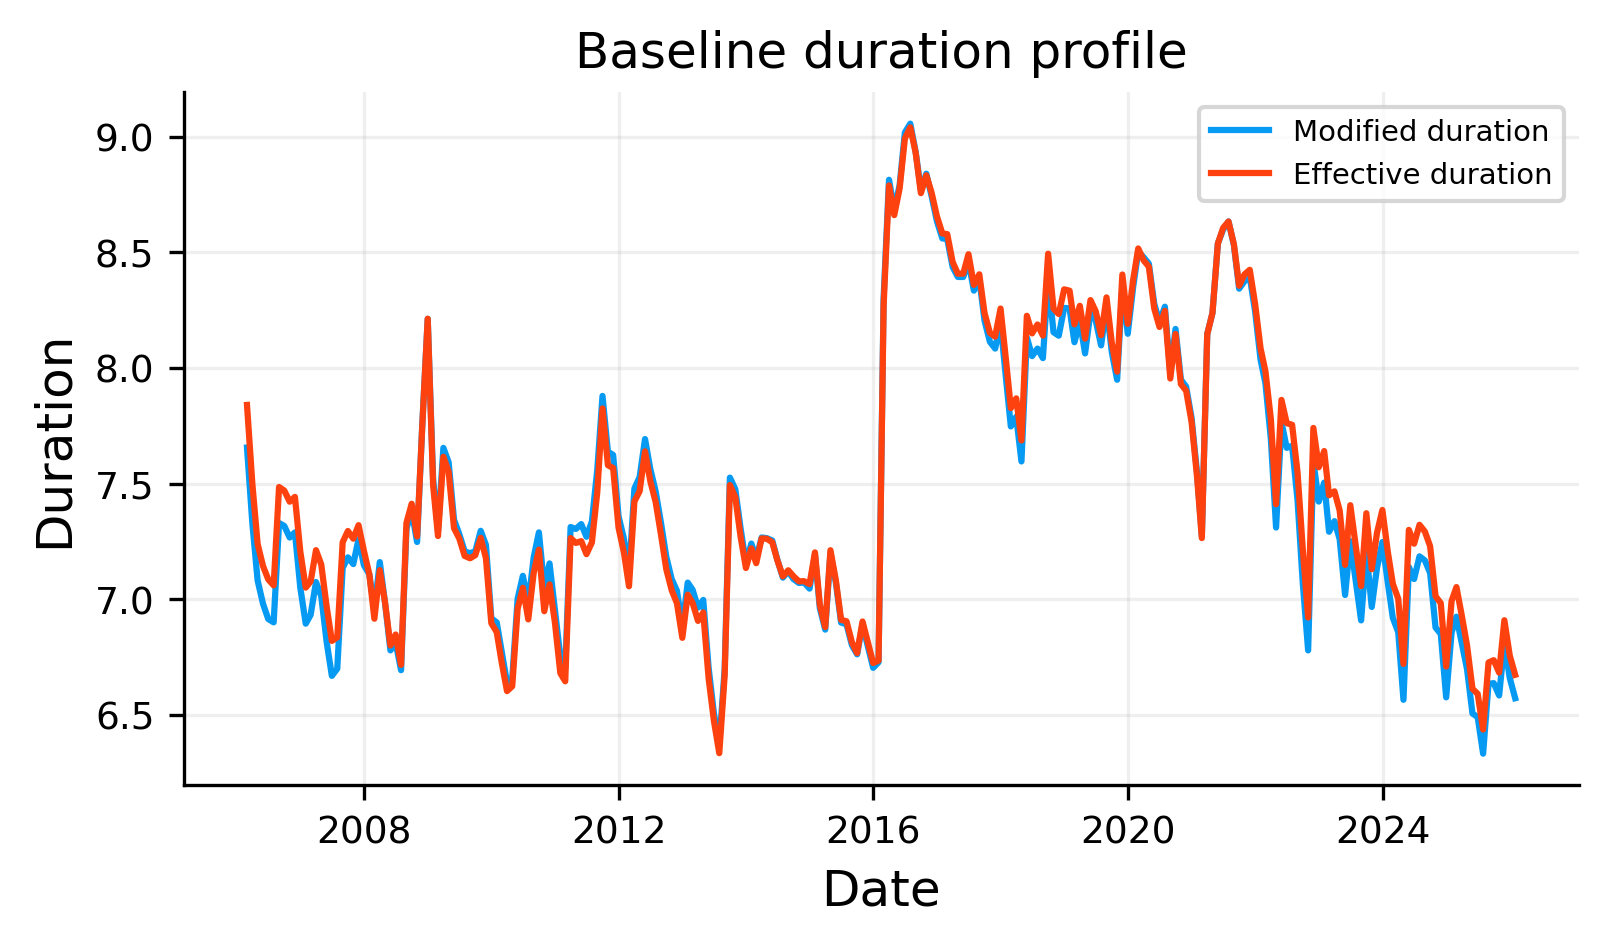

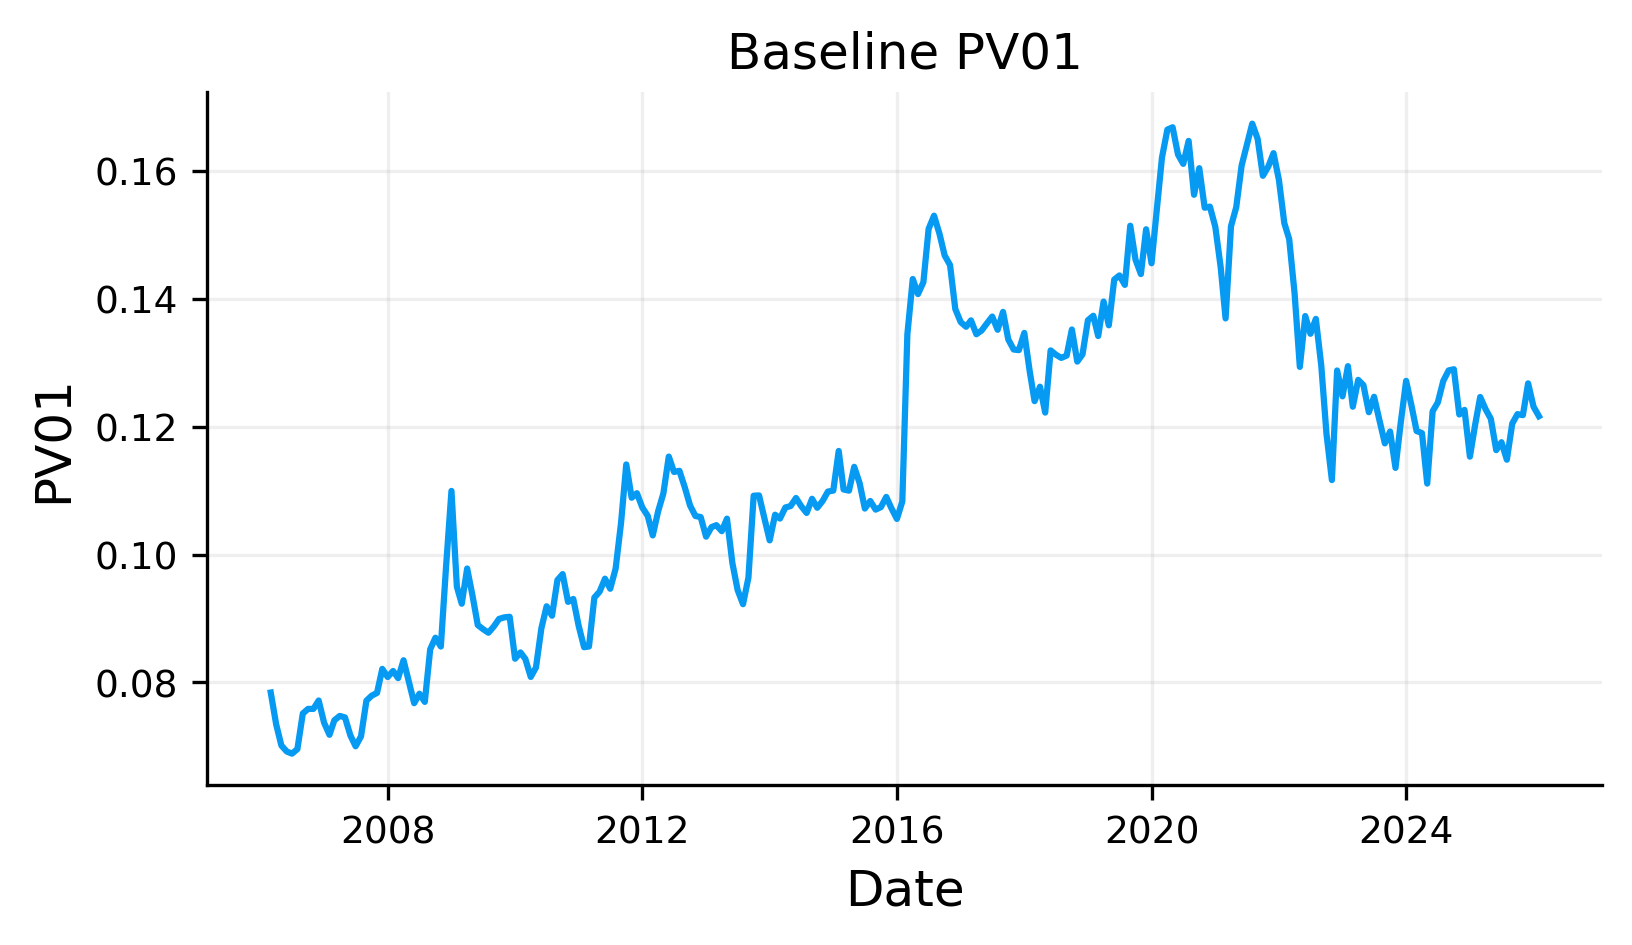

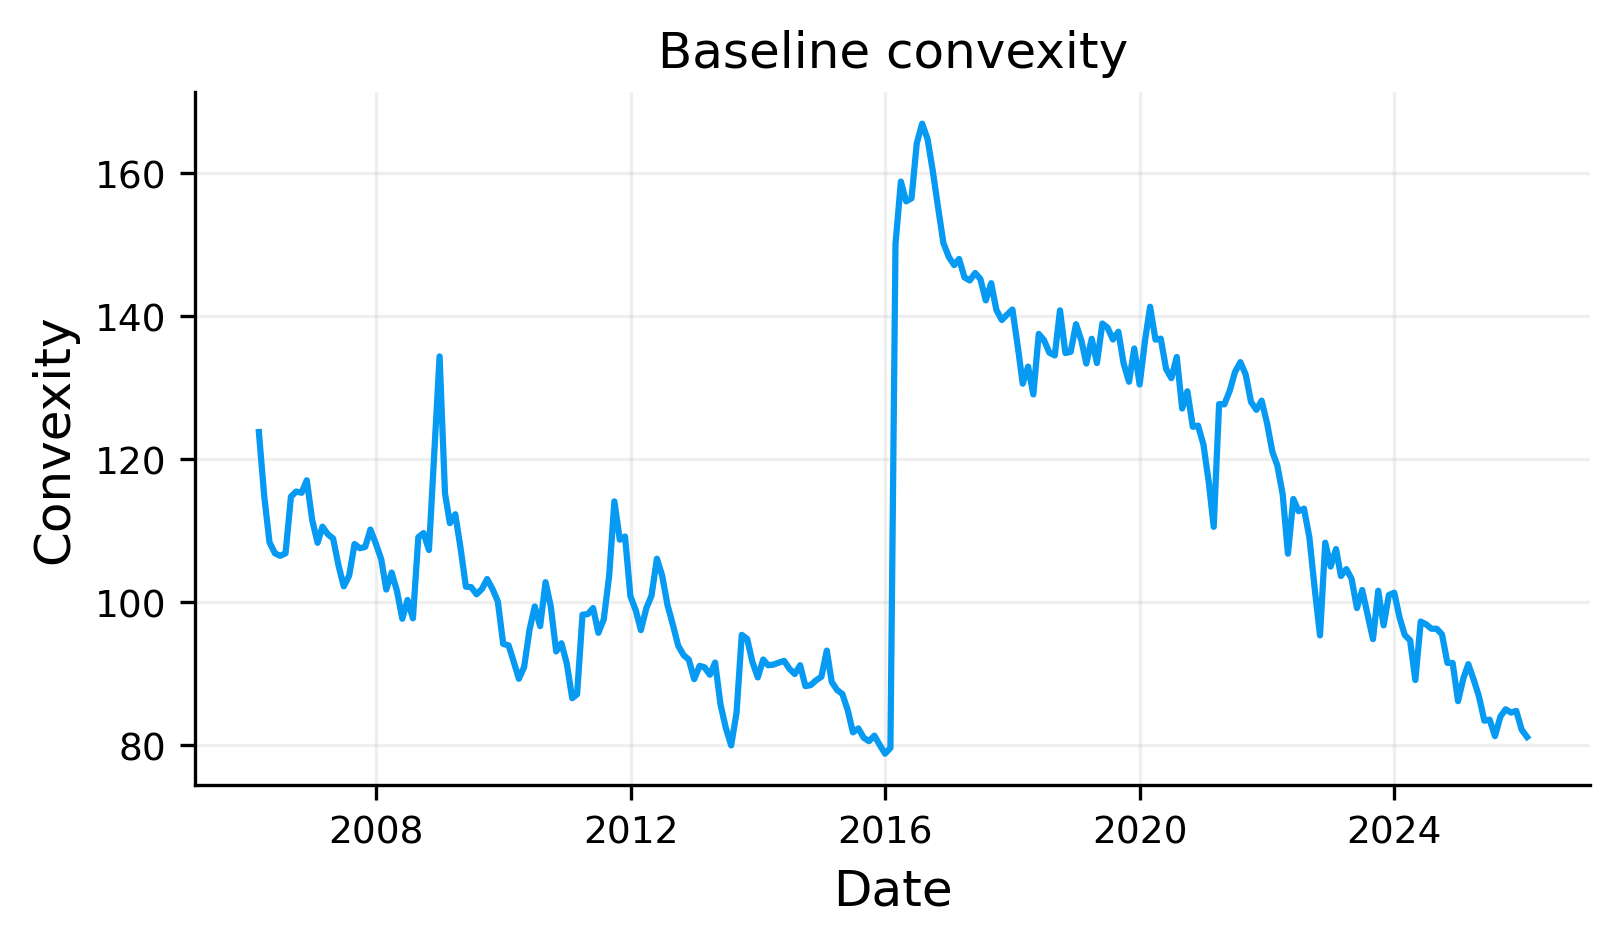

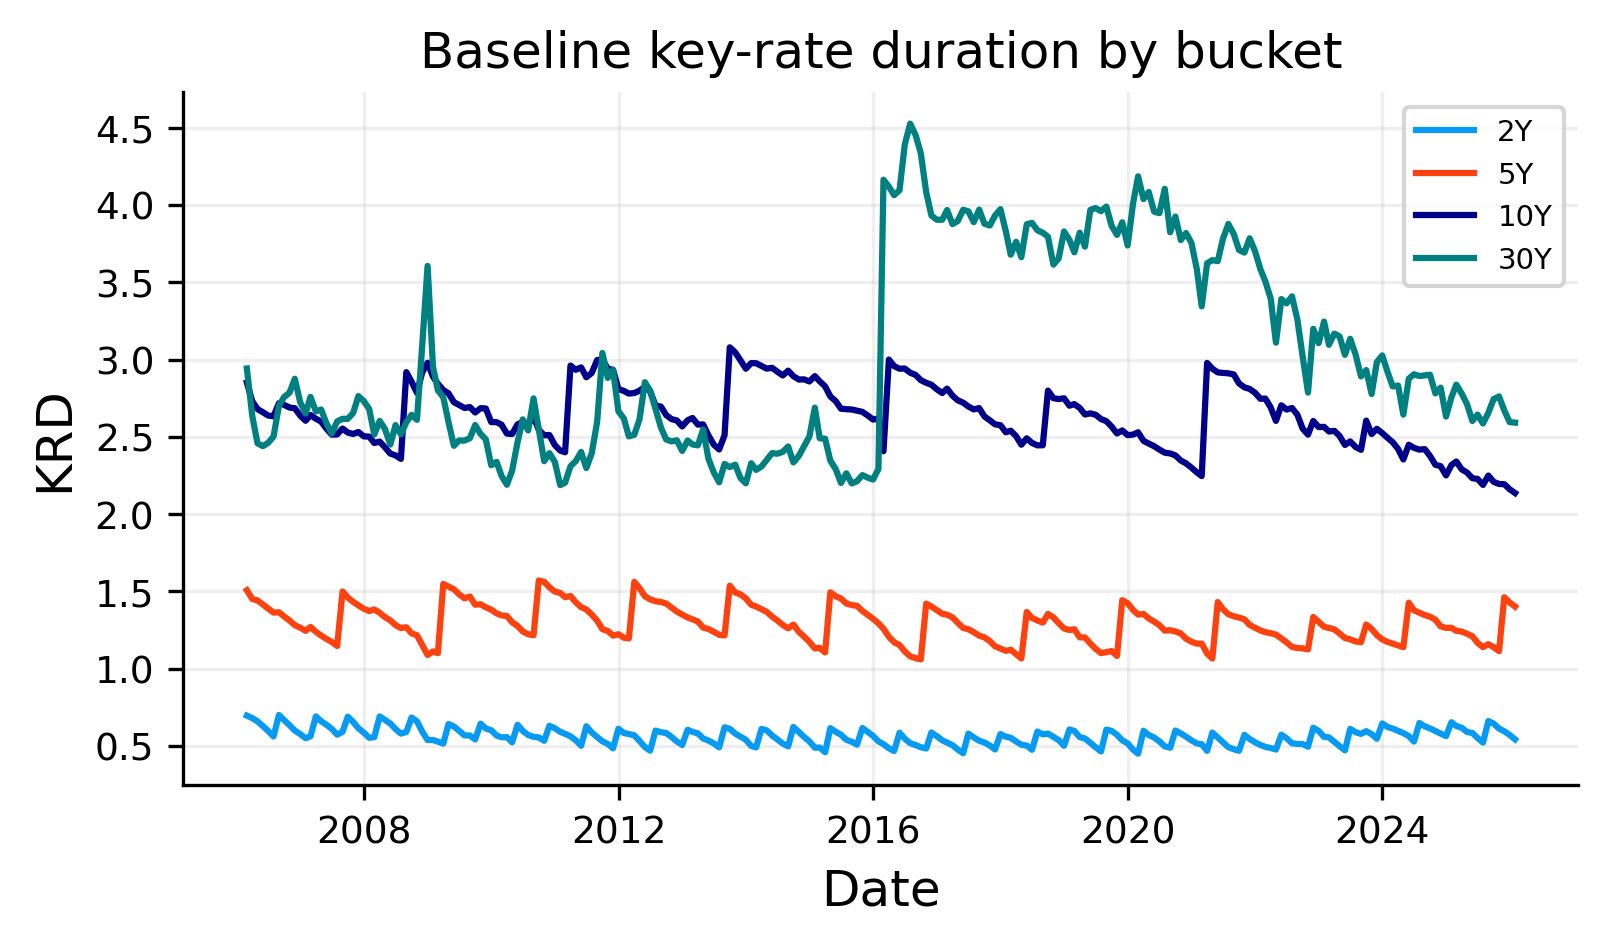

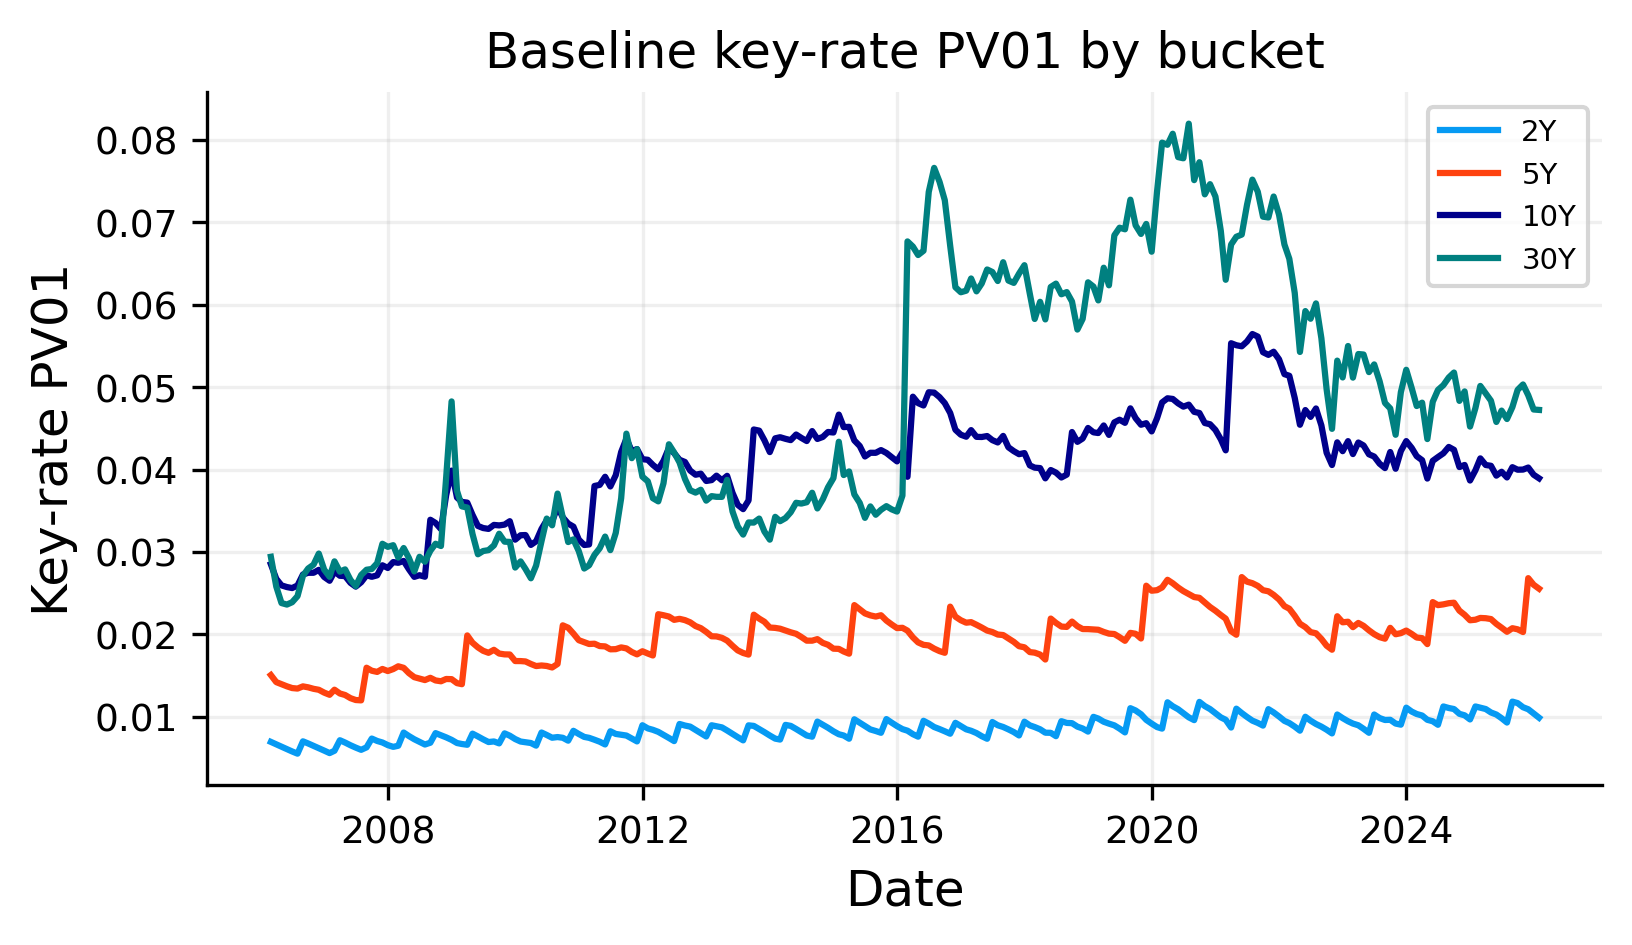

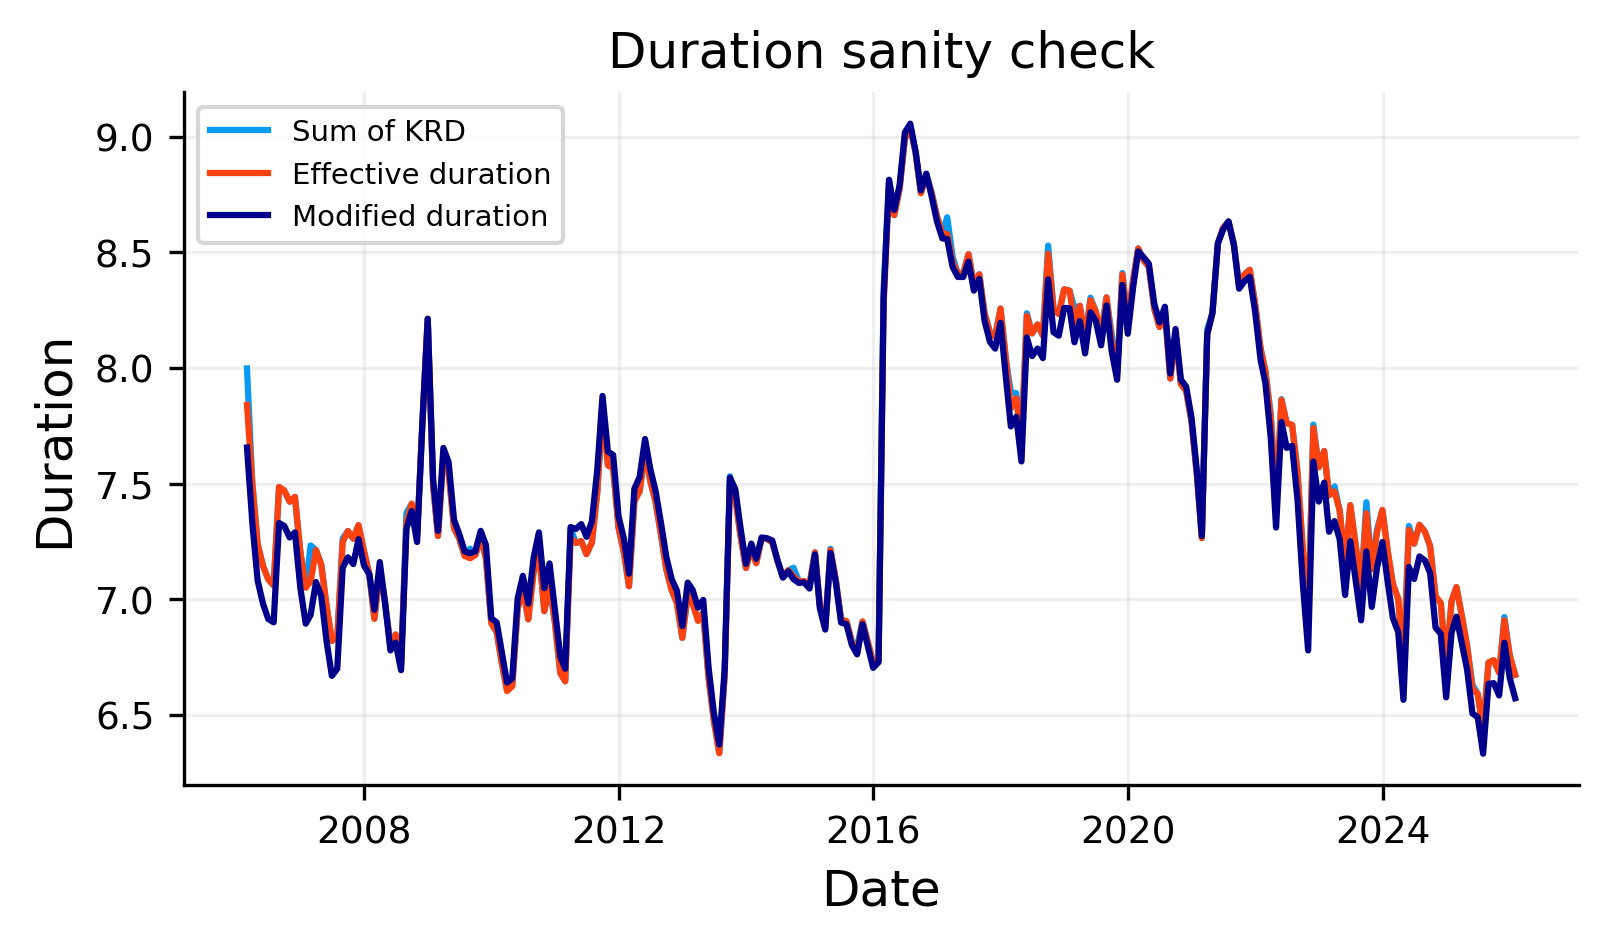

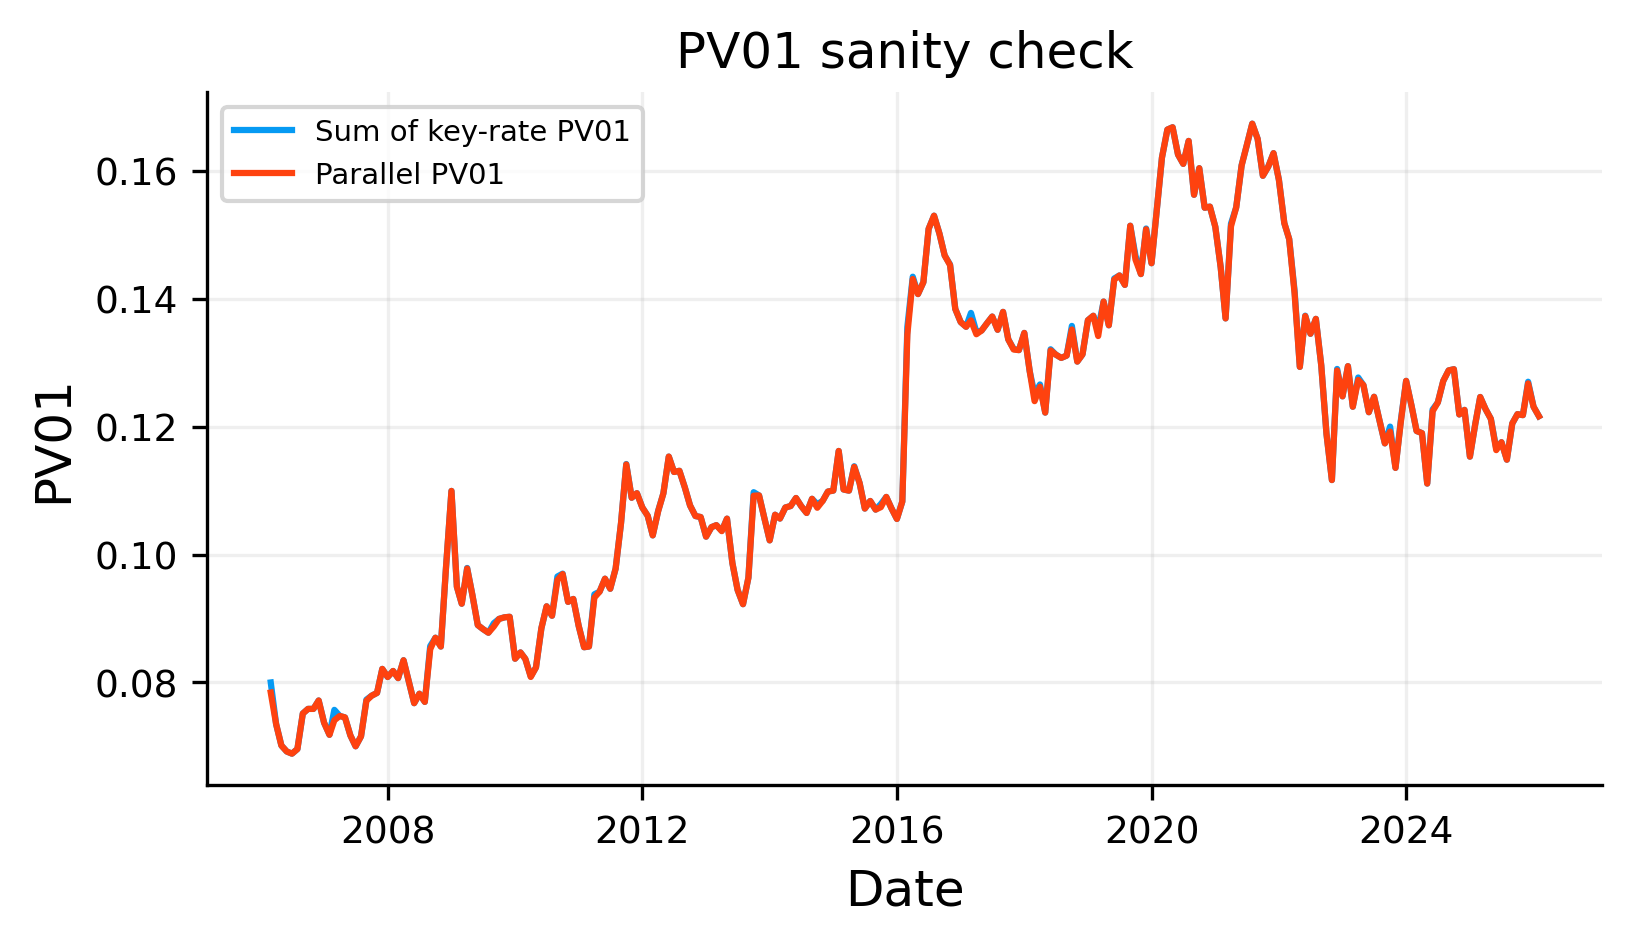

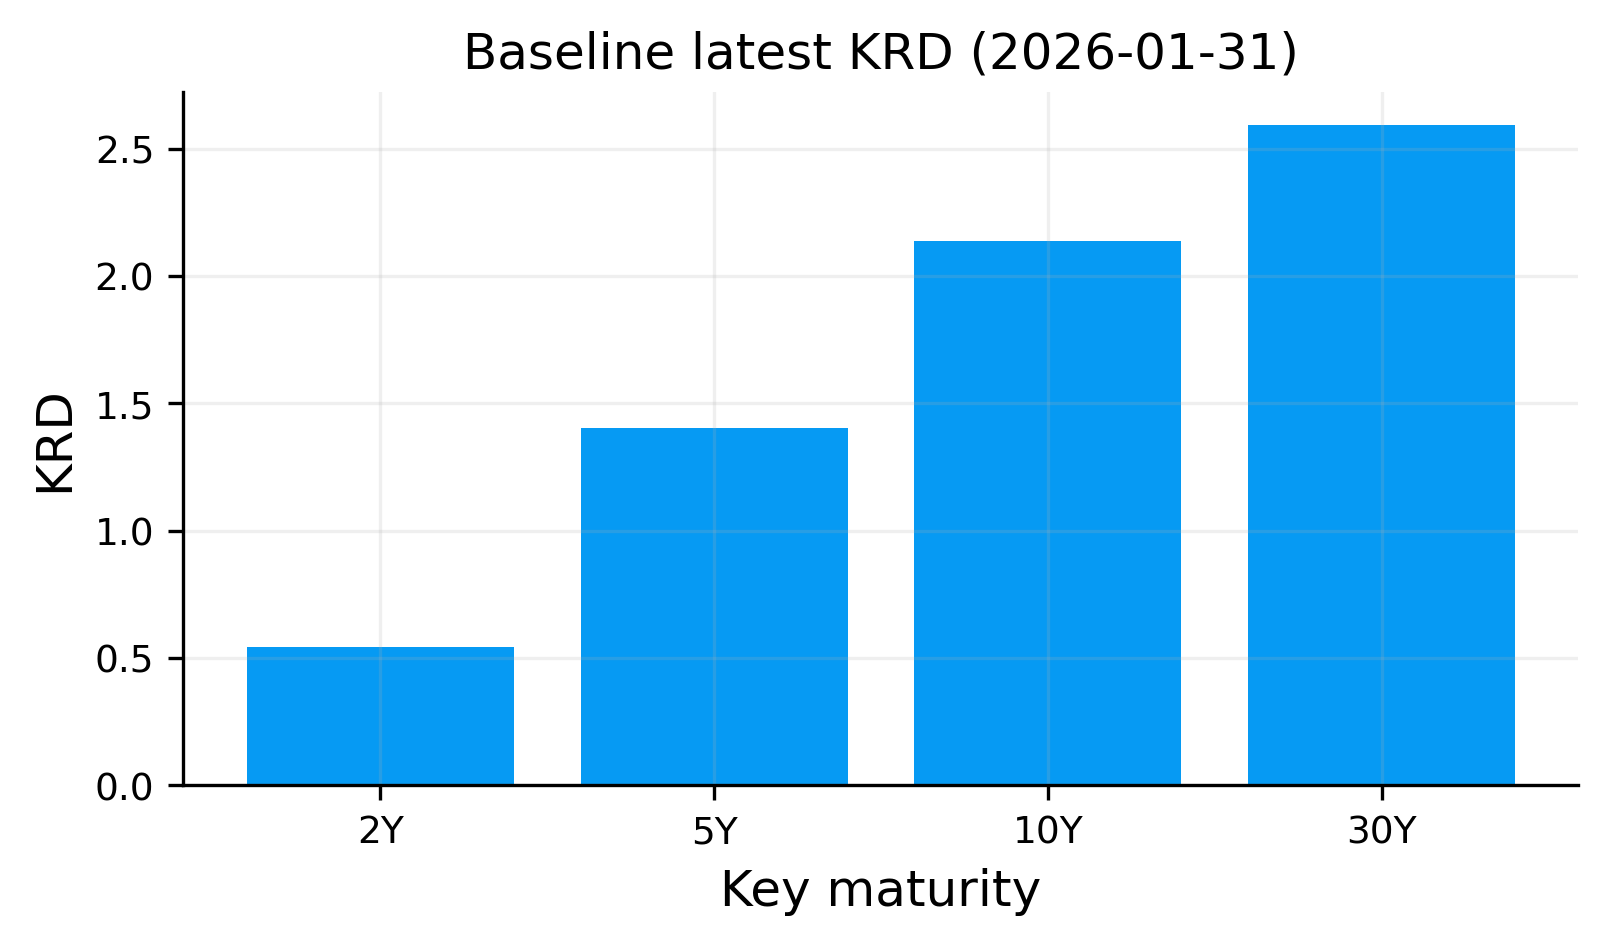

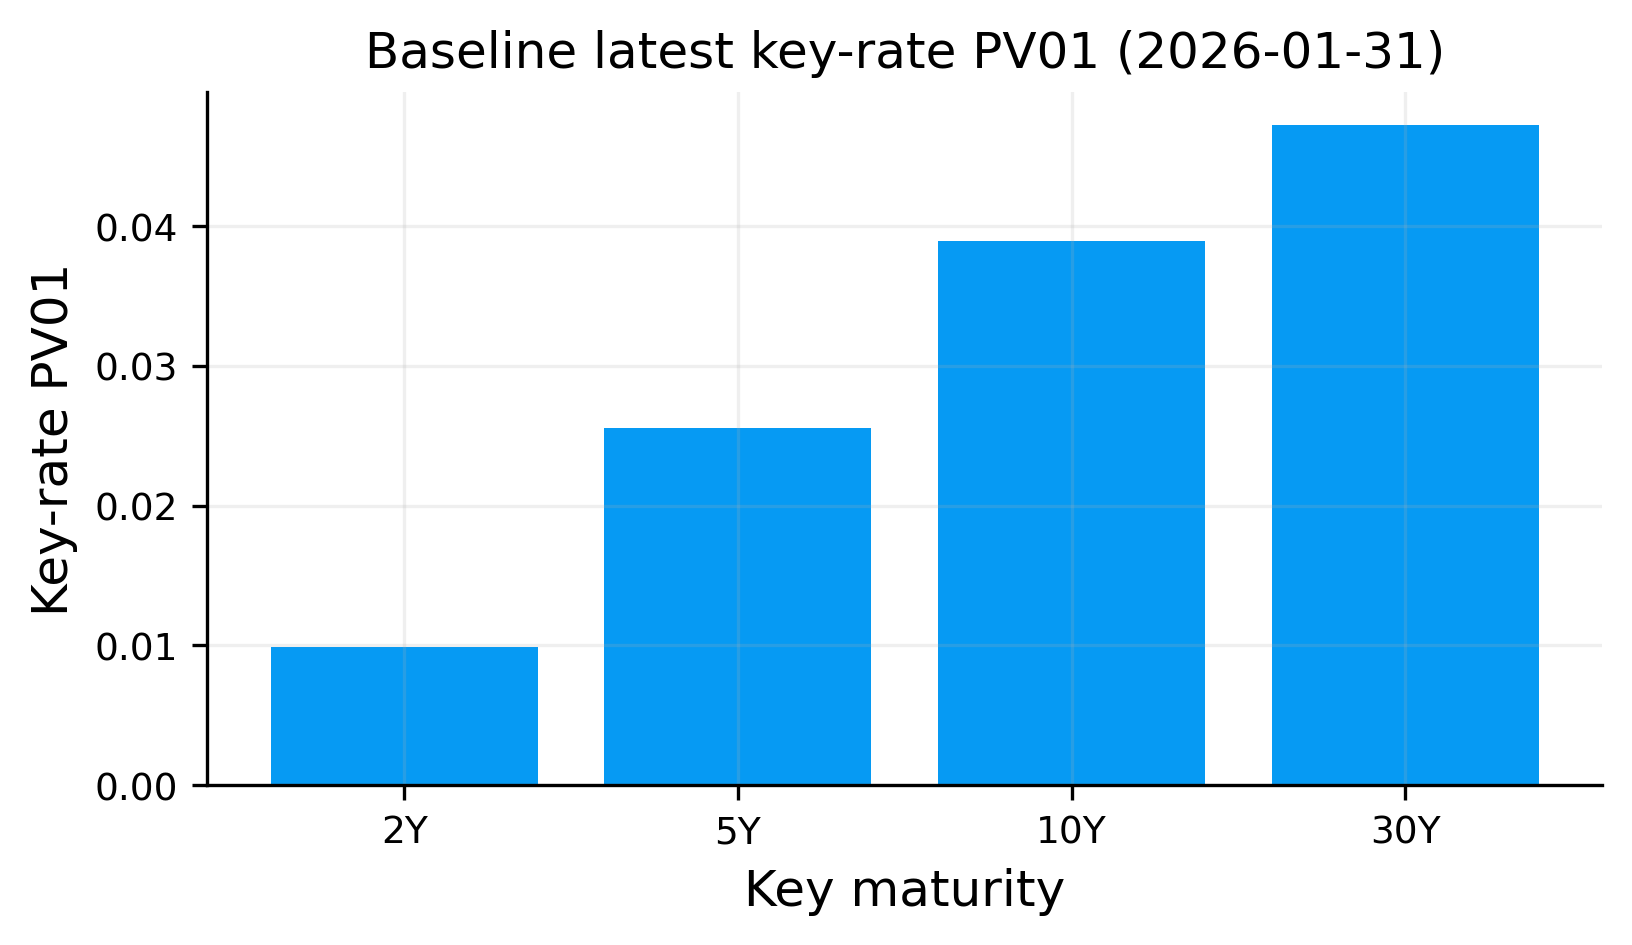

duration_target_ladder: using contiguous block 2006-02-28 -> 2026-01-31 (240 dates)
Strategy comparison summary:


,final_nav,annualized_return,annualized_vol,max_drawdown
baseline_ladder,182.258234,0.030596,0.060663,-0.202618
duration_target_ladder,169.126730,0.026734,0.040731,-0.135296


Duration-target strategy risk summary:


,pv01,modified_duration,effective_duration,convexity
date,,,,
2025-09-30,0.083507,4.900694,4.980669,48.421179
2025-10-31,0.083955,4.901447,4.981061,49.324957
2025-11-30,0.084502,4.903033,4.980832,45.880551
2025-12-31,0.084242,4.903146,4.981674,46.752495
2026-01-31,0.084225,4.898487,4.980011,47.586177


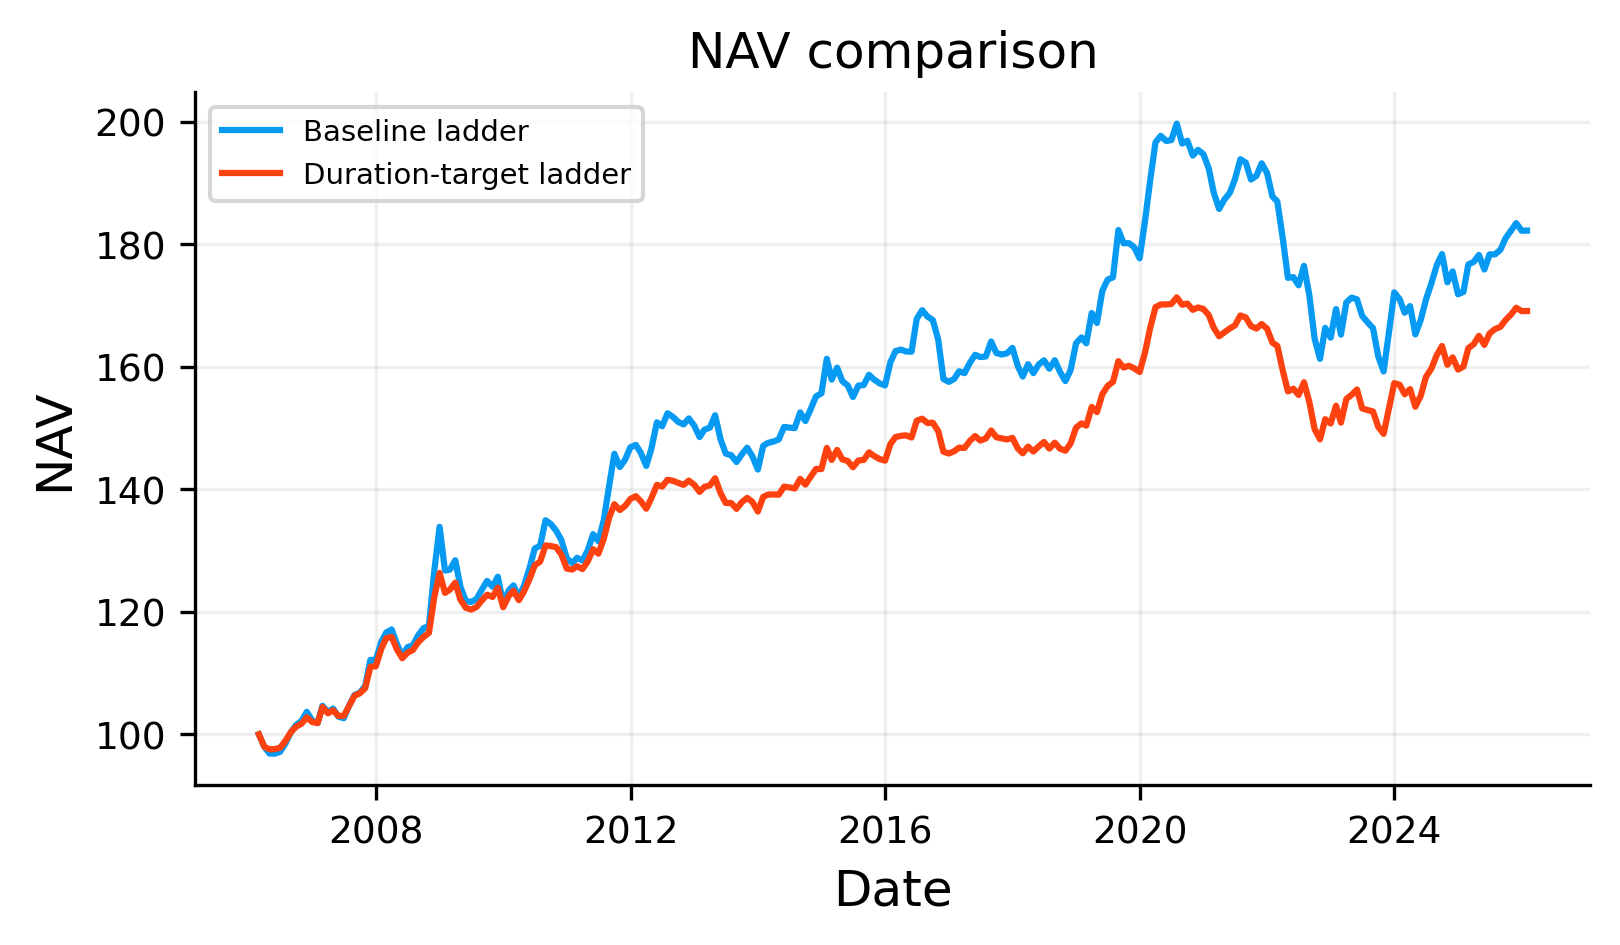

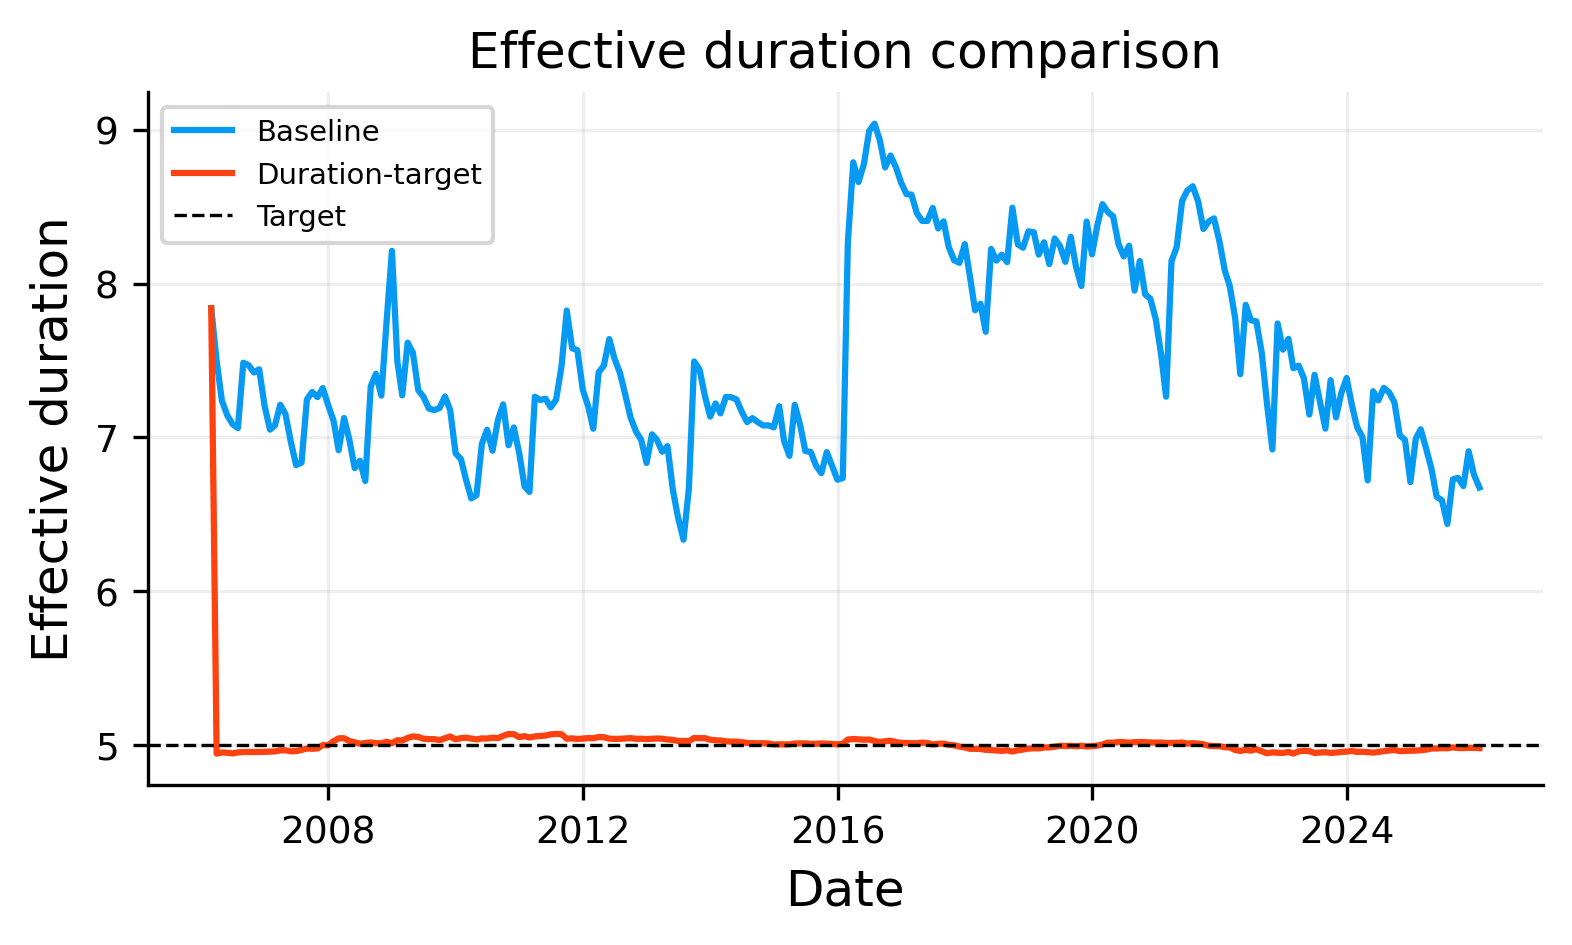

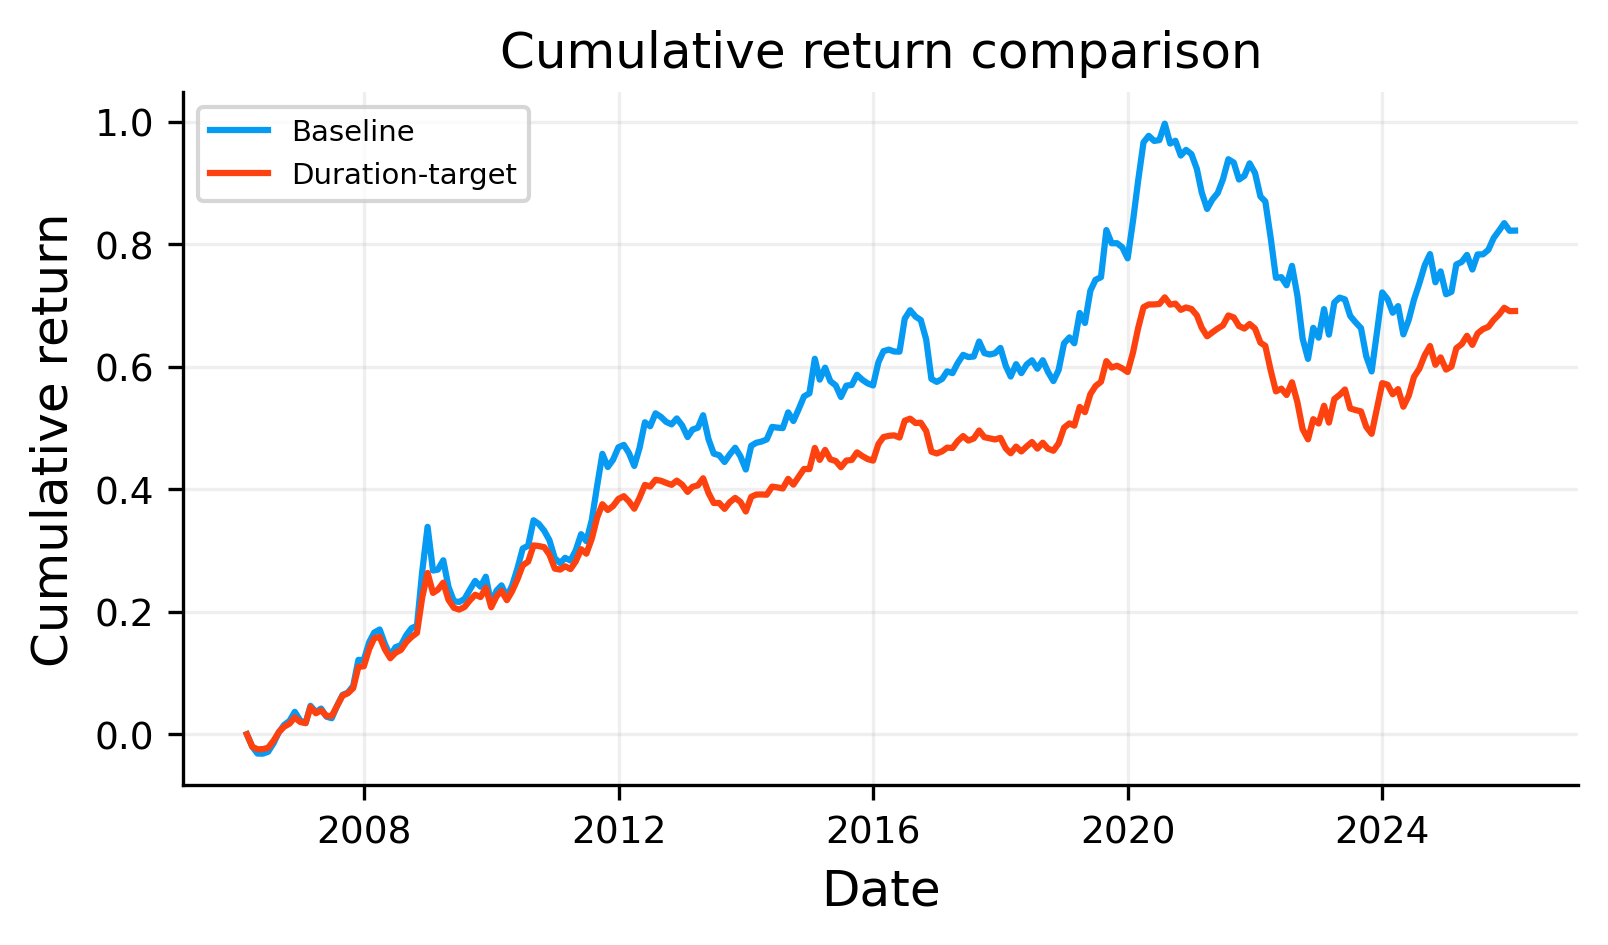

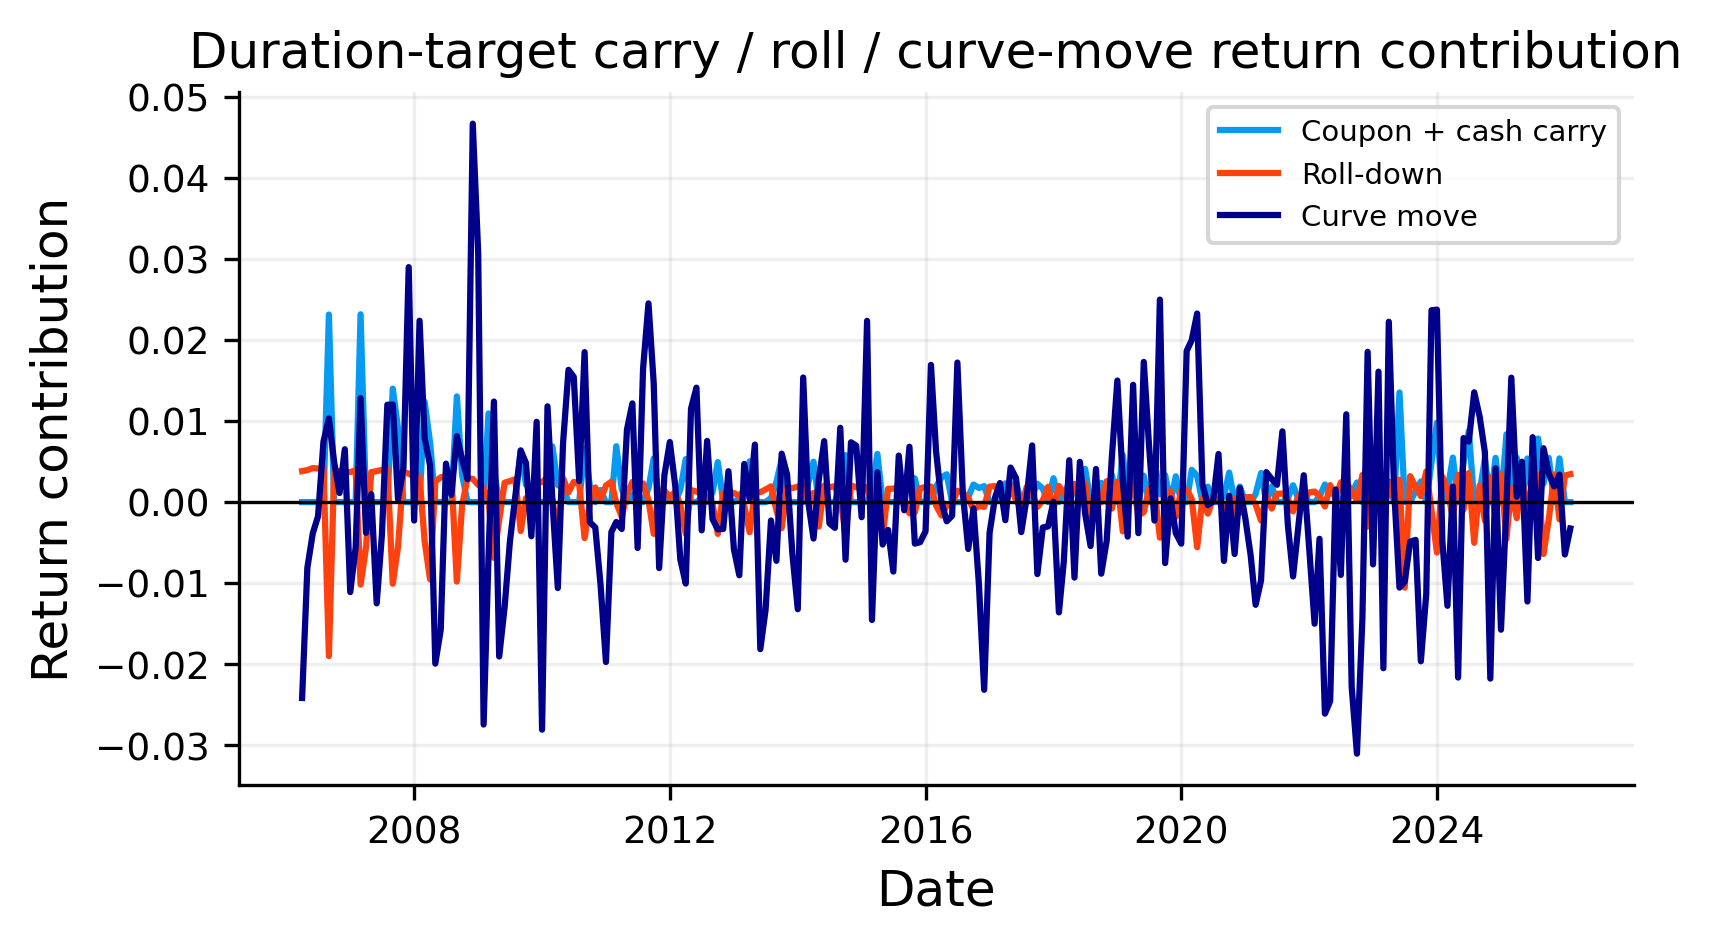

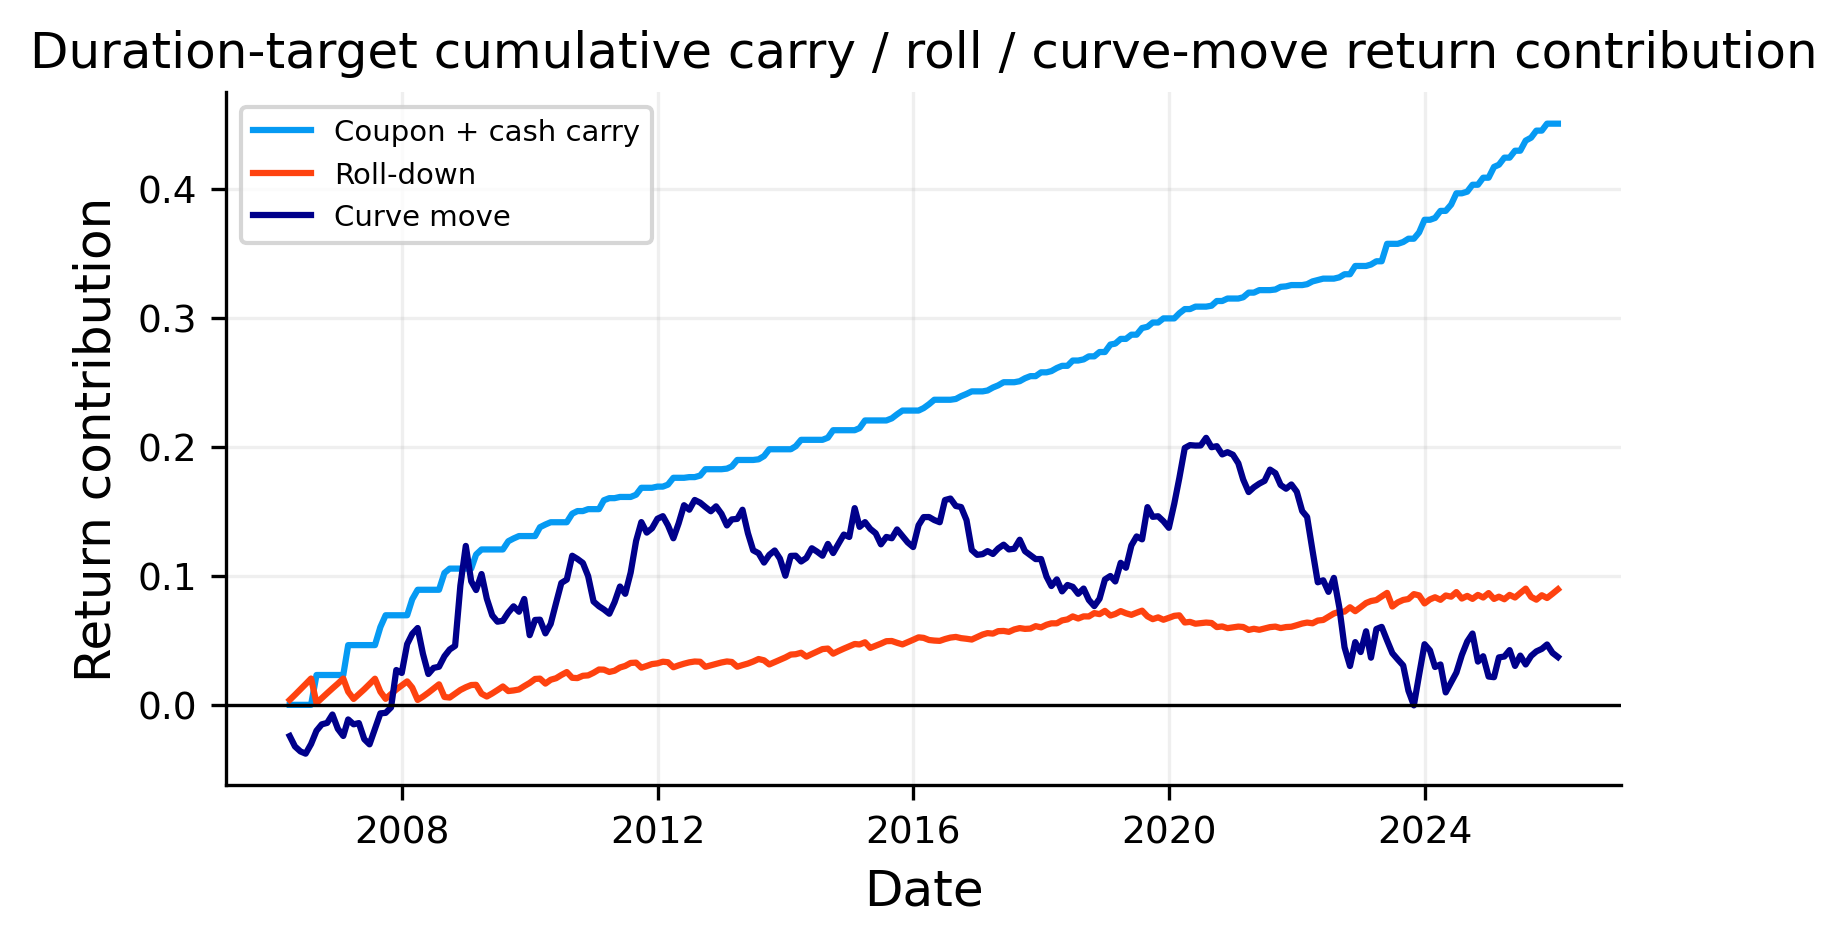

In [ ]:
def strategy_risk_timeseries(strategy_df, snapshots):
    risk_rows = []
    krd_rows = []

    for date in strategy_df.index:
        curve = get_primary_curve_for(curve_date_for(date))
        if curve is None or date not in snapshots:
            continue

        df_func = curve["df_func"]
        positions = clone_positions(snapshots[date]["positions"])
        cash = float(snapshots[date]["cash"])

        parallel = portfolio_parallel_risk(positions, cash, date, df_func, bump_bp=1.0)
        mod_dur = portfolio_modified_duration(positions, cash, date, df_func, bump_bp=1.0)

        risk_rows.append({
            "date": date,
            "strategy": strategy_df.loc[date, "strategy"],
            "nav": strategy_df.loc[date, "nav"],
            "pv01": parallel["pv01"],
            "modified_duration": mod_dur,
            "effective_duration": parallel["effective_duration"],
            "convexity": parallel["convexity"],
        })

        krd_tmp = portfolio_key_rate_risk(positions, cash, date, df_func, bump_bp=1.0)
        if len(krd_tmp) > 0:
            krd_tmp["date"] = date
            krd_tmp["strategy"] = strategy_df.loc[date, "strategy"]
            krd_rows.append(krd_tmp)

    risk_df = pd.DataFrame(risk_rows).set_index("date").sort_index()
    krd_df = pd.concat(krd_rows, axis=0, ignore_index=True) if len(krd_rows) > 0 else pd.DataFrame()
    return risk_df, krd_df


baseline_risk_df, baseline_krd_df = strategy_risk_timeseries(baseline_df, baseline_snapshots)
print("Baseline risk summary:")
display(baseline_risk_df[["pv01", "modified_duration", "effective_duration", "convexity"]].tail())

latest_krd = (
    baseline_krd_df[baseline_krd_df["date"] == baseline_krd_df["date"].max()]
    [["key", "krd", "key_rate_pv01"]]
    .sort_values("key"))

print("Baseline KRD on the last date:")
display(latest_krd)

baseline_risk_plot = gap_safe_frame(
    baseline_risk_df[["pv01", "modified_duration", "effective_duration", "convexity"]])

baseline_krd_pivot = (
    baseline_krd_df.pivot(index="date", columns="key", values="krd")
    .sort_index())
baseline_krd_pv01_pivot = (
    baseline_krd_df.pivot(index="date", columns="key", values="key_rate_pv01")
    .sort_index())

baseline_krd_plot = gap_safe_frame(baseline_krd_pivot)
baseline_krd_pv01_plot = gap_safe_frame(baseline_krd_pv01_pivot)

baseline_krd_sum = baseline_krd_pivot.sum(axis=1).reindex(baseline_risk_df.index)
baseline_krd_sum_plot = gap_safe_frame(
    pd.DataFrame({
        "krd_sum": baseline_krd_sum,
        "effective_duration": baseline_risk_df["effective_duration"],
        "modified_duration": baseline_risk_df["modified_duration"],
    })
)

baseline_pv01_sum = baseline_krd_pv01_pivot.sum(axis=1).reindex(baseline_risk_df.index)
baseline_pv01_sum_plot = gap_safe_frame(
    pd.DataFrame({
        "key_rate_pv01_sum": baseline_pv01_sum,
        "pv01": baseline_risk_df["pv01"],
    })
)

plt.figure()
plt.plot(baseline_risk_plot.index, baseline_risk_plot["modified_duration"], label="Modified duration")
plt.plot(baseline_risk_plot.index, baseline_risk_plot["effective_duration"], label="Effective duration")
plt.title("Baseline duration profile")
plt.xlabel("Date")
plt.ylabel("Duration")
plt.legend()
plt.show()

plt.figure()
plt.plot(baseline_risk_plot.index, baseline_risk_plot["pv01"])
plt.title("Baseline PV01")
plt.xlabel("Date")
plt.ylabel("PV01")
plt.show()

plt.figure()
plt.plot(baseline_risk_plot.index, baseline_risk_plot["convexity"])
plt.title("Baseline convexity")
plt.xlabel("Date")
plt.ylabel("Convexity")
plt.show()

plt.figure()
for key in baseline_krd_plot.columns:
    plt.plot(baseline_krd_plot.index, baseline_krd_plot[key], label=f"{int(key)}Y")
plt.title("Baseline key-rate duration by bucket")
plt.xlabel("Date")
plt.ylabel("KRD")
plt.legend()
plt.show()

plt.figure()
for key in baseline_krd_pv01_plot.columns:
    plt.plot(baseline_krd_pv01_plot.index, baseline_krd_pv01_plot[key], label=f"{int(key)}Y")
plt.title("Baseline key-rate PV01 by bucket")
plt.xlabel("Date")
plt.ylabel("Key-rate PV01")
plt.legend()
plt.show()

plt.figure()
plt.plot(baseline_krd_sum_plot.index, baseline_krd_sum_plot["krd_sum"], label="Sum of KRD")
plt.plot(baseline_krd_sum_plot.index, baseline_krd_sum_plot["effective_duration"], label="Effective duration")
plt.plot(baseline_krd_sum_plot.index, baseline_krd_sum_plot["modified_duration"], label="Modified duration")
plt.title("Duration sanity check")
plt.xlabel("Date")
plt.ylabel("Duration")
plt.legend()
plt.show()

plt.figure()
plt.plot(baseline_pv01_sum_plot.index, baseline_pv01_sum_plot["key_rate_pv01_sum"], label="Sum of key-rate PV01")
plt.plot(baseline_pv01_sum_plot.index, baseline_pv01_sum_plot["pv01"], label="Parallel PV01")
plt.title("PV01 sanity check")
plt.xlabel("Date")
plt.ylabel("PV01")
plt.legend()
plt.show()

latest_date = baseline_krd_df["date"].max()
latest_krd_bar = (
    baseline_krd_df[baseline_krd_df["date"] == latest_date]
    .sort_values("key")
    .set_index("key")
)

plt.figure()
plt.bar([str(int(k)) + "Y" for k in latest_krd_bar.index], latest_krd_bar["krd"].values)
plt.title(f"Baseline latest KRD ({latest_date.date()})")
plt.xlabel("Key maturity")
plt.ylabel("KRD")
plt.show()

plt.figure()
plt.bar([str(int(k)) + "Y" for k in latest_krd_bar.index], latest_krd_bar["key_rate_pv01"].values)
plt.title(f"Baseline latest key-rate PV01 ({latest_date.date()})")
plt.xlabel("Key maturity")
plt.ylabel("Key-rate PV01")
plt.show()


duration_df, duration_bucket_df, duration_trades_df, duration_carry_df, duration_snapshots = run_ladder_strategy(
    strategy_name="duration_target_ladder",
    target_weights=target_weights,
    duration_target=duration_target,
    duration_band=duration_band,
)

duration_risk_df, duration_krd_df = strategy_risk_timeseries(duration_df, duration_snapshots)

comparison_summary = pd.concat(
    [
        strategy_summary_table(baseline_df),
        strategy_summary_table(duration_df),
    ],
    axis=0,
)

print("Strategy comparison summary:")
display(comparison_summary)

print("Duration-target strategy risk summary:")
display(duration_risk_df[["pv01", "modified_duration", "effective_duration", "convexity"]].tail())

duration_risk_plot = gap_safe_frame(
    duration_risk_df[["pv01", "modified_duration", "effective_duration", "convexity"]]
)

duration_carry_ret_plot = gap_safe_frame(
    duration_carry_df[["coupon_carry_ret", "roll_ret", "curve_move_ret"]]
)

plt.figure()
plt.plot(gap_safe_frame(baseline_df[["nav"]]).index, gap_safe_frame(baseline_df[["nav"]])["nav"], label="Baseline ladder")
plt.plot(gap_safe_frame(duration_df[["nav"]]).index, gap_safe_frame(duration_df[["nav"]])["nav"], label="Duration-target ladder")
plt.title("NAV comparison")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.show()

plt.figure()
plt.plot(baseline_risk_plot.index, baseline_risk_plot["effective_duration"], label="Baseline")
plt.plot(duration_risk_plot.index, duration_risk_plot["effective_duration"], label="Duration-target")
plt.axhline(duration_target, color="black", linestyle="--", linewidth=0.8, label="Target")
plt.title("Effective duration comparison")
plt.xlabel("Date")
plt.ylabel("Effective duration")
plt.legend()
plt.show()

plt.figure()
plt.plot(((1.0 + baseline_df["ret"].fillna(0.0)).cumprod() - 1.0), label="Baseline")
plt.plot(((1.0 + duration_df["ret"].fillna(0.0)).cumprod() - 1.0), label="Duration-target")
plt.title("Cumulative return comparison")
plt.xlabel("Date")
plt.ylabel("Cumulative return")
plt.legend()
plt.show()

plt.figure()
plt.plot(duration_carry_ret_plot.index, duration_carry_ret_plot["coupon_carry_ret"], label="Coupon + cash carry")
plt.plot(duration_carry_ret_plot.index, duration_carry_ret_plot["roll_ret"], label="Roll-down")
plt.plot(duration_carry_ret_plot.index, duration_carry_ret_plot["curve_move_ret"], label="Curve move")
plt.axhline(0.0, color="black", linewidth=0.8)
plt.title("Duration-target carry / roll / curve-move return contribution")
plt.xlabel("Date")
plt.ylabel("Return contribution")
plt.legend()
plt.show()

plt.figure()
plt.plot(duration_carry_ret_plot.index, duration_carry_ret_plot["coupon_carry_ret"].cumsum(), label="Coupon + cash carry")
plt.plot(duration_carry_ret_plot.index, duration_carry_ret_plot["roll_ret"].cumsum(), label="Roll-down")
plt.plot(duration_carry_ret_plot.index, duration_carry_ret_plot["curve_move_ret"].cumsum(), label="Curve move")
plt.axhline(0.0, color="black", linewidth=0.8)
plt.title("Duration-target cumulative carry / roll / curve-move return contribution")
plt.xlabel("Date")
plt.ylabel("Return contribution")
plt.legend()
plt.show()

# Implementing the whole project on Japan data using quantfinlab

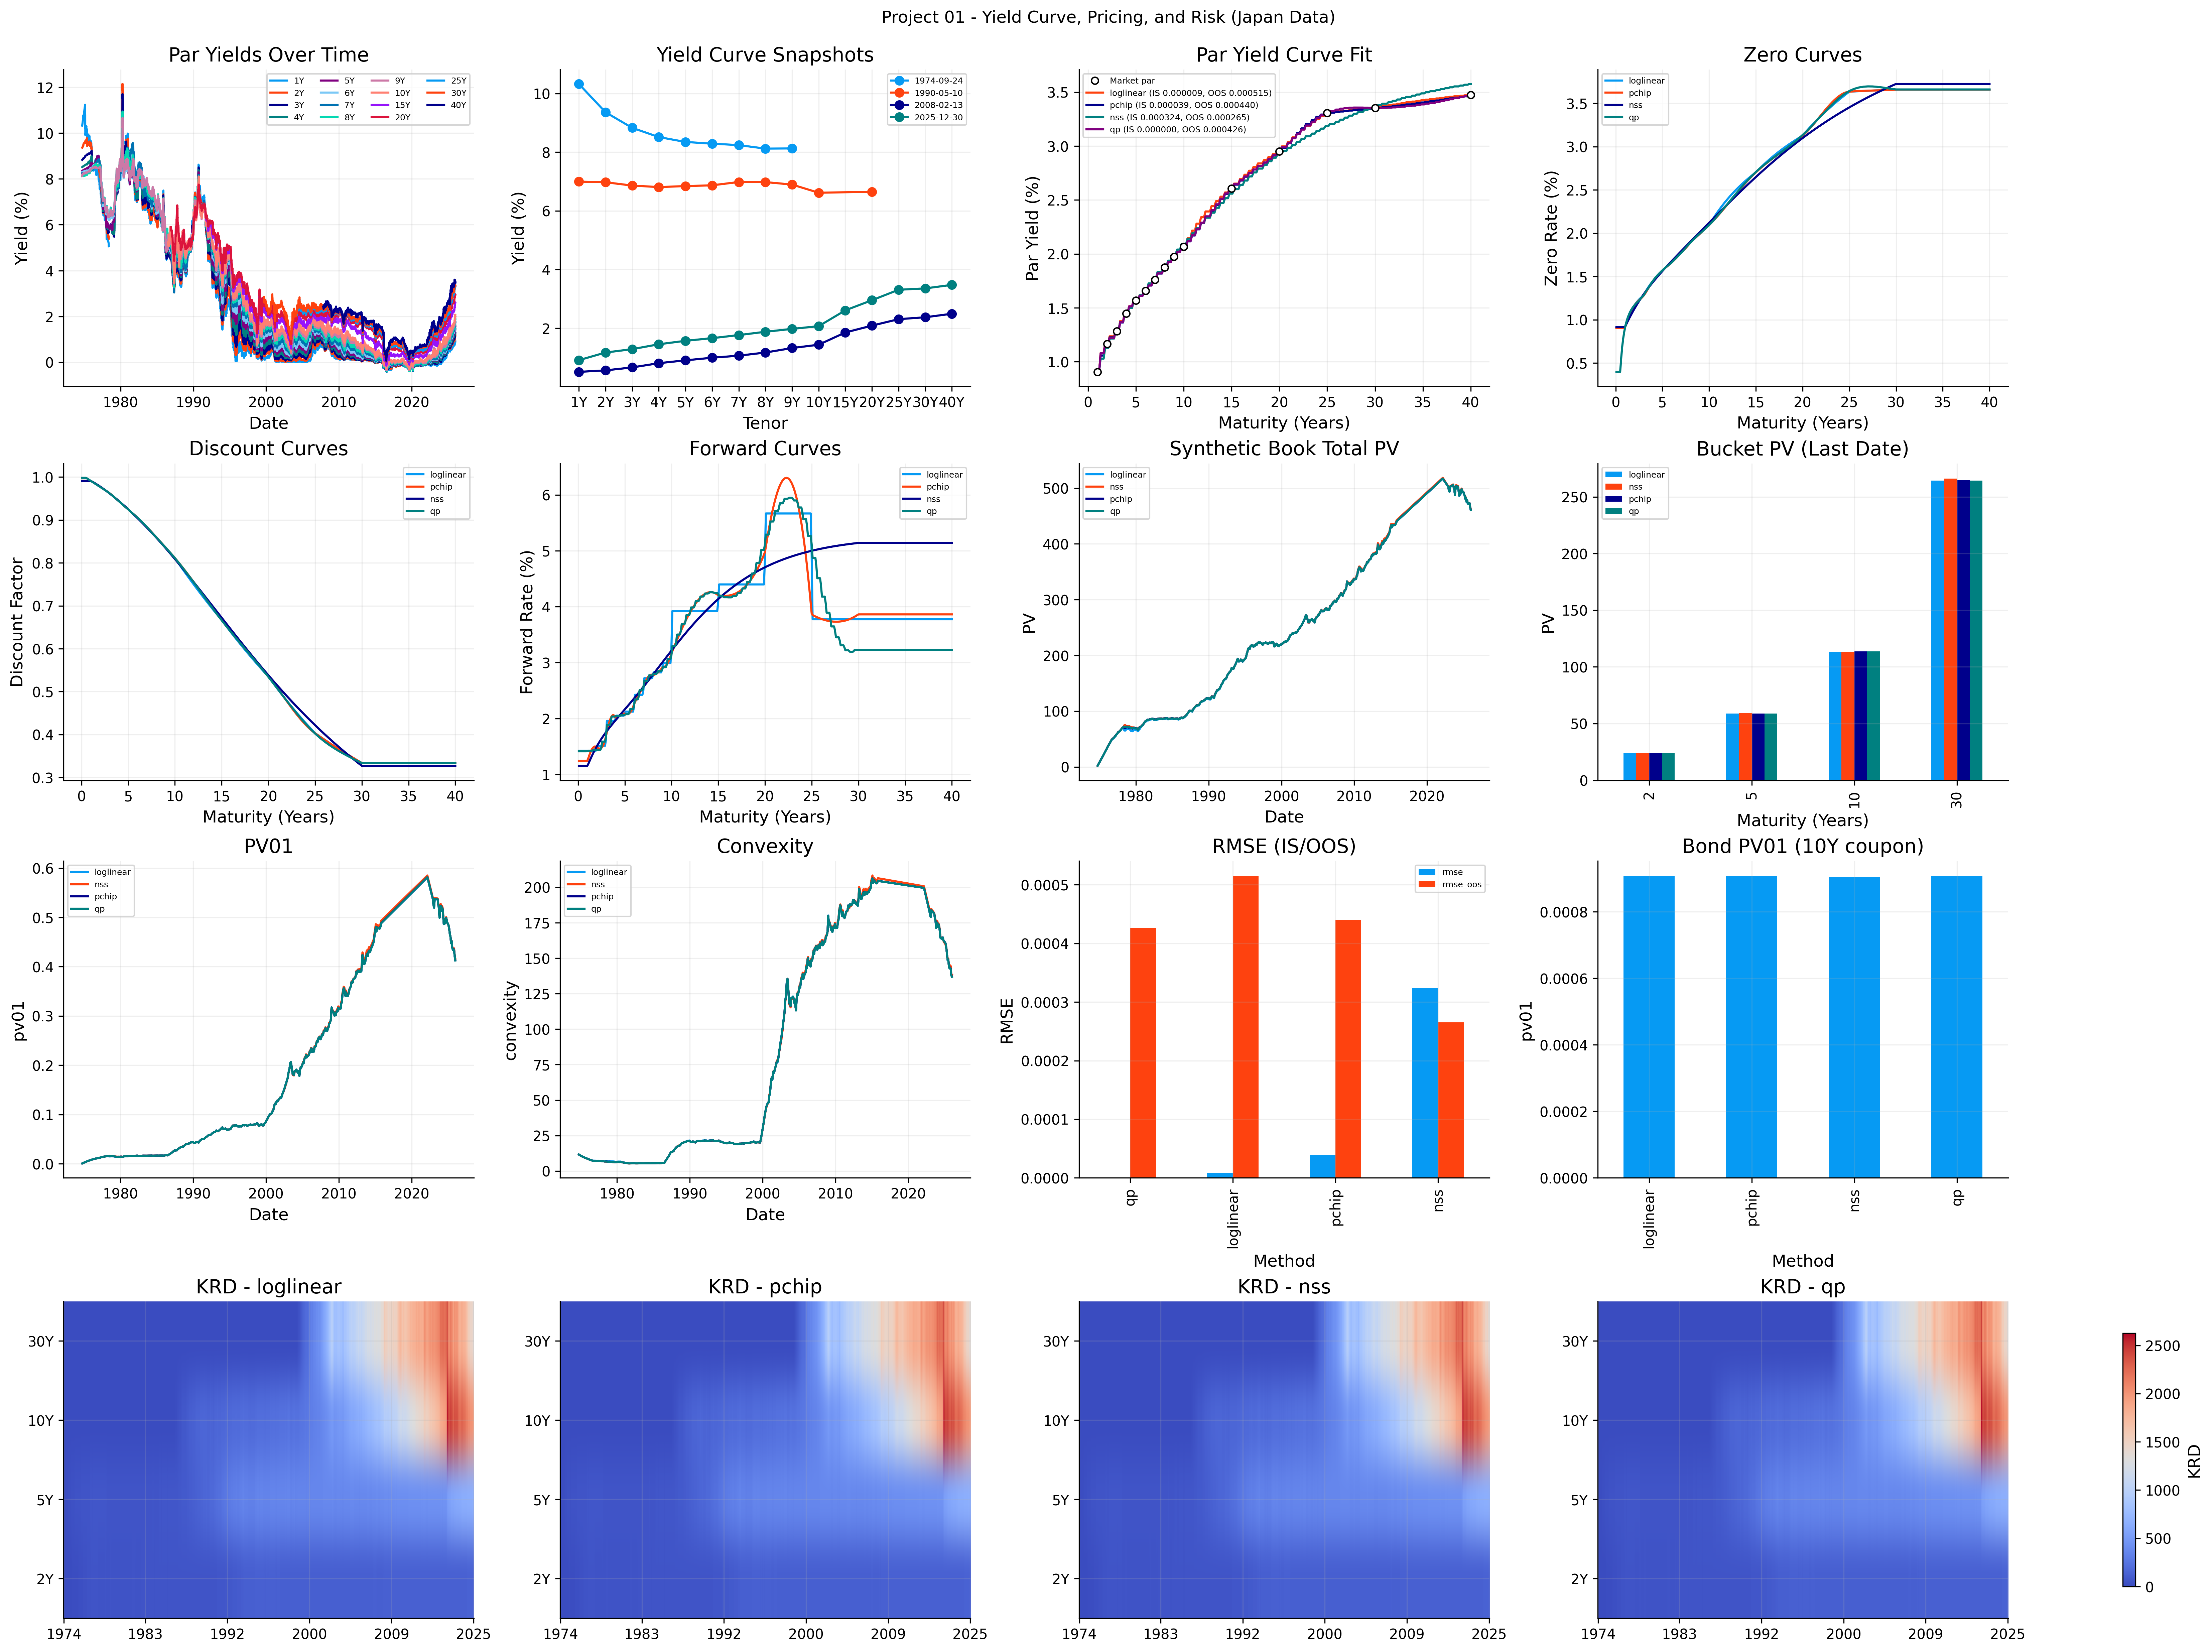

,clean_price,pv01,convexity,krd_2Y,krd_5Y,krd_10Y,krd_30Y
method,,,,,,,
loglinear,1.000000,0.000907,87.530846,0.098387,0.421344,8.514938,0.0
pchip,1.000078,0.000907,87.524809,0.098400,0.421397,8.514987,0.0
nss,0.997714,0.000905,87.497439,0.098420,0.421132,8.491704,0.0
qp,1.000000,0.000907,87.522921,0.098397,0.421366,8.514131,0.0


,rmse,rmse_oos,n_obs,n_obs_oos,n_dates,n_dates_oos,n_failed
method,,,,,,,
qp,2.833055e-09,0.000426,1100,400,100,100,0
loglinear,8.669301e-06,0.000515,1100,400,100,100,0
pchip,3.874855e-05,0.000440,1100,400,100,100,0
nss,3.241647e-04,0.000265,1100,400,100,100,0


In [18]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pathlib import Path
import warnings
import quantfinlab.fixed_income as fi
import quantfinlab.plots as pl


warnings.filterwarnings("ignore")
path = Path("../data/japan_yield_curve_all.csv")

first_line = Path(path).read_text(encoding="utf-8", errors="ignore").splitlines()[0].strip().lower()
if first_line.startswith("interest rate"):
    raw = pd.read_csv(path, skiprows=1, na_values=["-"], keep_default_na=True)
else:
    raw = pd.read_csv(path, na_values=["-"], keep_default_na=True)

raw = raw.rename(columns={c: str(c).strip() for c in raw.columns})

def normalize_tenor_name(c):
    s = str(c).strip().upper().replace(" ", "")
    s = s.replace("MONTHS", "M").replace("MONTH", "M").replace("MOS", "M").replace("MO", "M")
    s = s.replace("YEARS", "Y").replace("YEAR", "Y").replace("YRS", "Y").replace("YR", "Y")
    return s

lower_cols = [c.lower() for c in raw.columns]
date_col = raw.columns[lower_cols.index("date")] if "date" in lower_cols else raw.columns[0]
raw = raw.rename(columns={date_col: "date"})
raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
raw = raw.dropna(subset=["date"]).sort_values("date").set_index("date")

raw = raw.rename(columns={c: normalize_tenor_name(c) for c in raw.columns})
tenor_cols = [c for c in raw.columns if re.fullmatch(r"\d+(M|Y)", str(c))]
tenor_cols = sorted(tenor_cols, key=fi.tenor_to_years)

par = raw[tenor_cols].apply(pd.to_numeric, errors="coerce").dropna(how="all").sort_index()
if np.nanmedian(par.to_numpy(dtype=float)) > 1.0: 
    par = par / 100.0


methods = ["loglinear", "pchip", "nss", "qp"]
holdouts = ["2Y", "7Y", "20Y", "30Y"]
keys = [2, 5, 10, 30]
freq = 2
short_end = "continuous"
asof = fi.resolve_asof(par.index)

pillars = fi.bootstrap_pillars(par.loc[asof], asof=asof, tenor_cols=tenor_cols, freq=freq, short_end=short_end)
curves = fi.fit_curves(pillars, methods=methods, freq=freq)

curve_t_max = max(30.0, float(pillars.T.max()))
plot_grid = np.linspace(max(1 / 12, float(pillars.T.min())), float(pillars.T.max()), 250)
par_fit_table = fi.par_curve_table(curves, grid=plot_grid, freq=freq)
zero_table = fi.zero_curve_table(curves, t_min=1 / 12, t_max=curve_t_max, points=400)
df_table = fi.discount_curve_table(curves, t_min=1 / 12, t_max=curve_t_max, points=400)
fwd_table = fi.forward_curve_table(curves, t_min=1 / 12, t_max=curve_t_max, points=400)

rmse = fi.rmse_backtest(par.tail(100), methods=methods, holdouts=holdouts, freq=freq, short_end=short_end,
    tenor_cols=tenor_cols)

rmse_sorted = fi.sort_rmse_table(rmse, methods=methods)


month_end = par.resample("ME").last().dropna(how="all")
book = fi.synthetic_issuance_book(month_end, maturities=keys, freq=freq)

curves_for_dates = fi.curves_by_valuation_date(month_end.index, par, methods=methods, freq=freq,
    short_end=short_end, tenor_cols=tenor_cols)

pv_total, pv_buckets = fi.book_pv_timeseries(book, curves_for_dates)
risk_df = fi.book_parallel_risk_timeseries(book, curves_for_dates, bump_bp=1.0)
krd_df = fi.book_krd_timeseries(book, curves_for_dates, keys=keys, bump_bp=1.0)
metrics = fi.make_book_metrics(pv_total, pv_buckets, risk_df)


bond, used_tenor = fi.bond_from_par_curve_row(par.loc[asof], maturity_years=10, tenor_cols=tenor_cols, freq=freq)
bond_tbl = fi.bond_price_and_risk(bond,curves, bump_bp=1.0, key_tenors=keys).reindex(methods)

n = len(par.index)
sample_dates = [par.index[0], par.index[n // 3], par.index[(2 * n) // 3], par.index[-1]]


fig = plt.figure(figsize=(22, 16), constrained_layout=True)
gs = fig.add_gridspec(4, 4)

ax_all = fig.add_subplot(gs[0, 0])
pl.plot_par_yields_history(ax_all, par, title="Par Yields Over Time")

ax_snap = fig.add_subplot(gs[0, 1])
pl.plot_yield_curve_snapshots(ax_snap, par, tenor_cols=tenor_cols, sample_dates=sample_dates, title="Yield Curve Snapshots")

ax_par = fig.add_subplot(gs[0, 2])
pl.draw_market_par_points(ax_par, pillars.T, pillars.par)
rmse_label_map = {
    m: f"{m} (IS {rmse.loc[m, 'rmse']:.6f}, OOS {rmse.loc[m, 'rmse_oos']:.6f})" if m in rmse.index else m
    for m in methods
}
pl.draw_curve_lines(ax_par, par_fit_table, scale=100.0, label_map=rmse_label_map)
pl.style_axis(ax_par, title="Par Yield Curve Fit", xlabel="Maturity (Years)", ylabel="Par Yield (%)")

ax_zero = fig.add_subplot(gs[0, 3])
pl.plot_zero_curves(ax_zero, zero_table, title="Zero Curves")

ax_df = fig.add_subplot(gs[1, 0])
pl.plot_discount_curves(ax_df, df_table, title="Discount Curves")

ax_fwd = fig.add_subplot(gs[1, 1])
pl.plot_forward_curves(ax_fwd, fwd_table, title="Forward Curves")

ax_total = fig.add_subplot(gs[1, 2])
pl.plot_total_pv(ax_total, metrics.total_pv, title="Synthetic Book Total PV")

ax_bucket = fig.add_subplot(gs[1, 3])
pl.plot_bucket_pv(ax_bucket, metrics.bucket_pv, title="Bucket PV (Last Date)")

ax_pv01 = fig.add_subplot(gs[2, 0])
pl.plot_risk_metric(ax_pv01, metrics.risk, metric="pv01", title="PV01")

ax_conv = fig.add_subplot(gs[2, 1])
pl.plot_risk_metric(ax_conv, metrics.risk, metric="convexity", title="Convexity")

ax_rmse = fig.add_subplot(gs[2, 2])
pl.plot_rmse_bars(ax_rmse, rmse_sorted, title="RMSE (IS/OOS)")

ax_bond = fig.add_subplot(gs[2, 3])
pl.plot_bond_metric_bar(ax_bond, bond_tbl, metric="pv01", title=f"Bond PV01 ({used_tenor} coupon)")

krd_axes = [fig.add_subplot(gs[3, i]) for i in range(4)]
ims = []
for ax, method in zip(krd_axes, methods, strict=False):
    im = pl.plot_krd_heatmap(ax, krd_df, method=method, keys=keys, title=f"KRD - {method}")
    if im is not None:
        ims.append(im)
if ims:
    fig.colorbar(ims[0], ax=krd_axes, shrink=0.8, location="right", label="KRD")

fig.suptitle("Project 01 - Yield Curve, Pricing, and Risk (Japan Data)", y=1.02)
plt.show()

display(bond_tbl)
display(rmse_sorted)

